In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import shephard
import os
from sklearn.decomposition import PCA
from combat.pycombat import pycombat
import scipy.cluster.hierarchy as shc
import plotly.graph_objects as go
from scipy.stats import ttest_ind, ttest_rel
import seaborn as sns





In [30]:
# Global variables for analysis

# Path of the txt folder
# txt_path = '/Users/plutzer/Library/CloudStorage/Box-Box/CellBio-MajorLab/Users/Isaac/Experiments/009_CDKs_OXPO4/txt/' # laptop path
txt_path = '/Users/plutzer/Box/CellBio-MajorLab/Users/Isaac/Experiments/009_CDKs_OXPO4/txt/' # desktop path

# Path where outputs will go
# output_folder_path = '/Users/plutzer/Library/CloudStorage/Box-Box/CellBio-MajorLab/Users/Isaac/Experiments/009_CDKs_OXPO4/analysis_output/' # laptop path
output_folder_path = '/Users/plutzer/Box/CellBio-MajorLab/Users/Isaac/Experiments/009_CDKs_OXPO4/analysis_output/' # desktop path

# Proximity data file name
proximity_file_name = '/Users/plutzer/Box/CellBio-MajorLab/Users/Isaac/Experiments/Projects/IDG_pipeline/137_DKs/Annotated_Merged_Output.csv' # desktop path

# Other globals for analysis
# Experiment name to columns mapping
columns_mapping = {
    'Reporter intensity corrected 1 CDKs':'Ctrl 1',
    'Reporter intensity corrected 2 CDKs':'CDK2 1',
    'Reporter intensity corrected 3 CDKs':'Ctrl 2',
    'Reporter intensity corrected 4 CDKs':'CDK2 2',
    'Reporter intensity corrected 5 CDKs':'Ctrl 3',
    'Reporter intensity corrected 6 CDKs':'CDK2 3',
    'Reporter intensity corrected 7 CDKs':'CDK14 1',
    'Reporter intensity corrected 8 CDKs':'CDK16 1',
    'Reporter intensity corrected 9 CDKs':'CDK14 2',
    'Reporter intensity corrected 10 CDKs':'CDK16 2',
    'Reporter intensity corrected 11 CDKs':'CDK14 3',
    'Reporter intensity corrected 12 CDKs':'CDK16 3',
    'Reporter intensity corrected 13 CDKs':'CDK17 1',
    'Reporter intensity corrected 14 CDKs':'CDK18 1',
    'Reporter intensity corrected 15 CDKs':'CDK17 2',
    'Reporter intensity corrected 16 CDKs':'CDK18 2',
    'Reporter intensity corrected 17 CDKs':'CDK17 3',
    'Reporter intensity corrected 18 CDKs':'CDK18 3'
}

# Columns order for data tables
quant_cols_order = [
    'Ctrl 1',
    'Ctrl 2',
    'Ctrl 3',
    'CDK2 1',
    'CDK2 2',
    'CDK2 3',
    'CDK14 1',
    'CDK14 2',
    'CDK14 3',
    'CDK16 1',
    'CDK16 2',
    'CDK16 3',
    'CDK17 1',
    'CDK17 2',
    'CDK17 3',
    'CDK18 1',
    'CDK18 2',
    'CDK18 3'
]

In [6]:
# If the output directory doesn't exist, create it
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

In [7]:
# Functions

# Code for mixing correction:
def correct_mixing(dataset,columns):
    data = dataset[columns]
    sums = np.sum(data)
    corrected = data/(sums/np.mean(sums))
    return corrected



In [8]:
# Read in the phospho_data

phospho_path = txt_path + 'Phospho (STY)Sites.txt'

phospho_raw = pd.read_csv(phospho_path, sep='\t')

# Create an index for the phospho data based on the gene name and site
def make_phospho_index(row):
    return str(row['Gene names']).split(';')[0] + '_' + row['Amino acid'] + str(row['Positions within proteins']).split(';')[0]

phospho_raw['index'] = phospho_raw.apply(make_phospho_index, axis=1)
phospho_raw.set_index('index', inplace=True)


C:\Users\plutzer\AppData\Local\Temp\ipykernel_20708\2638401400.py:5: DtypeWarning: Columns (17,205,206) have mixed types. Specify dtype option on import or set low_memory=False.
  phospho_raw = pd.read_csv(phospho_path, sep='\t')


In [9]:
# Filter the phospho data
phospho =  phospho_raw[phospho_raw['Localization prob'] >= 0.75]
phospho = phospho[phospho['Reverse'] != '+']
phospho = phospho[phospho['Potential contaminant'] != '+']

# print the number of class 1 phosphosites (the length of the dataframe)
print('Number of class 1 phosphosites: ' + str(len(phospho)))

Number of class 1 phosphosites: 9095


In [10]:
# Preprocess the phospho data

data = phospho.copy()

cols_list = []
non_quant_cols = []
for col in data.columns:
    if 'Reporter intensity corrected' in col:
        cols_list.append(col)
    elif 'Reporter intensity' in col:
        skip = True
    else:
        non_quant_cols.append(col)

quant_subset = data[cols_list]

non_quant_subset = data[non_quant_cols]

column_names = [col.split('__')[0] for col in quant_subset.columns if '__' in col]

quant_summarized = pd.DataFrame()

for column_name in set(column_names):
    # Filter columns with the current column name
    related_columns = [col for col in quant_subset.columns if col.startswith(column_name)]

    # Sum the related columns and store the result in the summarized DataFrame
    quant_summarized[column_name] = quant_subset[related_columns].sum(axis=1)
    
quant_summarized_mixCorrected = correct_mixing(quant_summarized,quant_summarized.columns)

quant_summarized_mixCorrected.rename(columns=columns_mapping, inplace=True)

quant_summarized_mixCorrected_ordered = quant_summarized_mixCorrected[quant_cols_order]


# combine the non_quant and quant_summarized_mixCorrected dataframes
combined = pd.concat([non_quant_subset,quant_summarized_mixCorrected_ordered],axis=1)

# Re-make the index for the combined dataframe
combined['index'] = combined.apply(make_phospho_index, axis=1)
combined.set_index('index', inplace=True)

# Change any zeros in the quant data to NaN
combined[quant_cols_order] = combined[quant_cols_order].replace(0,np.nan)

# Drop columns that have missing values in the quant data
combined.dropna(subset=quant_cols_order,inplace=True)
print('Number of phosphosites after filtering out missing values: ' + str(len(combined)))
# Write the combined dataframe to a csv file
combined.to_csv(output_folder_path + 'mix_corrected.csv')

Number of phosphosites after filtering out missing values: 8804


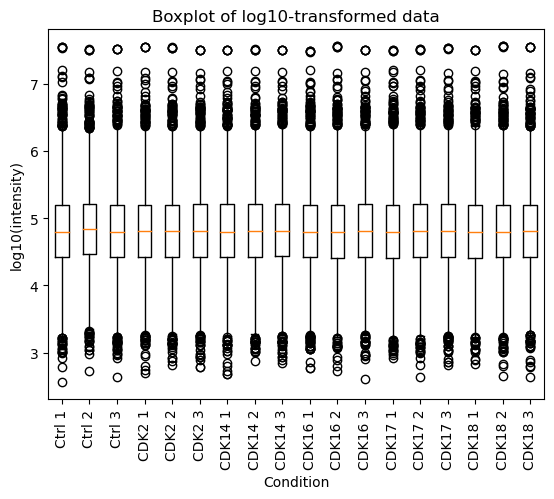

In [11]:
# Now need to do a log-transformation of the data
combined_log = combined.copy()
combined_log[quant_cols_order] = np.log10(combined_log[quant_cols_order] + 1)

# Write the combined_log dataframe to a csv file
combined_log.to_csv(output_folder_path + 'log10_mix_corrected.csv')

plt.boxplot(combined_log[quant_cols_order])
# Use the quant cols order to get the correct names of the labels
plt.xticks(range(1,len(quant_cols_order)+1),quant_cols_order,rotation=90)
plt.ylabel('log10(intensity)')
plt.xlabel('Condition')
plt.title('Boxplot of log10-transformed data')
plt.savefig(output_folder_path + 'log10_boxplot.png',dpi=300)

Found 3 batches.
Adjusting for 0 covariate(s) or covariate level(s).
Standardizing Data across genes.
Fitting L/S model and finding priors.
Finding parametric adjustments.
Adjusting the Data


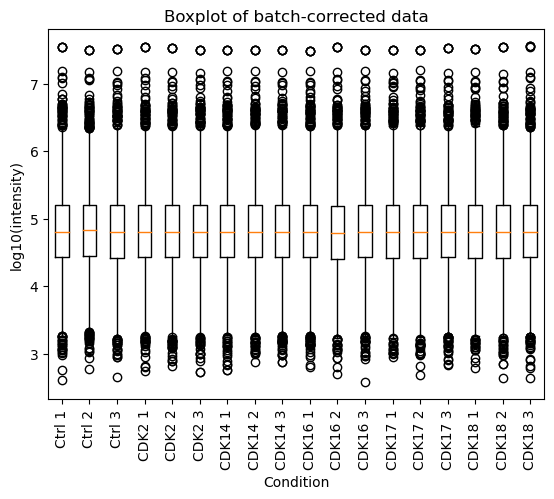

In [12]:
# Now do a batch correction of the data using pycombat

# Make a copy of the combined_zscore dataframe
combined_batch_corrected = combined_log.copy()

combat_data = pycombat(combined_batch_corrected[quant_cols_order],[item.split(' ')[1] for item in quant_cols_order])

# Make a dataframe from the combat_data similar to combined_zscore but with the batch-corrected data instead.
combined_batch_corrected[quant_cols_order] = combat_data

# Write the combined_batch_corrected dataframe to a csv file
combined_batch_corrected.to_csv(output_folder_path + 'log10_mix_batch_corrected.csv')  

plt.boxplot(combined_batch_corrected[quant_cols_order])
# Use the quant cols order to get the correct names of the labels
plt.xticks(range(1,len(quant_cols_order)+1),quant_cols_order,rotation=90)
plt.ylabel('log10(intensity)')
plt.xlabel('Condition')
plt.title('Boxplot of batch-corrected data')
plt.savefig(output_folder_path + 'batch_corrected_boxplot.png',dpi=300)


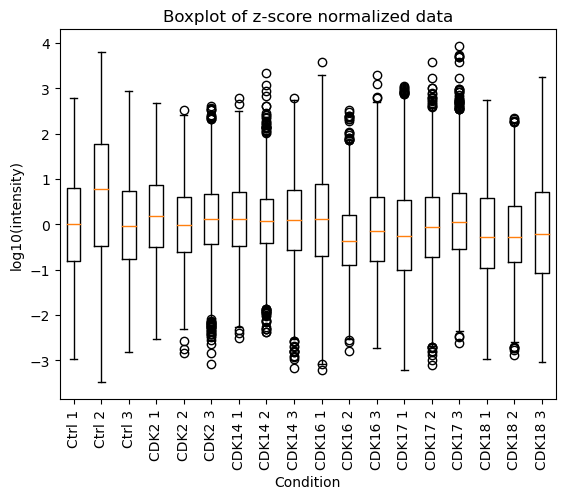

In [13]:
# Now lets z-score normalize the data
combined_zscore = combined_batch_corrected.copy()

# Take the z-score row-wise
combined_zscore[quant_cols_order] = combined_zscore[quant_cols_order].apply(lambda x: (x - np.mean(x)) / np.std(x), axis=1)

# Write the combined dataframe to a csv file
combined_zscore.to_csv(output_folder_path + 'log10_mix_batch_corrected_zscore.csv')

plt.boxplot(combined_zscore[quant_cols_order])
# Use the quant cols order to get the correct names of the labels
plt.xticks(range(1,len(quant_cols_order)+1),quant_cols_order,rotation=90)
plt.ylabel('log10(intensity)')
plt.xlabel('Condition')
plt.title('Boxplot of z-score normalized data')
plt.savefig(output_folder_path + 'zscore_boxplot.png',dpi=300)


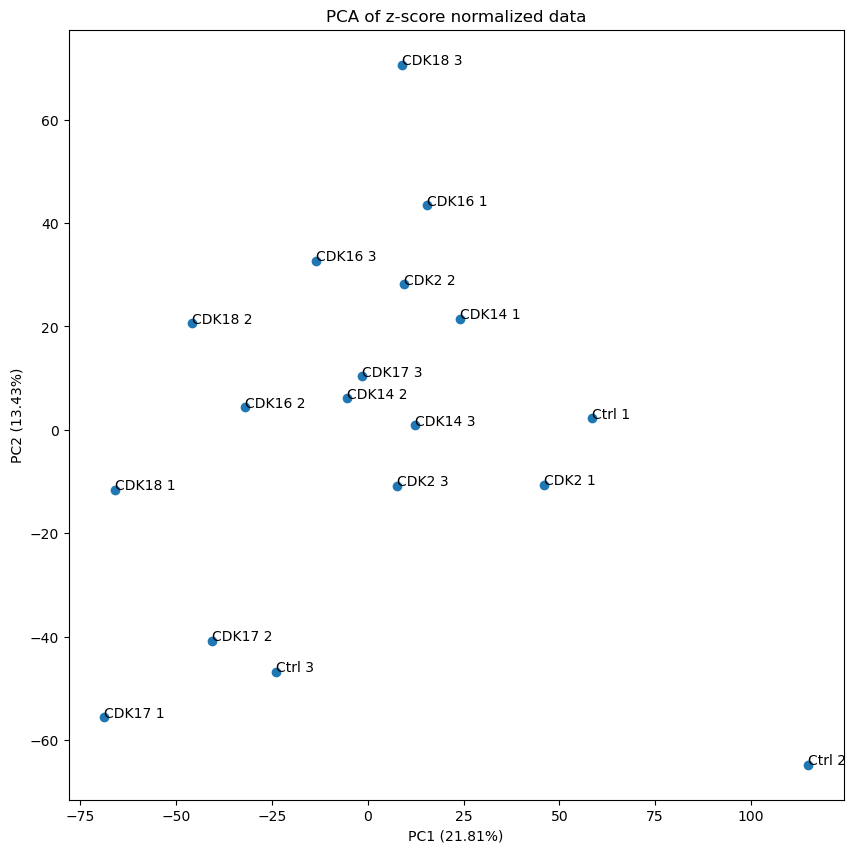

In [17]:
# Make a PCA plot of the z-score normalized data

# Filter the data to only include the quant columns
zscore_quant = combined_zscore[quant_cols_order].dropna()

# Each column should be a point on the PCA plot

# Make a PCA object
pca = PCA(n_components=2)

# Fit the PCA object to the data
pca.fit(zscore_quant.transpose())

# Transform the data
pca_data = pca.transform(zscore_quant.transpose())

# Make a dataframe from the pca_data
pca_df = pd.DataFrame(pca_data, index=quant_cols_order, columns=['PC1','PC2'])

# Plot the PCA data
fig, ax = plt.subplots(figsize=(10,10))
ax.scatter(pca_df['PC1'], pca_df['PC2'])

# Add annotations of the points
for i, txt in enumerate(pca_df.index):
    ax.annotate(txt, (pca_df['PC1'][i], pca_df['PC2'][i]))

# In the axes labels include the percent of variance explained by each PC
ax.set_xlabel('PC1 (' + str(round(pca.explained_variance_ratio_[0]*100,2)) + '%)')
ax.set_ylabel('PC2 (' + str(round(pca.explained_variance_ratio_[1]*100,2)) + '%)')
ax.set_title('PCA of z-score normalized data')
fig.savefig(output_folder_path + 'PCA.png')



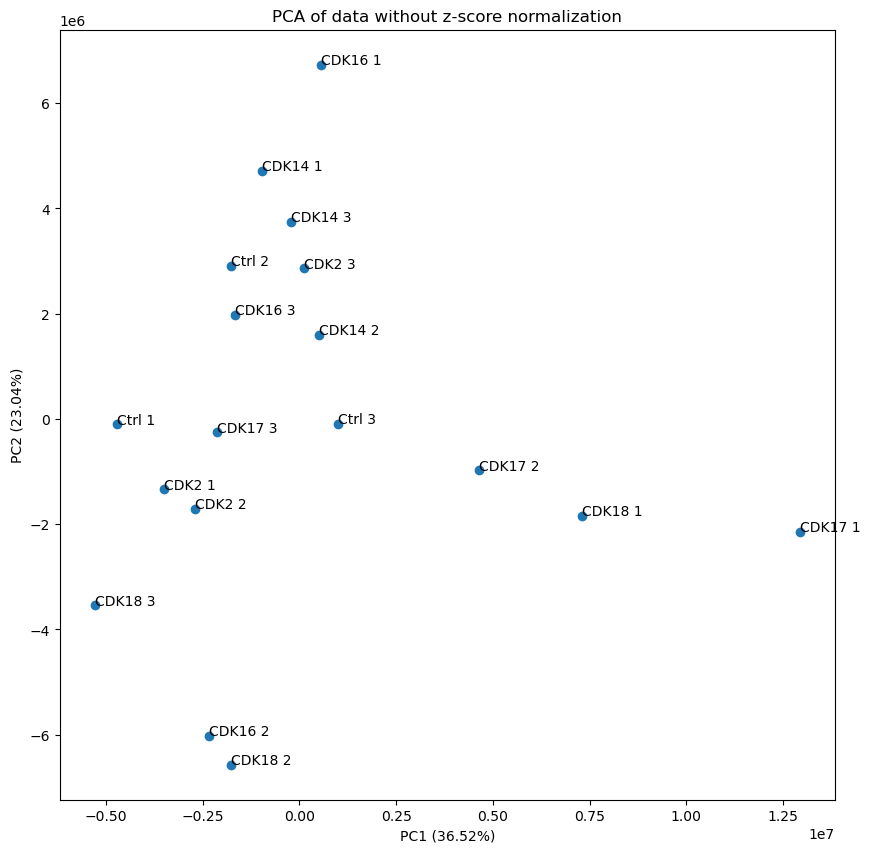

In [18]:
# Filter the data to only include the quant columns
quant_data = combined[quant_cols_order].dropna()

# Create a PCA object
pca = PCA(n_components=2)

# Fit the PCA object to the data
pca.fit(quant_data.transpose())

# Transform the data
pca_data = pca.transform(quant_data.transpose())

# Make a dataframe from the pca_data
pca_df = pd.DataFrame(pca_data, index=quant_cols_order, columns=['PC1', 'PC2'])

# Plot the PCA data
fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(pca_df['PC1'], pca_df['PC2'])

# Add annotations of the points
for i, txt in enumerate(pca_df.index):
    ax.annotate(txt, (pca_df['PC1'][i], pca_df['PC2'][i]))

# In the axes labels include the percent of variance explained by each PC
ax.set_xlabel('PC1 (' + str(round(pca.explained_variance_ratio_[0] * 100, 2)) + '%)')
ax.set_ylabel('PC2 (' + str(round(pca.explained_variance_ratio_[1] * 100, 2)) + '%)')
ax.set_title('PCA of data without z-score normalization')
plt.savefig(output_folder_path + 'PCA_no_zscore.png')


In [19]:
# Make a correlation matrix between all of the observations
corr = zscore_quant.transpose().corr()
link = shc.linkage(corr, method='average', metric='euclidean')

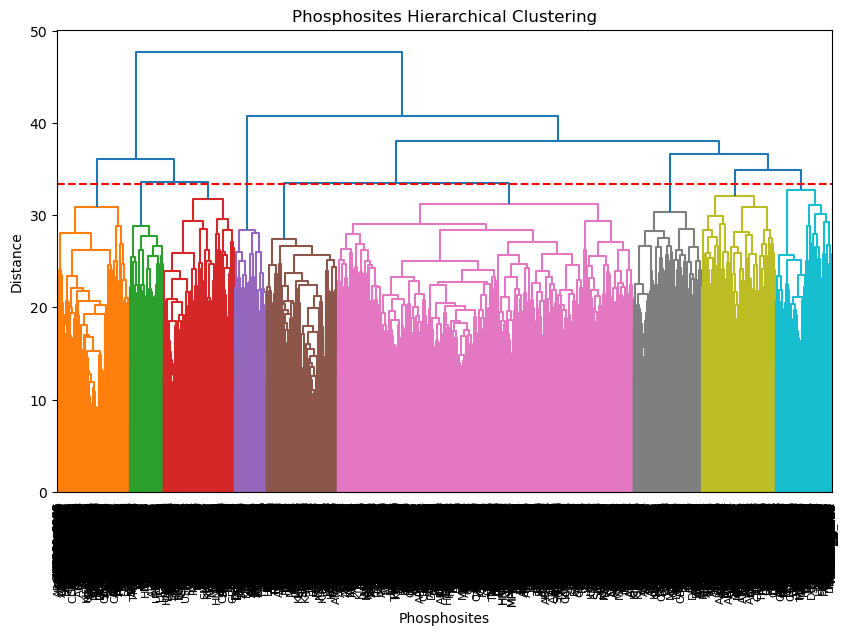

In [20]:
# Create a dendrogram
plt.figure(figsize=(10, 6))
shc.dendrogram(link, labels=corr.index, leaf_rotation=90, leaf_font_size=8)
plt.title('Phosphosites Hierarchical Clustering')
plt.xlabel('Phosphosites')
plt.ylabel('Distance')

# Add a horizontal line at y=35
plt.axhline(y=0.7*max(link[:,2]), color='r', linestyle='--')

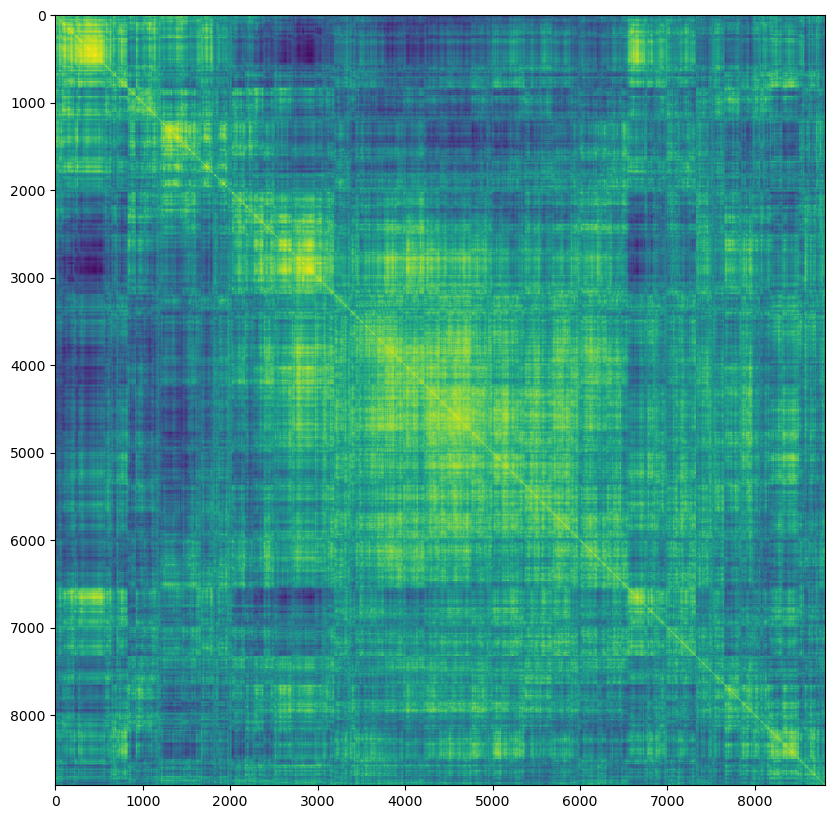

In [21]:
threshold_height = 0.7*max(link[:,2])
corr_clusters = shc.fcluster(link, threshold_height, criterion='distance')

# Get the ordering of the dendrogram leaves
sorted_indices = shc.dendrogram(link, no_plot=True)['leaves']

# Sort the correlation matrix by the dendrogram ordering. Corr is a pandas dataframe so we can use the .values attribute to get the underlying numpy array
sorted_correlation_matrix = corr.iloc[sorted_indices, sorted_indices]

# Visualize the sorted correlation matrix
plt.figure(figsize=(10, 10))
plt.imshow(sorted_correlation_matrix.values, cmap='viridis')



In [22]:
# Compute log2 fold changes from the batch corrected data.

# Make a copy of the combined_batch_corrected dataframe
combined_batch_corrected_log2 = combined_batch_corrected.copy()

# First I need to convert the log10 intensities back to linear intensities
combined_batch_corrected_log2[quant_cols_order] = 10**combined_batch_corrected_log2[quant_cols_order] - 1 # -1 is to undo the +1 in the log10 transformation

# Now convert these to log2 intensities
combined_batch_corrected_log2[quant_cols_order] = np.log2(combined_batch_corrected_log2[quant_cols_order] + 1)

# Need to make this general using a dict of comparisons

comparisons = {
    'CDK2':[['Ctrl 1','Ctrl 2','Ctrl 3'],['CDK2 1','CDK2 2','CDK2 3']],
    'CDK14':[['Ctrl 1','Ctrl 2','Ctrl 3'],['CDK14 1','CDK14 2','CDK14 3']],
    'CDK16':[['Ctrl 1','Ctrl 2','Ctrl 3'],['CDK16 1','CDK16 2','CDK16 3']],
    'CDK17':[['Ctrl 1','Ctrl 2','Ctrl 3'],['CDK17 1','CDK17 2','CDK17 3']],
    'CDK18':[['Ctrl 1','Ctrl 2','Ctrl 3'],['CDK18 1','CDK18 2','CDK18 3']]
}

# Compute the log2 fold changes for each comparison
for key in comparisons.keys():
    if len(comparisons[key][0]) == len(comparisons[key][1]):
        print(key + ': Same length. Using mean log2 fold change of samples.')
        fc_list = []
        ctrl_vals = []
        test_vals = []
        for i in range(len(comparisons[key][0])):
            ctrl_vals.append(combined_batch_corrected_log2[comparisons[key][0][i]])
            test_vals.append(combined_batch_corrected_log2[comparisons[key][1][i]])
            fc_list.append(combined_batch_corrected_log2[comparisons[key][1][i]] - combined_batch_corrected_log2[comparisons[key][0][i]])
        combined_batch_corrected_log2['log2FC_' + key] = np.mean(fc_list,axis=0)
        # Perform the t-test
        ttest = ttest_rel(ctrl_vals,test_vals,axis=0)
        combined_batch_corrected_log2['pval_' + key] = ttest.pvalue
    else:
        print(key + ': Different length. Using log2 fold change of means.')
        # Use the log2 fold change of the means
        combined_batch_corrected_log2['log2FC_' + key] = np.mean(combined_batch_corrected_log2[comparisons[key][1]],axis=1) - np.mean(combined_batch_corrected_log2[comparisons[key][0]],axis=1)
        
        # Perform the t-test
        ttest = ttest_ind(combined_batch_corrected_log2[comparisons[key][1]],combined_batch_corrected_log2[comparisons[key][0]],axis=1)
        combined_batch_corrected_log2['pval_' + key] = ttest.pvalue

# Now compute the p-values for each comparison
# Use a t-test for each comparison

# Save the combined_batch_corrected_log2 dataframe to a csv file
combined_batch_corrected_log2.to_csv(output_folder_path + 'log2_mix_batch_corrected_tests.csv')

CDK2: Same length. Using mean log2 fold change of samples.
CDK14: Same length. Using mean log2 fold change of samples.
CDK16: Same length. Using mean log2 fold change of samples.
CDK17: Same length. Using mean log2 fold change of samples.
CDK18: Same length. Using mean log2 fold change of samples.


In [23]:
# Now add the p-values and log2 fold changes to the zscore dataframe
combined_zscore_with_fc = combined_zscore.copy()

for key in comparisons.keys():
    combined_zscore_with_fc['log2FC_' + key] = combined_batch_corrected_log2['log2FC_' + key]
    combined_zscore_with_fc['pval_' + key] = combined_batch_corrected_log2['pval_' + key]

# Now add the cluster labels to the dataframe
combined_zscore_with_fc['cluster'] = corr_clusters

# Save the combined_zscore_with_fc dataframe to a csv file
combined_zscore_with_fc.to_csv(output_folder_path + 'combined.csv')

In [24]:
# Create outputs that can be used for enrichment analysis by the kinase library

for key in comparisons.keys():
    df = combined_zscore_with_fc[['Sequence window','log2FC_' + key,'pval_' + key]]    
    # Change the sequence window column to only include the first element ';' of the delimited string
    df['Sequence window'] = df['Sequence window'].apply(lambda x: x.split(';')[0])
    df.to_csv(output_folder_path + key + '_enrichment_input.txt', sep = '\t', index=False)

C:\Users\plutzer\AppData\Local\Temp\ipykernel_20708\4007555337.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sequence window'] = df['Sequence window'].apply(lambda x: x.split(';')[0])
C:\Users\plutzer\AppData\Local\Temp\ipykernel_20708\4007555337.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sequence window'] = df['Sequence window'].apply(lambda x: x.split(';')[0])
C:\Users\plutzer\AppData\Local\Temp\ipykernel_20708\4007555337.py:6: SettingWithCopyWarning: 
A value is trying to be set on

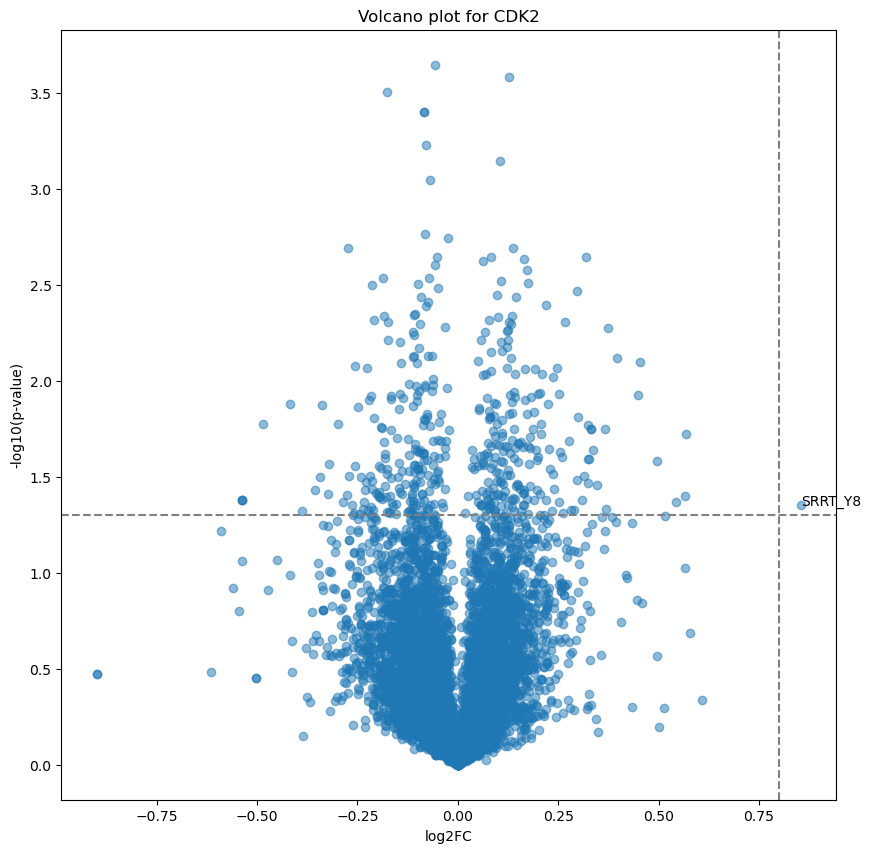

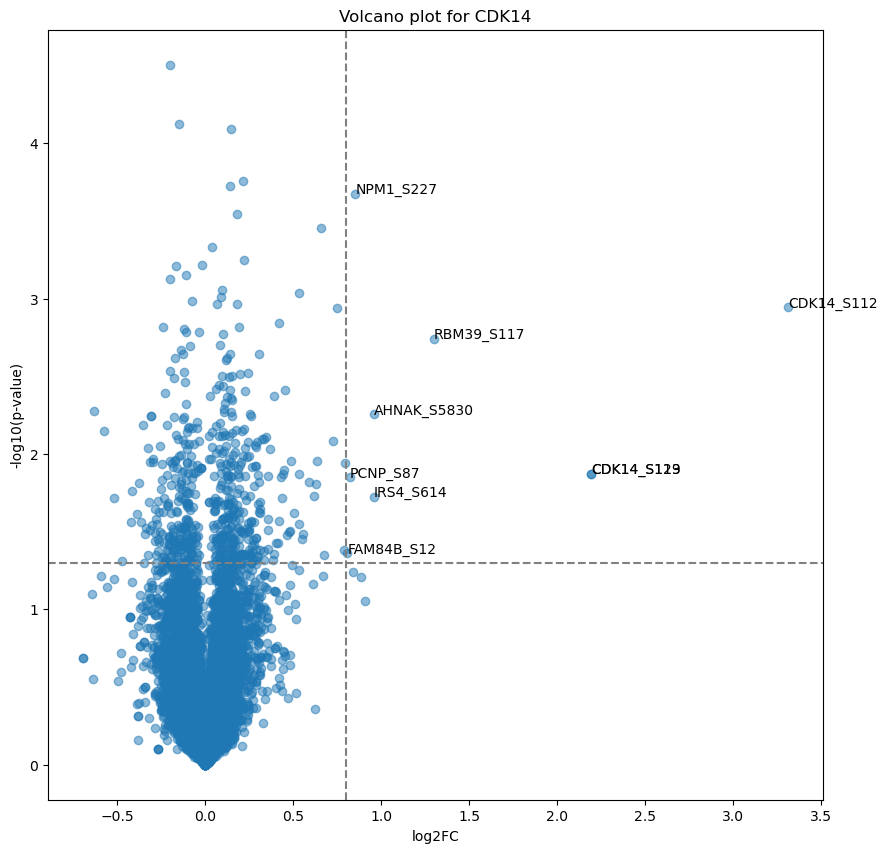

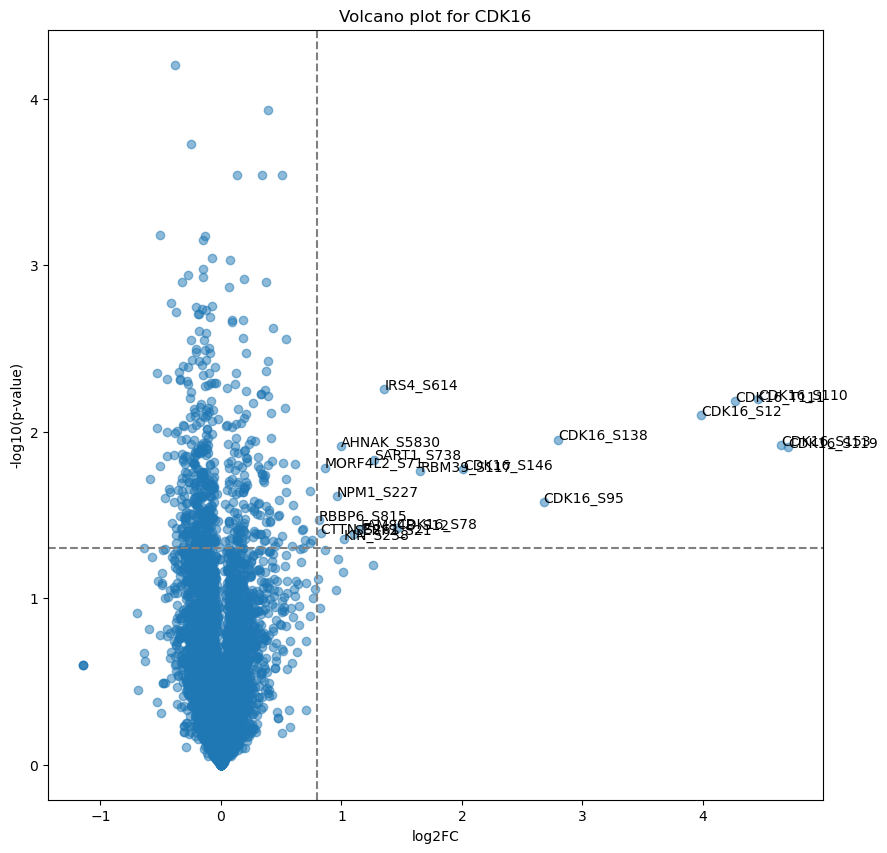

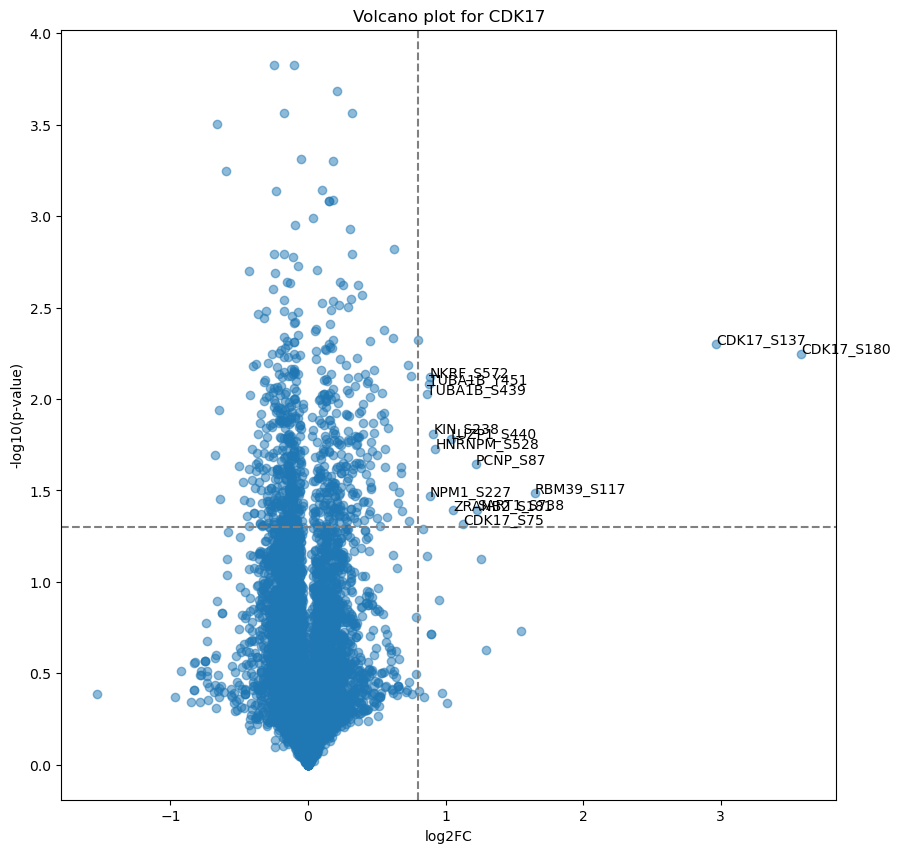

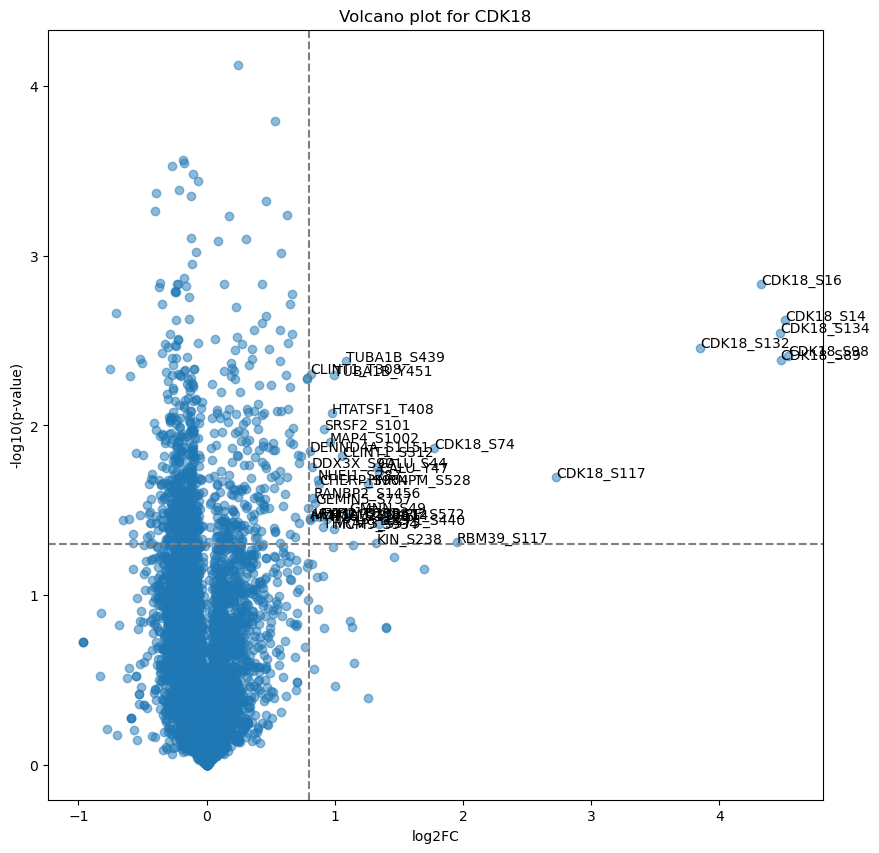

In [164]:
# Create volcano plots for each comparison

for key in comparisons.keys():
    # Make a volcano plot
    fig, ax = plt.subplots(figsize=(10,10))
    # Use default colors for the clusters
    # Color the points on the volcano plot by cluster - use  the colors list
    # Don't do it with the for loop because it affects the order of the points
    scatter = ax.scatter(combined_zscore_with_fc['log2FC_' + key], -np.log10(combined_zscore_with_fc['pval_' + key]), alpha=0.5)

    
    # Add a line for a significance threshold
    ax.axhline(y=-np.log10(0.05), color='grey', linestyle='--')

    # Add a vertical line for the log2FC threshold of 1
    ax.axvline(x=0.8, color='grey', linestyle='--')

    # legend1 = ax.legend(*scatter.legend_elements(),
    #                 loc="upper left", title="Cluster")
    # ax.add_artist(legend1)

    # Add text annotations for all points that are significant and have a log2FC greater than 1
    for i, txt in enumerate(combined_zscore_with_fc.index):
        if combined_zscore_with_fc['pval_' + key][i] < 0.05 and combined_zscore_with_fc['log2FC_' + key][i] > 0.8:
            ax.annotate(txt, (combined_zscore_with_fc['log2FC_' + key][i], -np.log10(combined_zscore_with_fc['pval_' + key][i])))

    ax.set_xlabel('log2FC')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title('Volcano plot for ' + key)
    fig.savefig(output_folder_path + key + '_volcano.png')

C:\Users\plutzer\AppData\Local\Temp\ipykernel_20708\386618812.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(10,10))


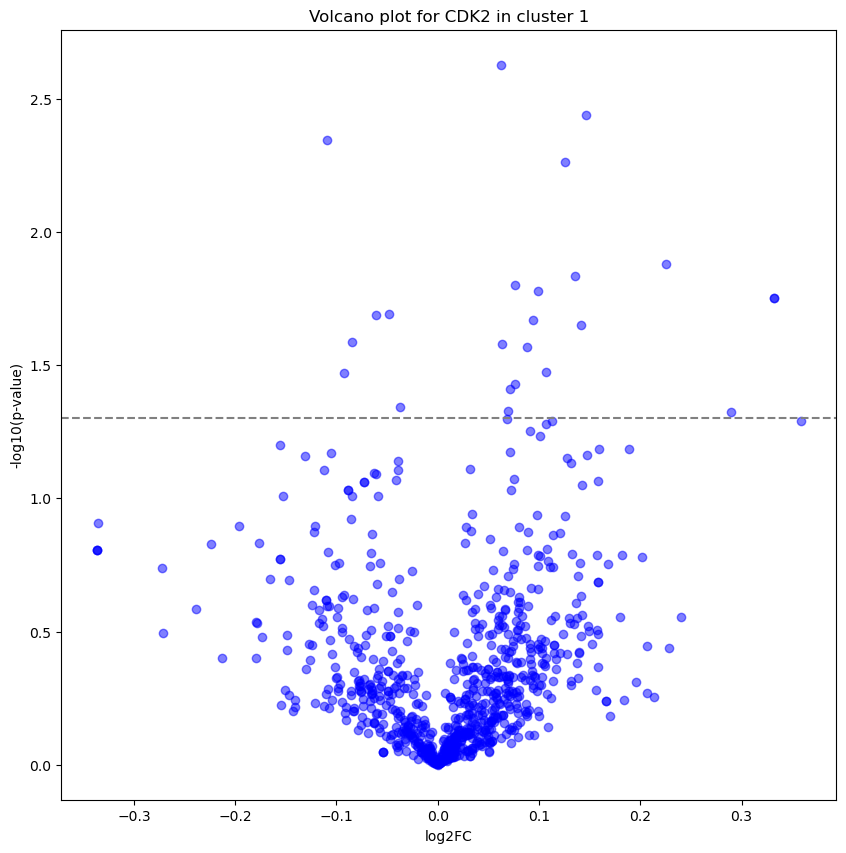

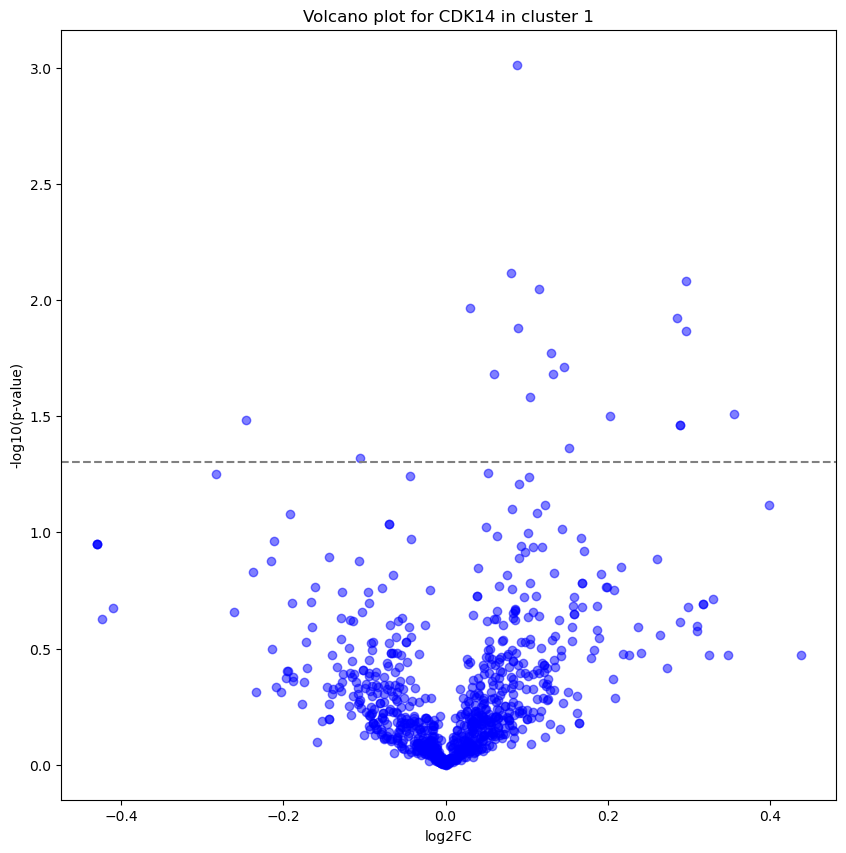

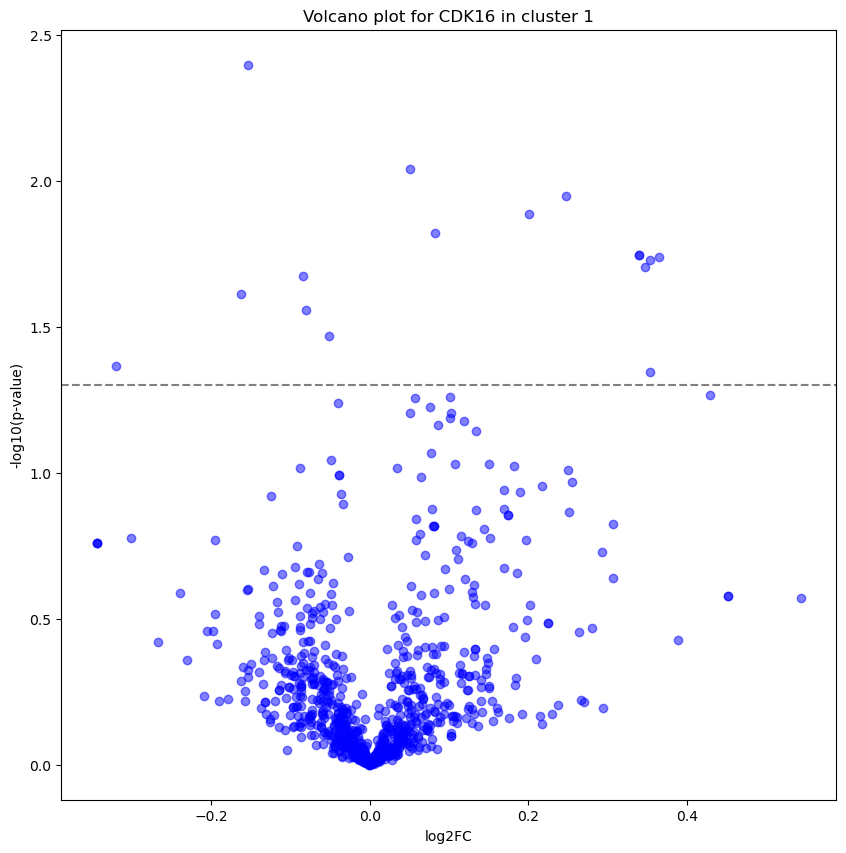

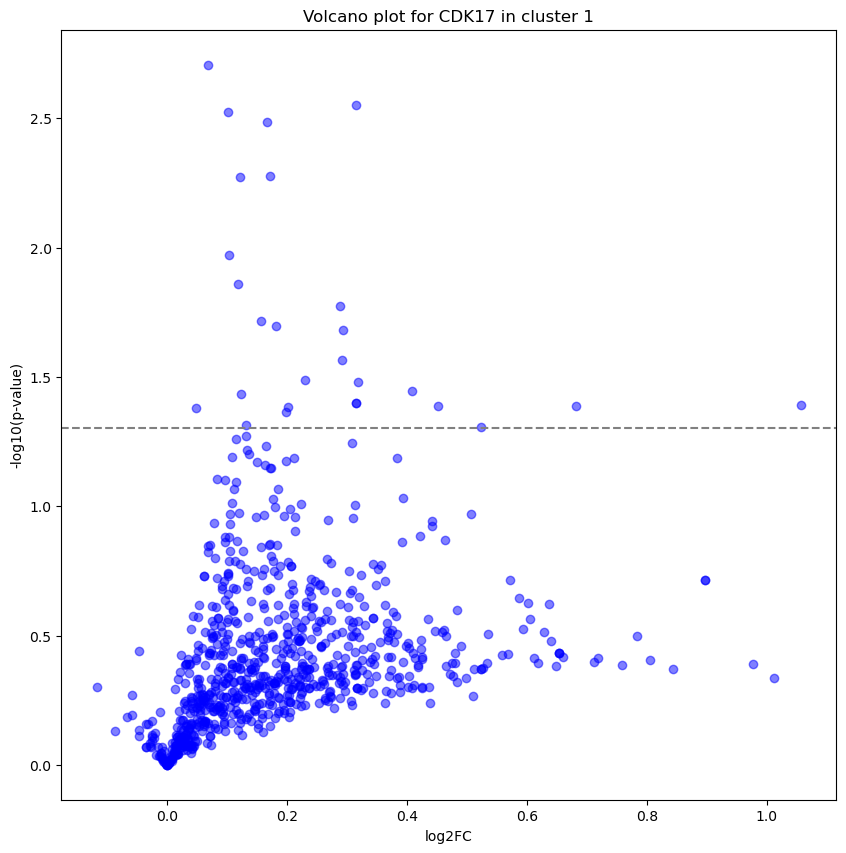

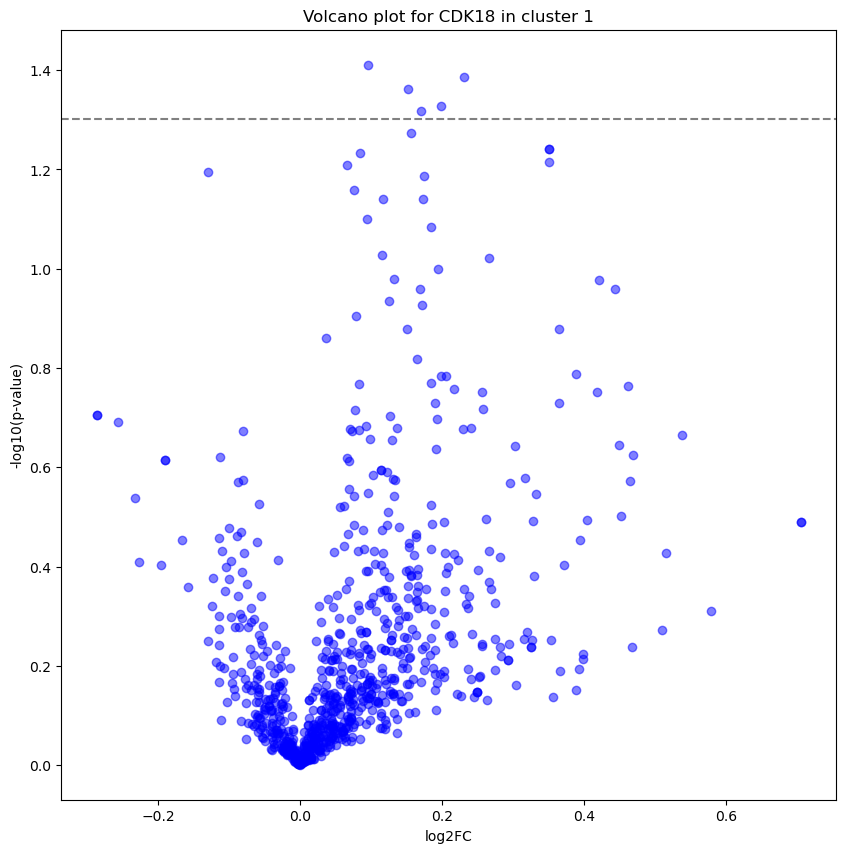

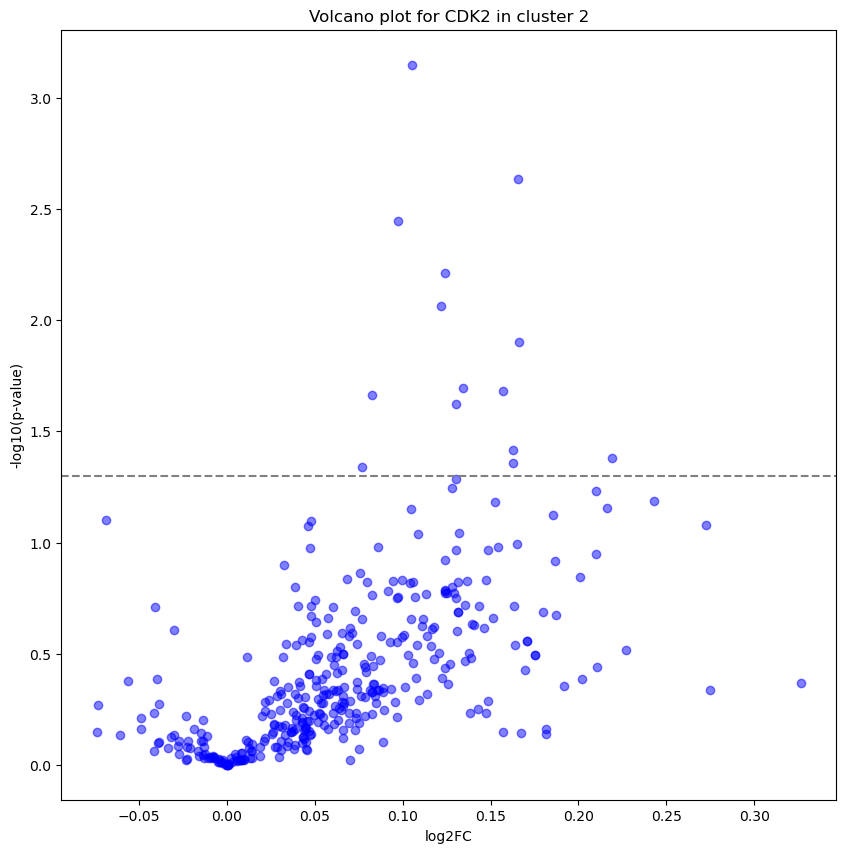

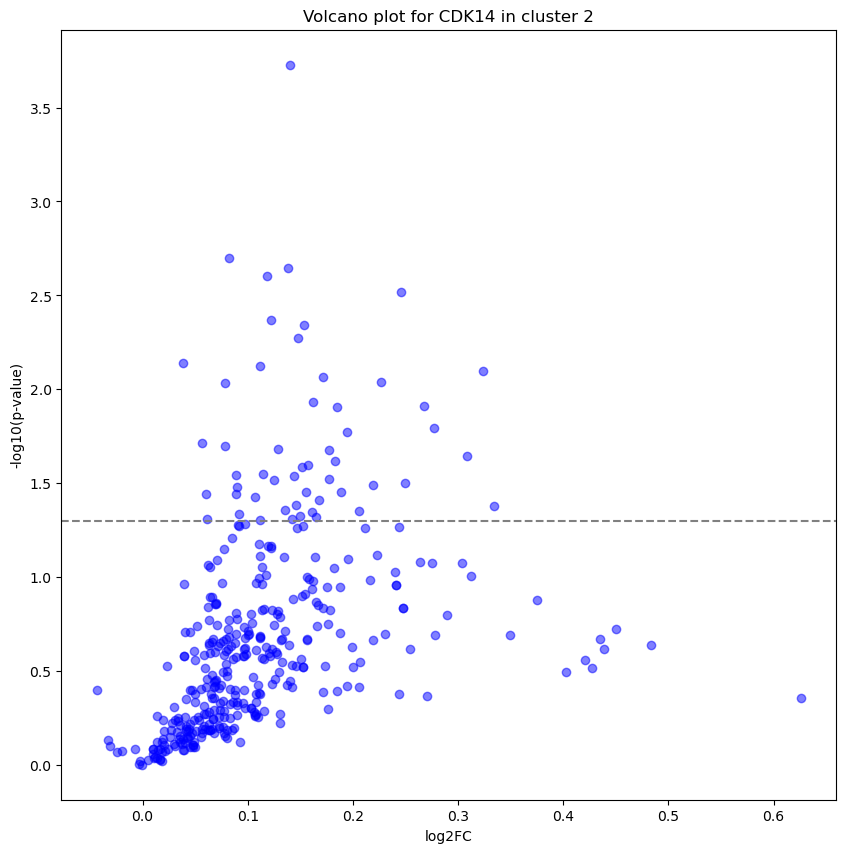

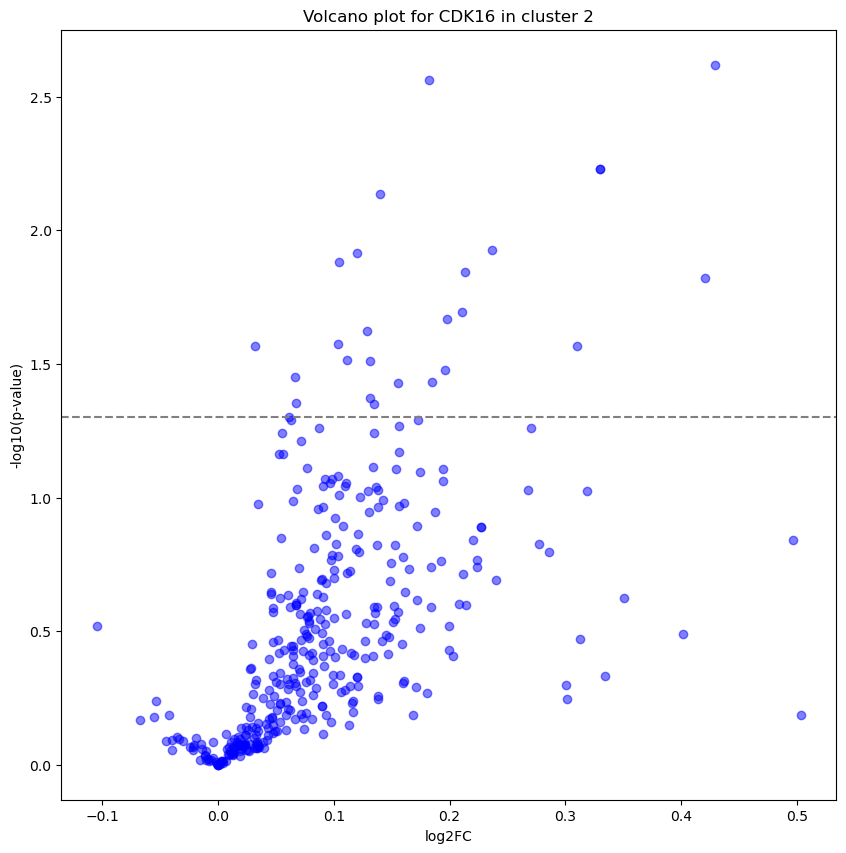

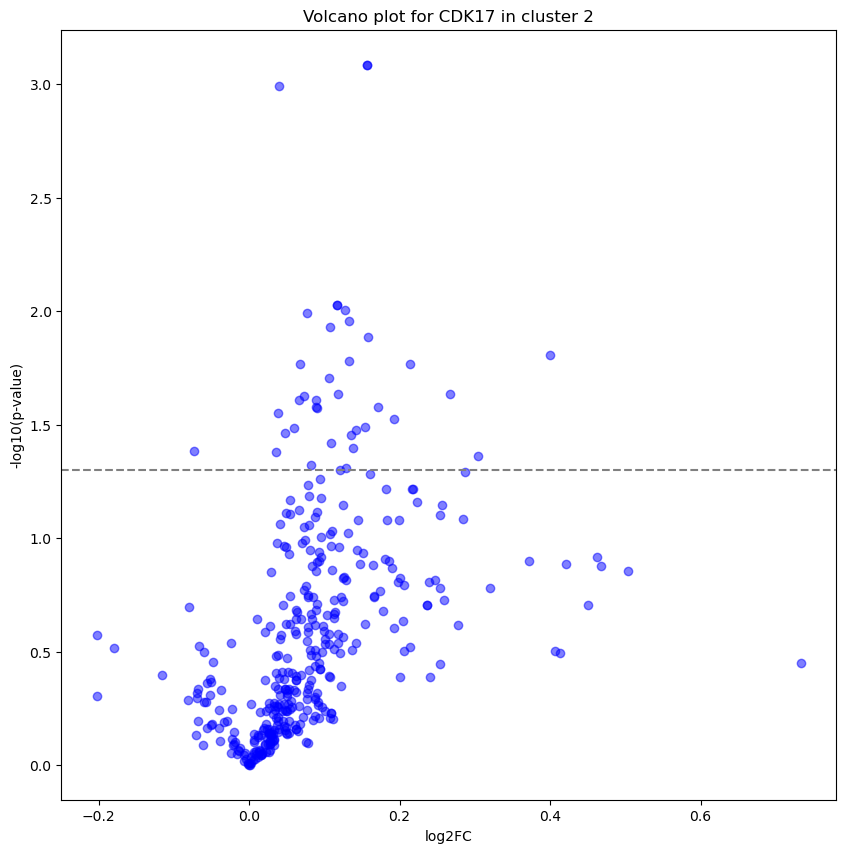

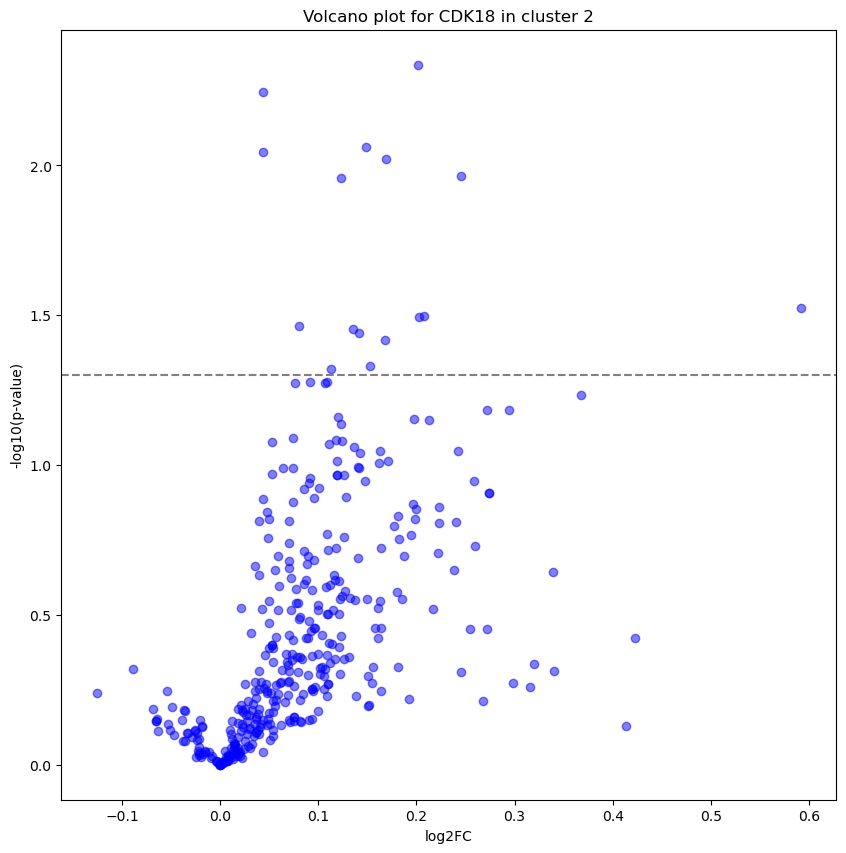

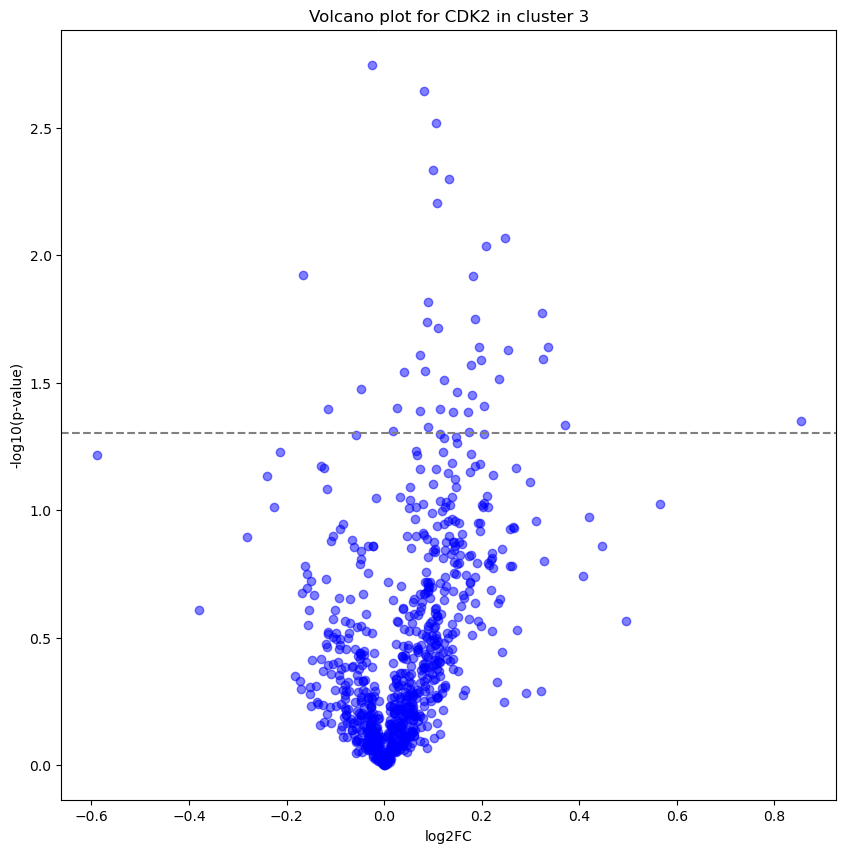

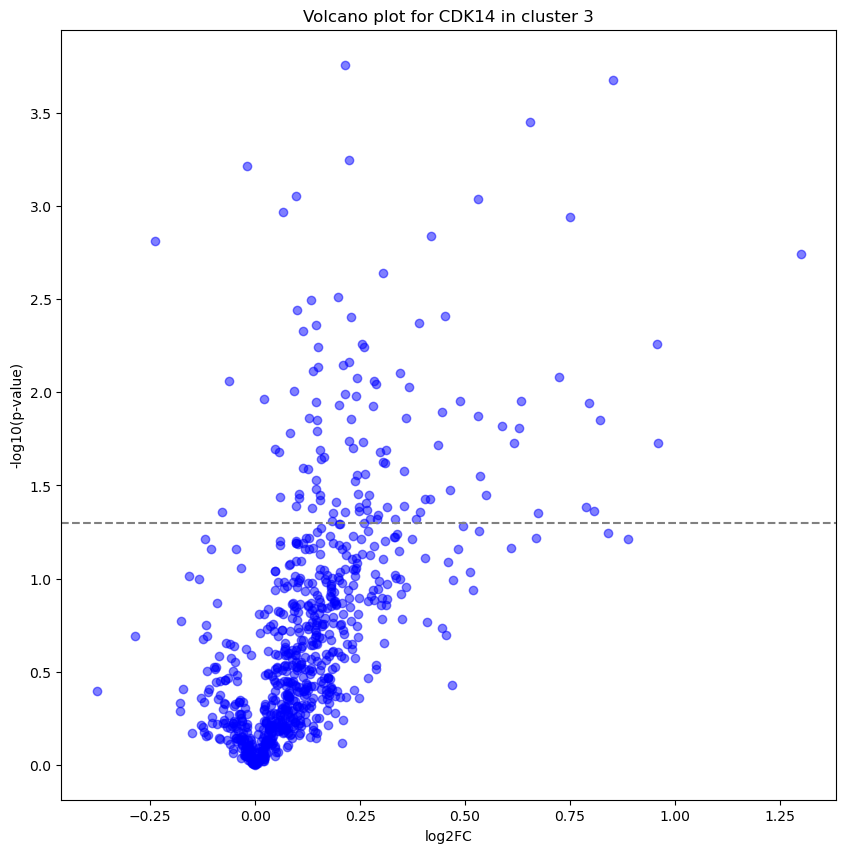

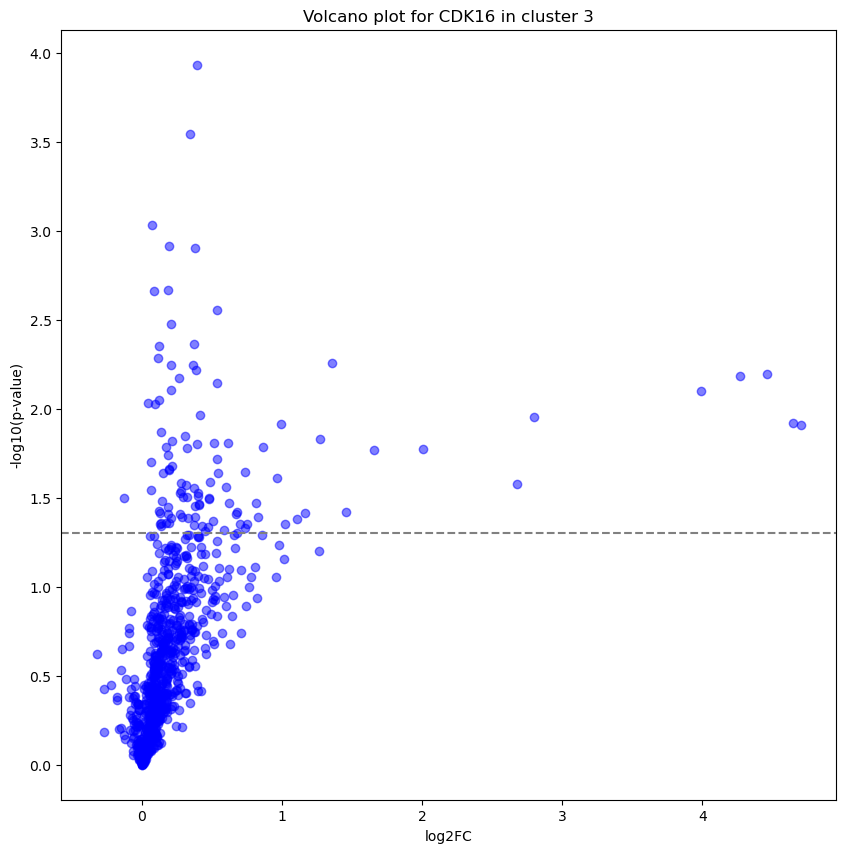

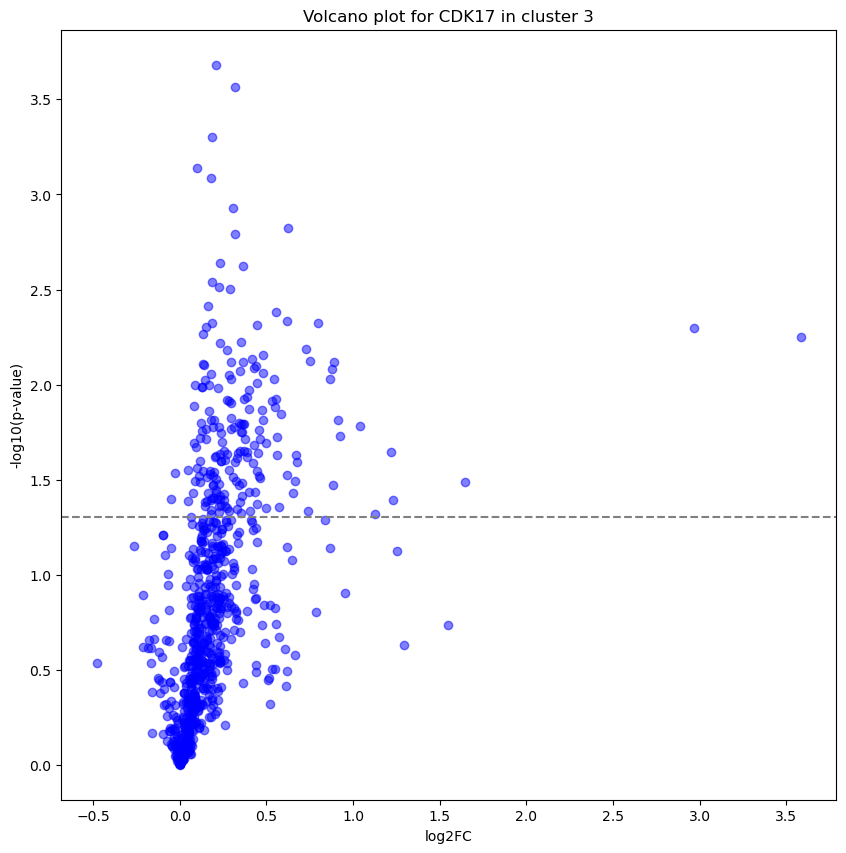

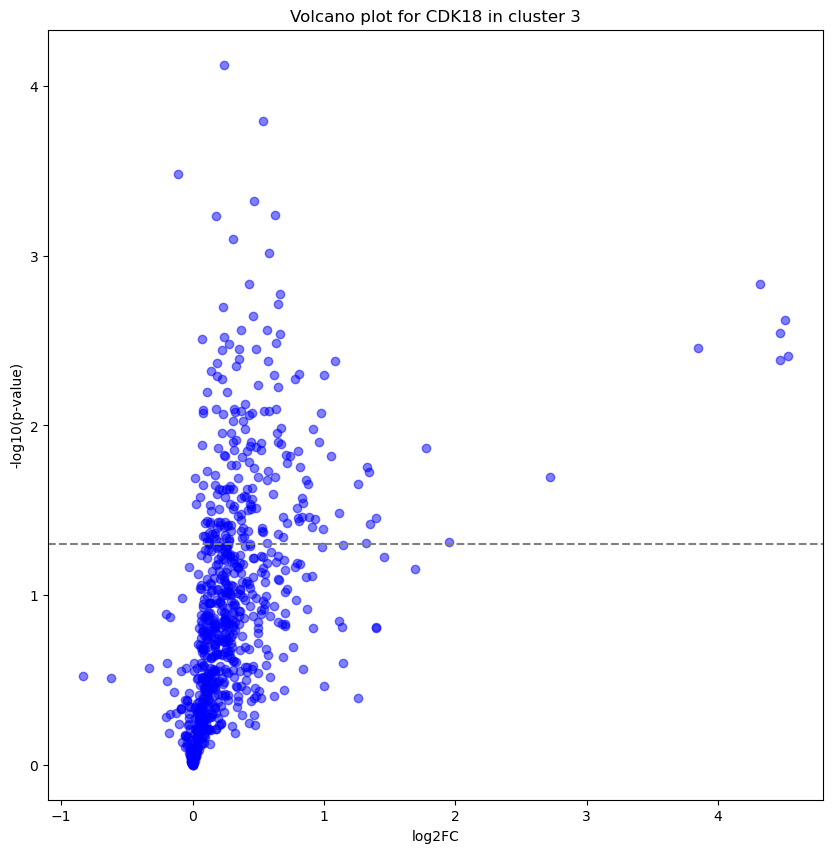

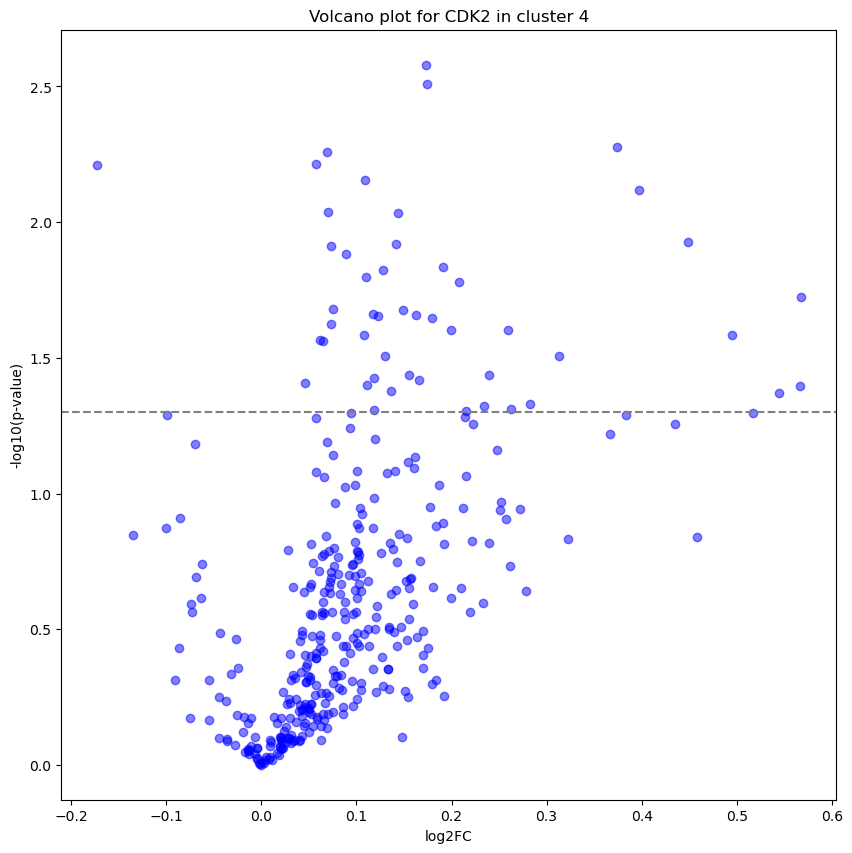

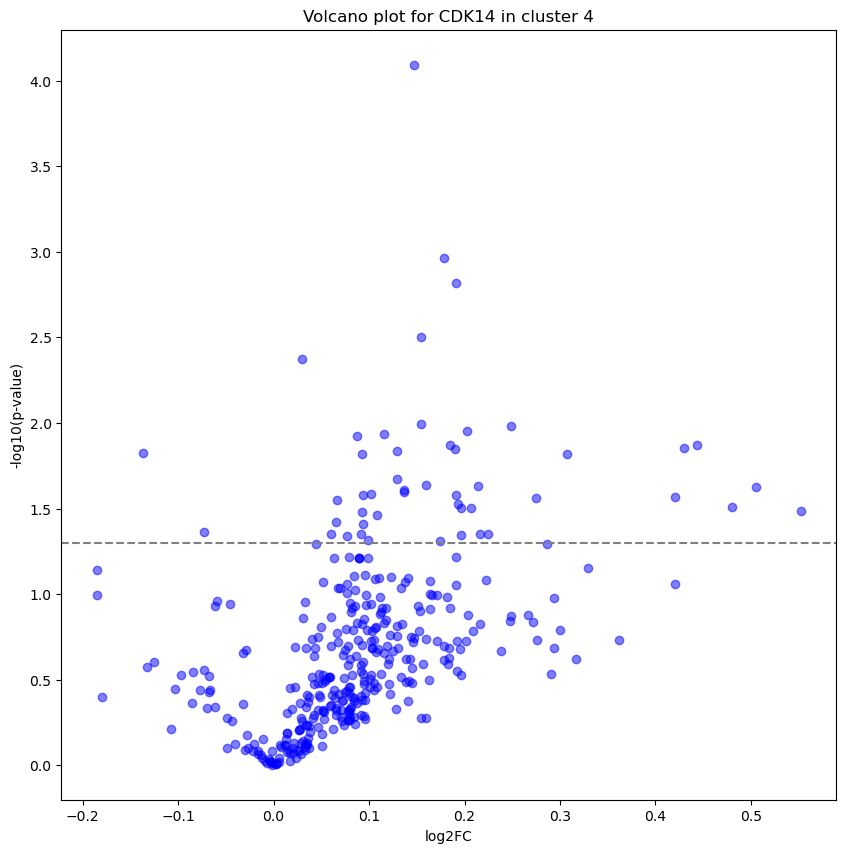

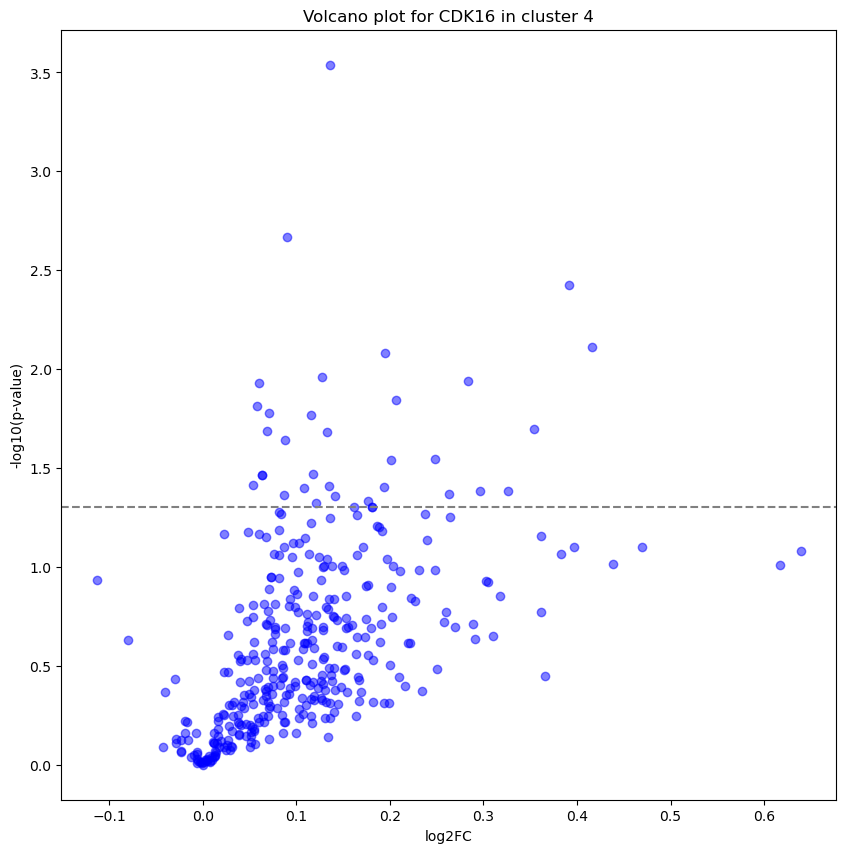

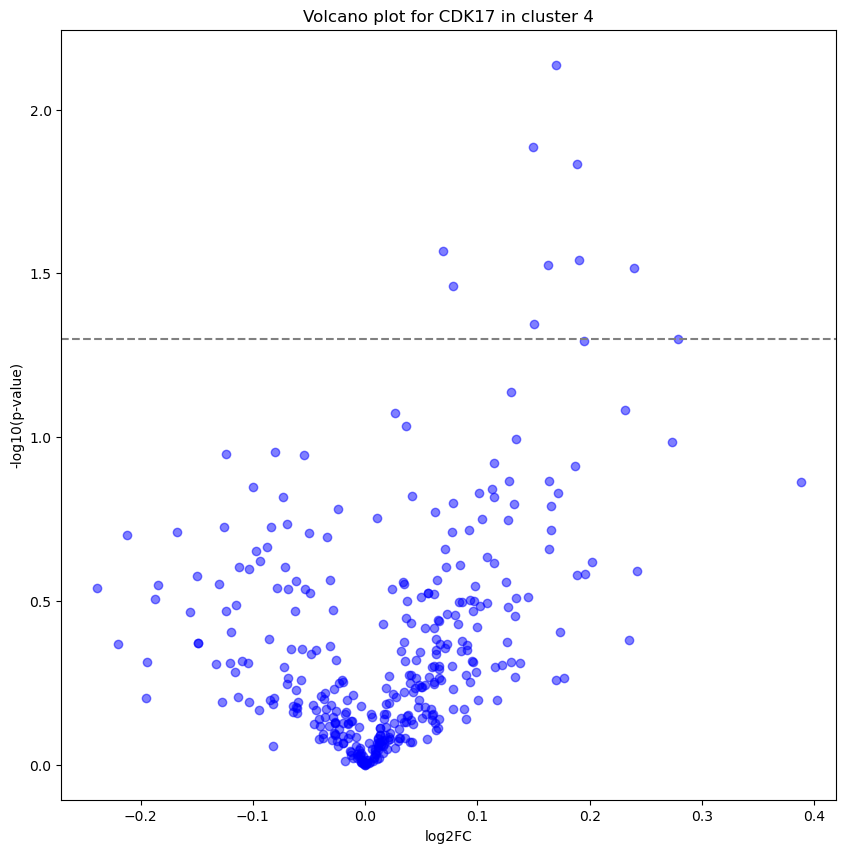

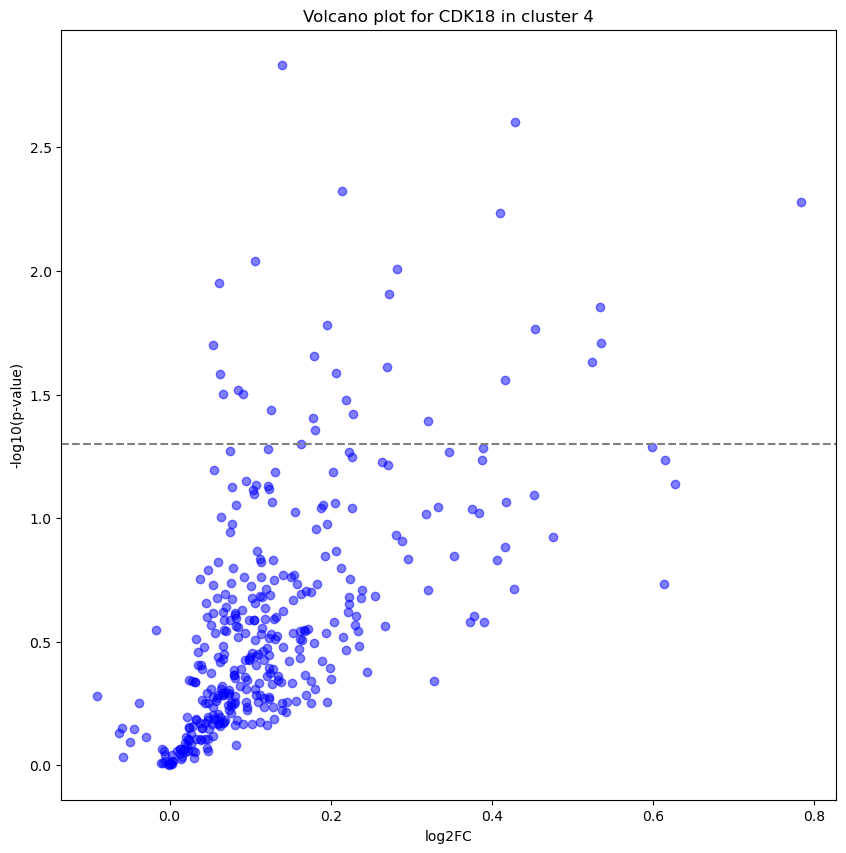

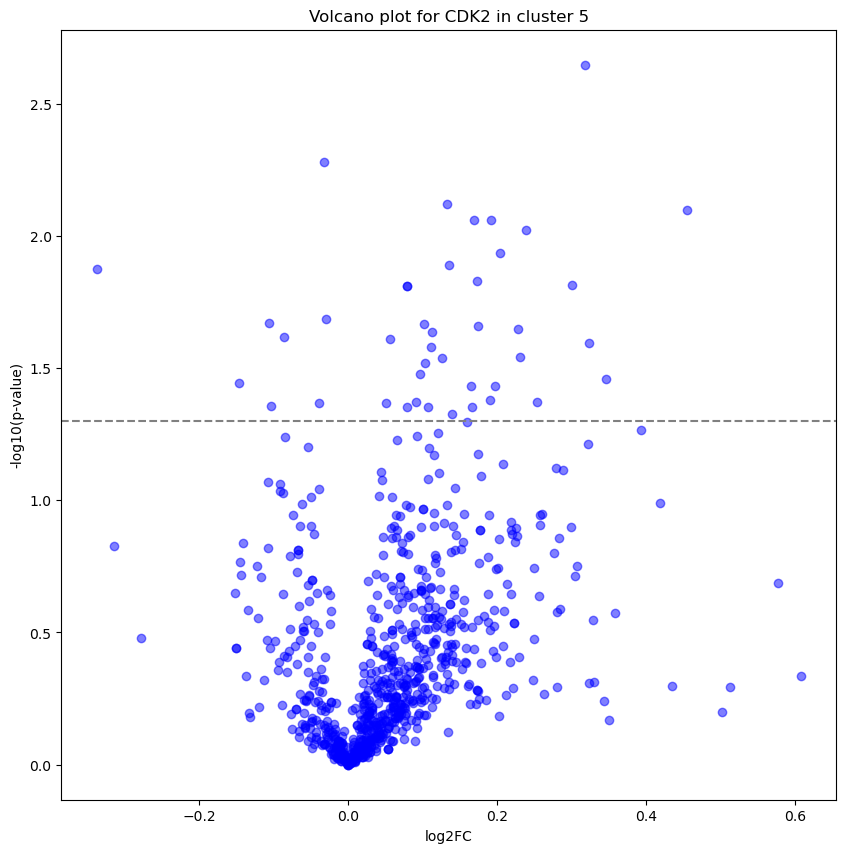

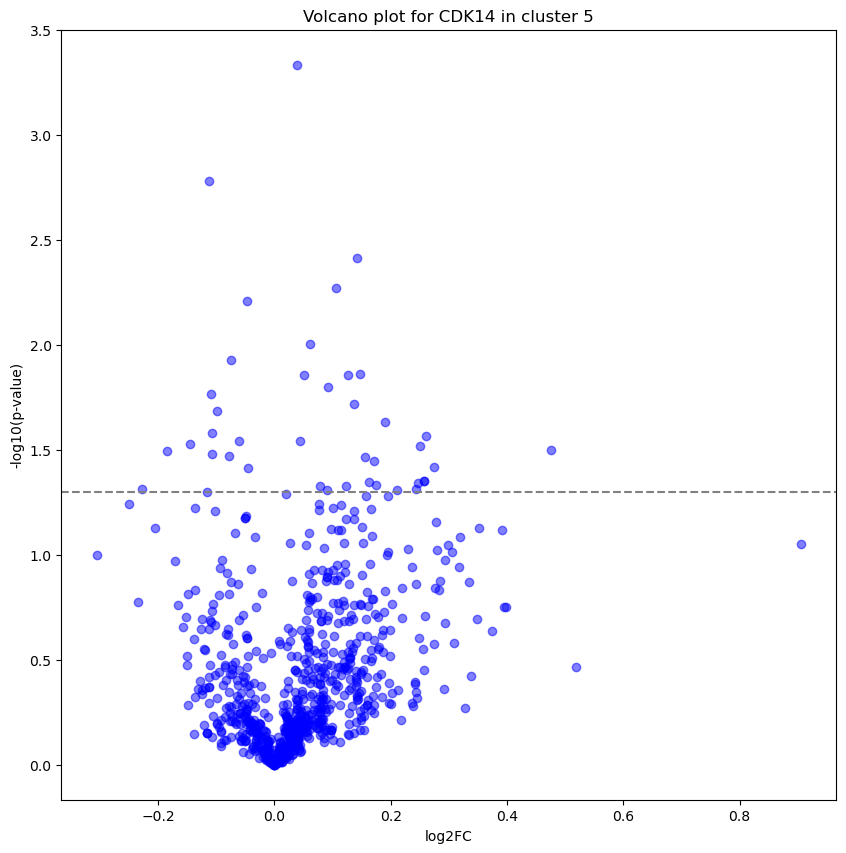

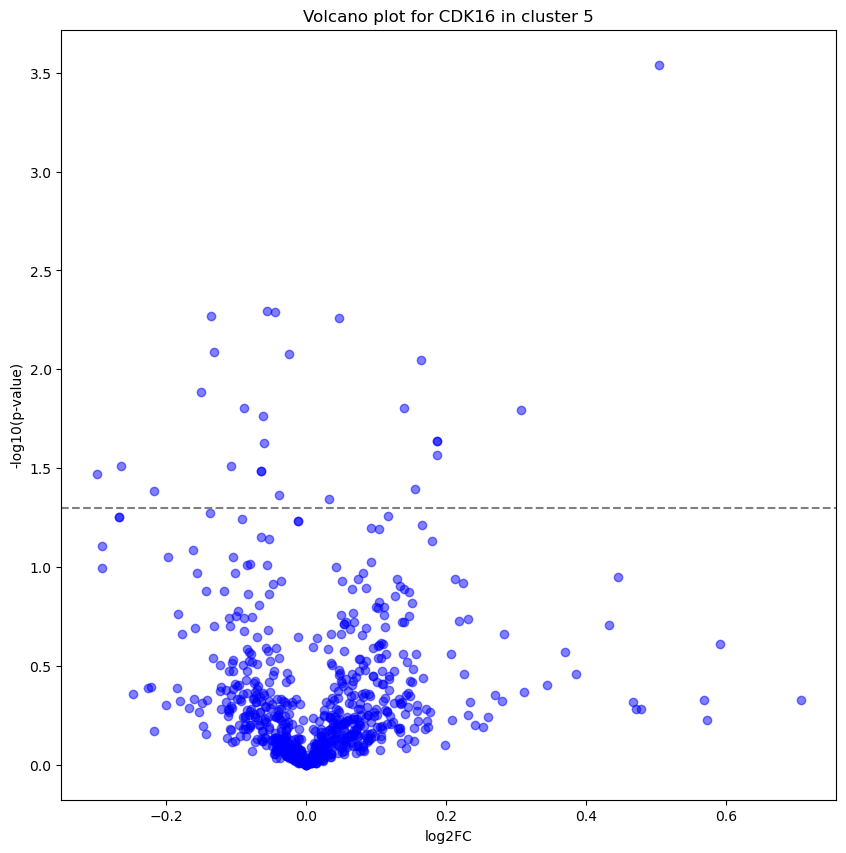

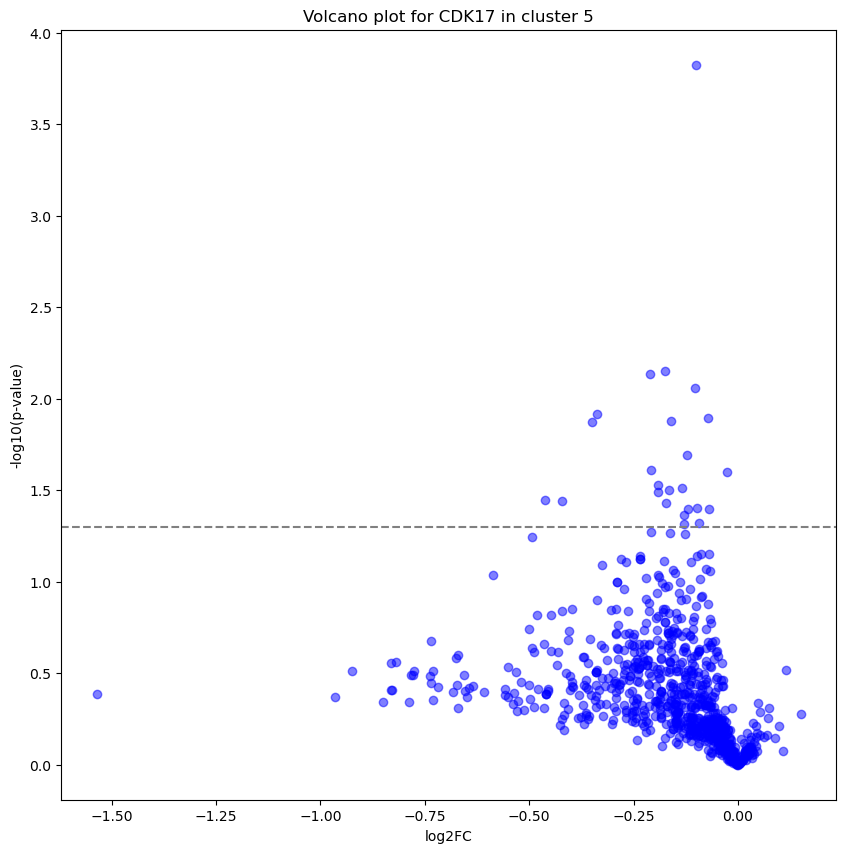

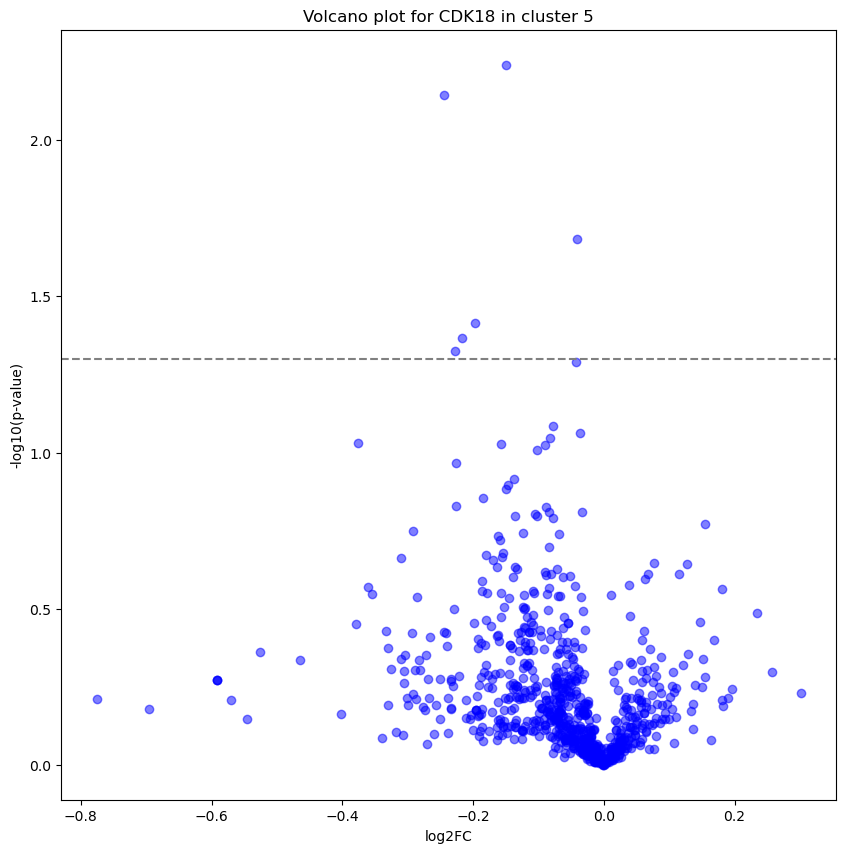

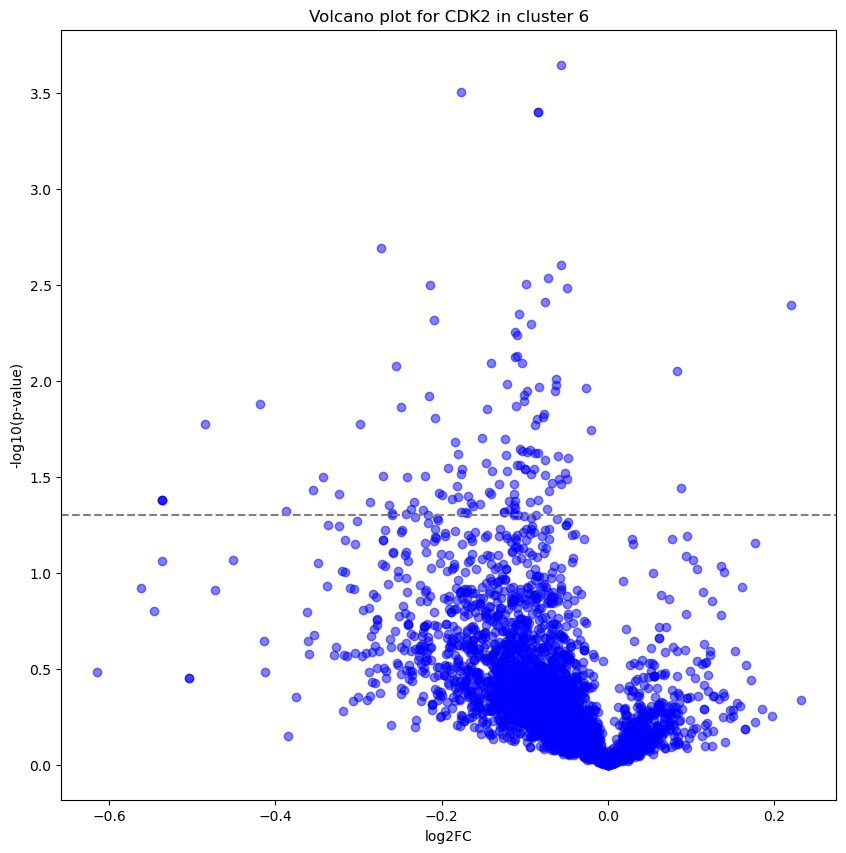

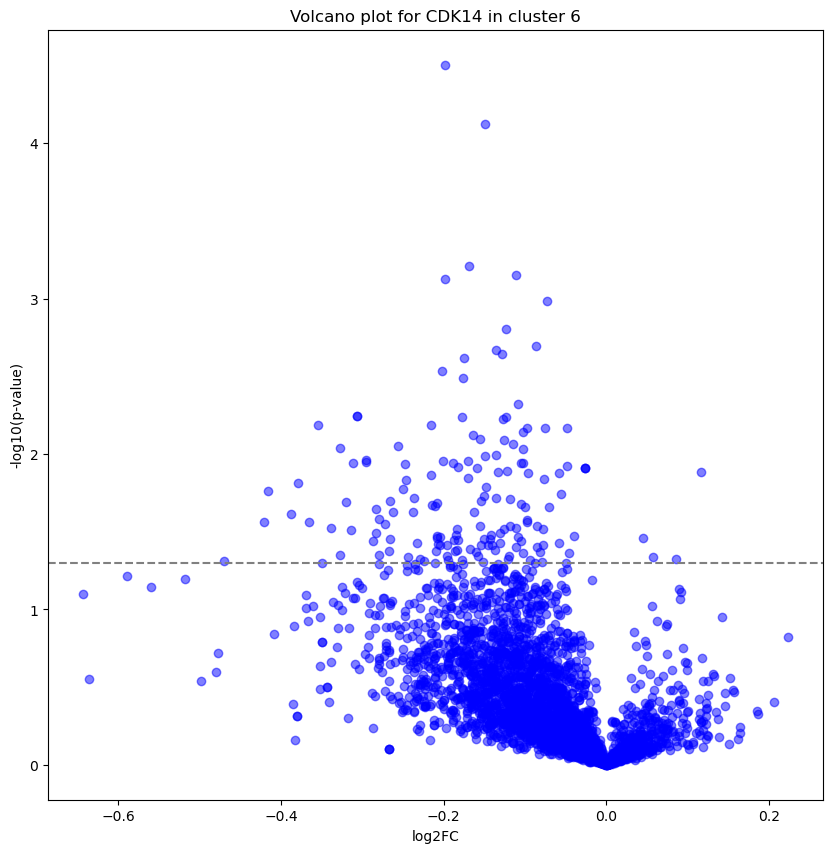

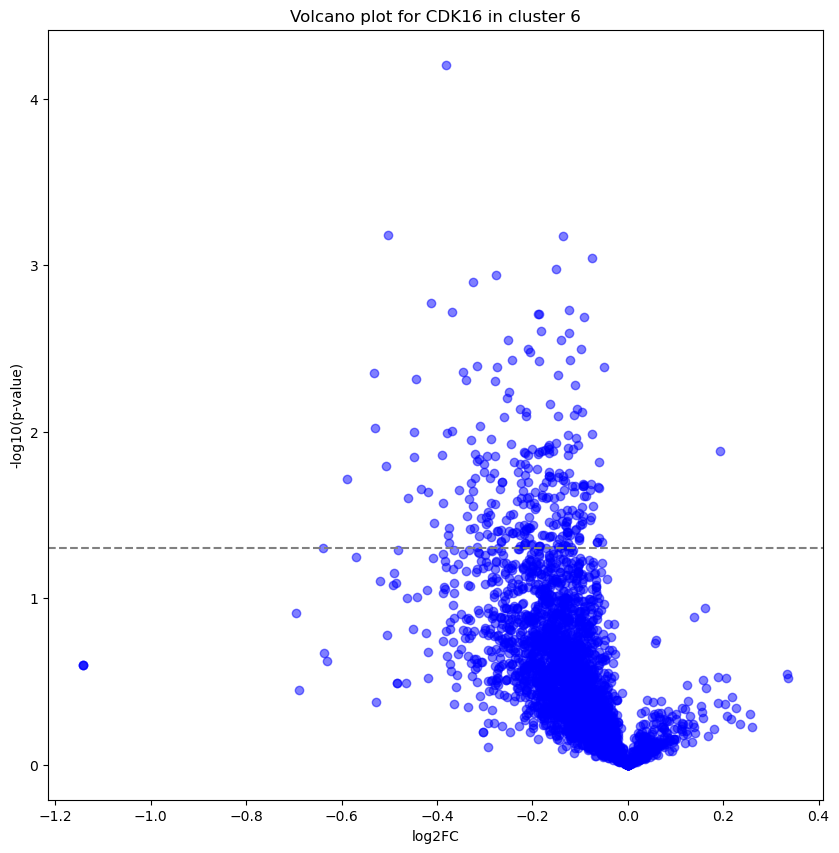

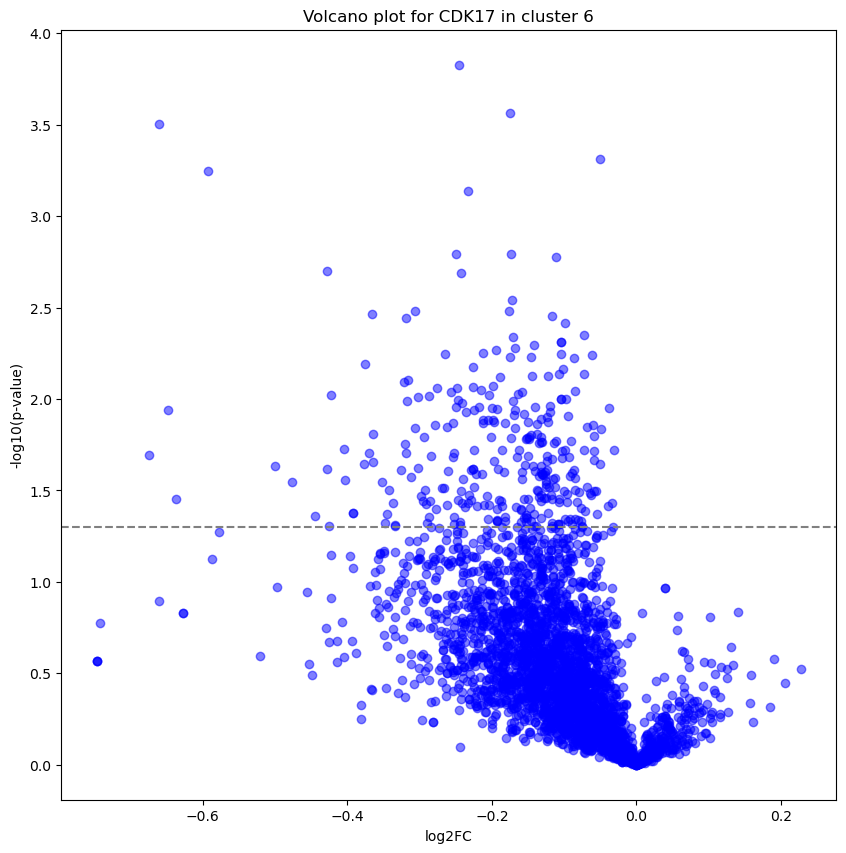

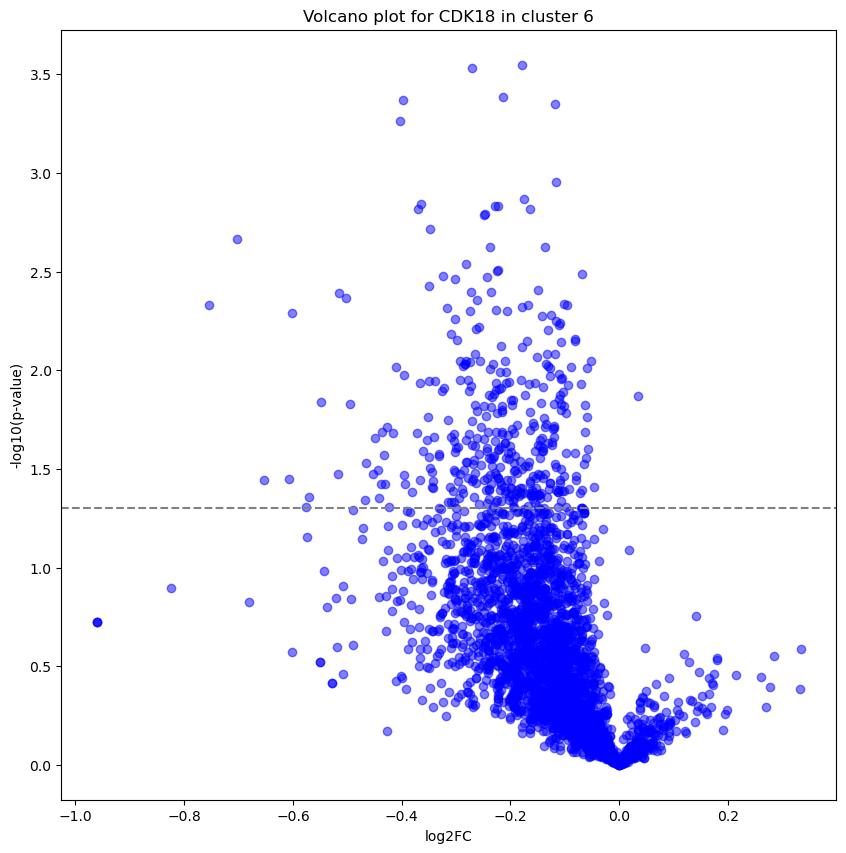

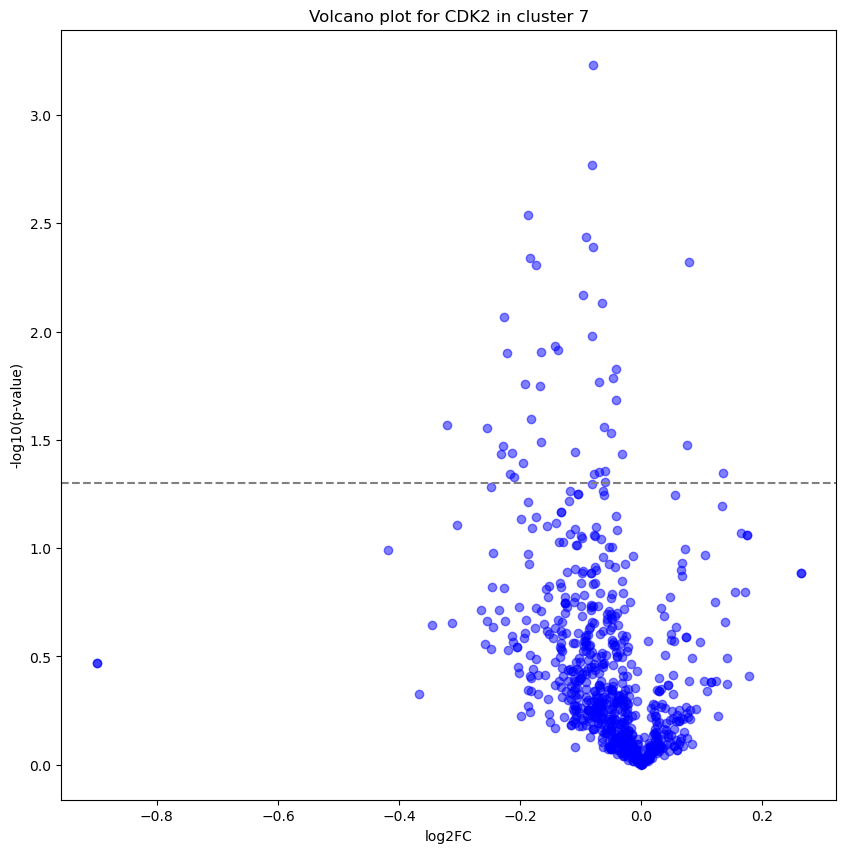

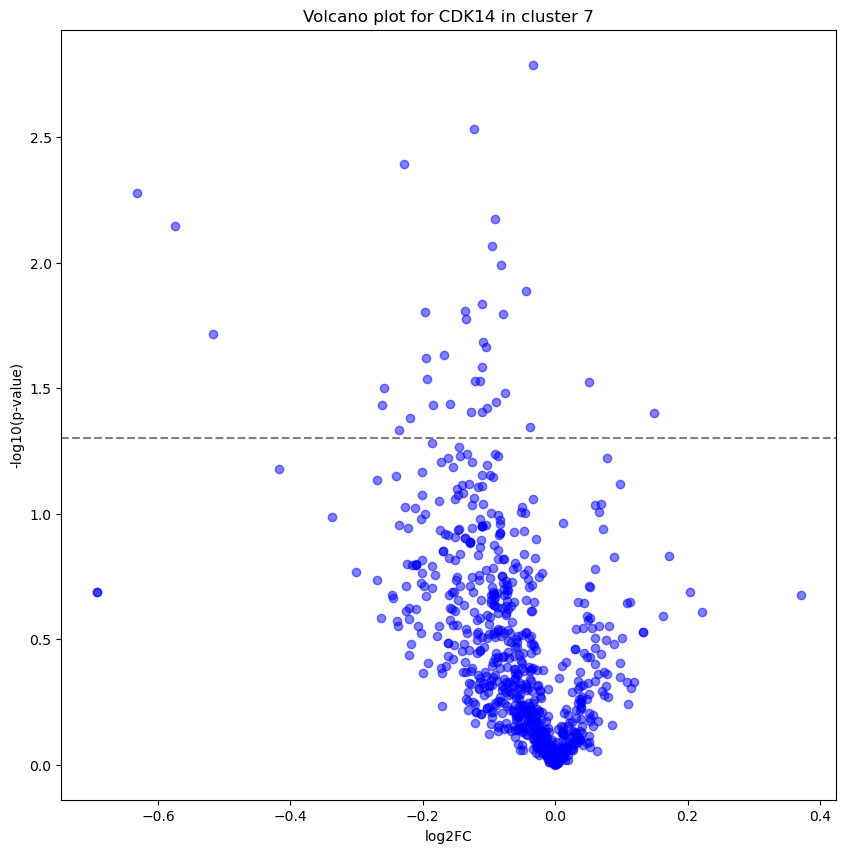

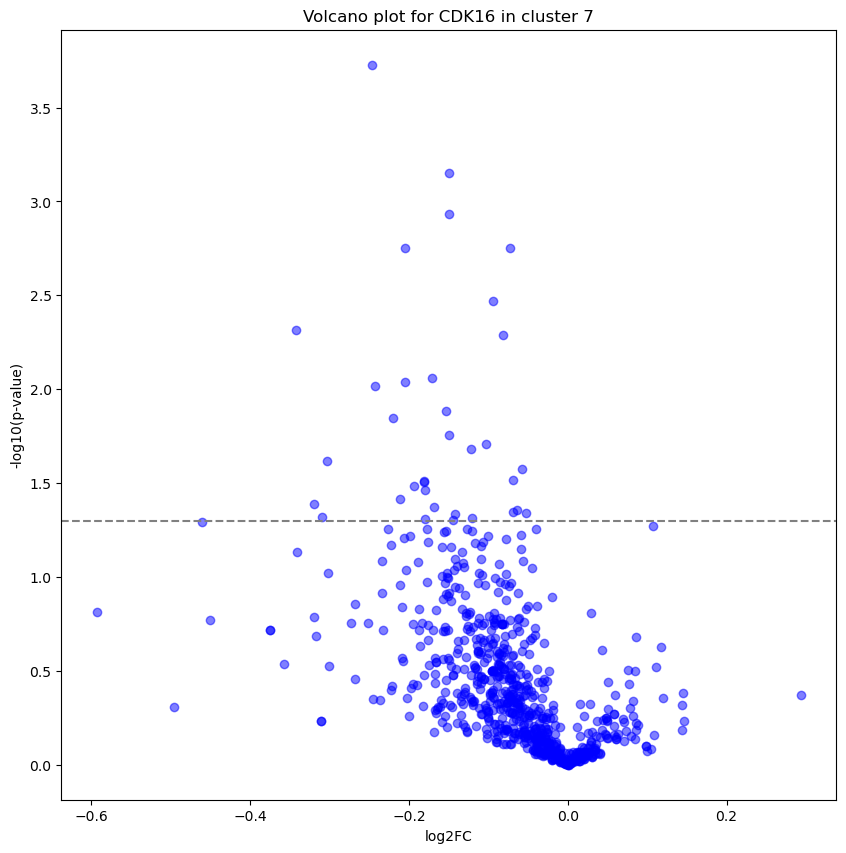

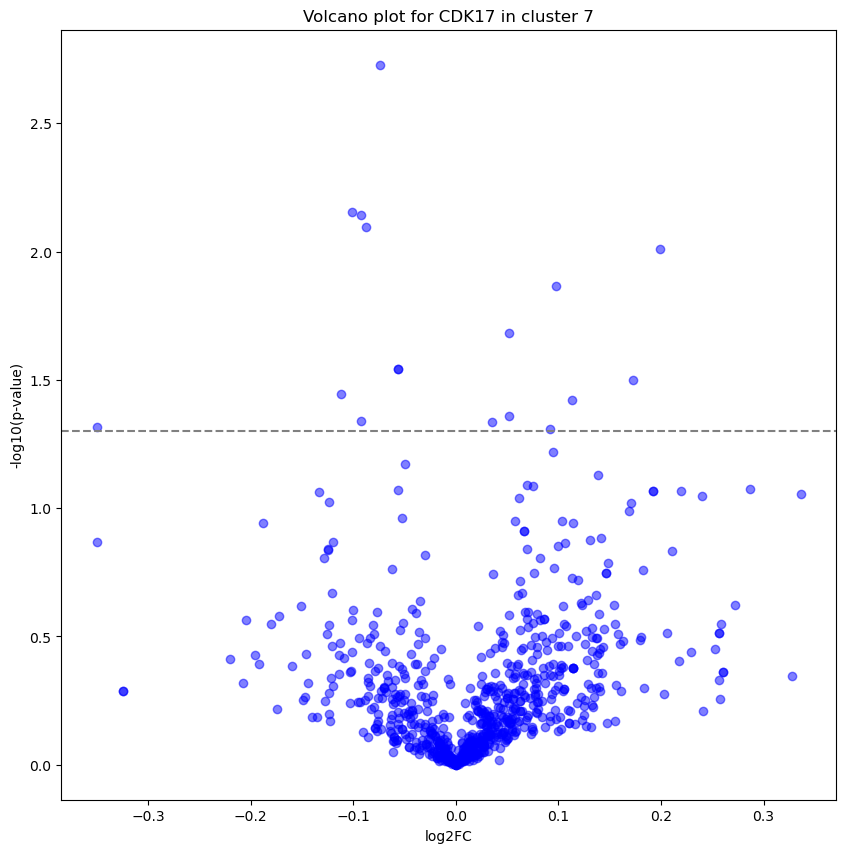

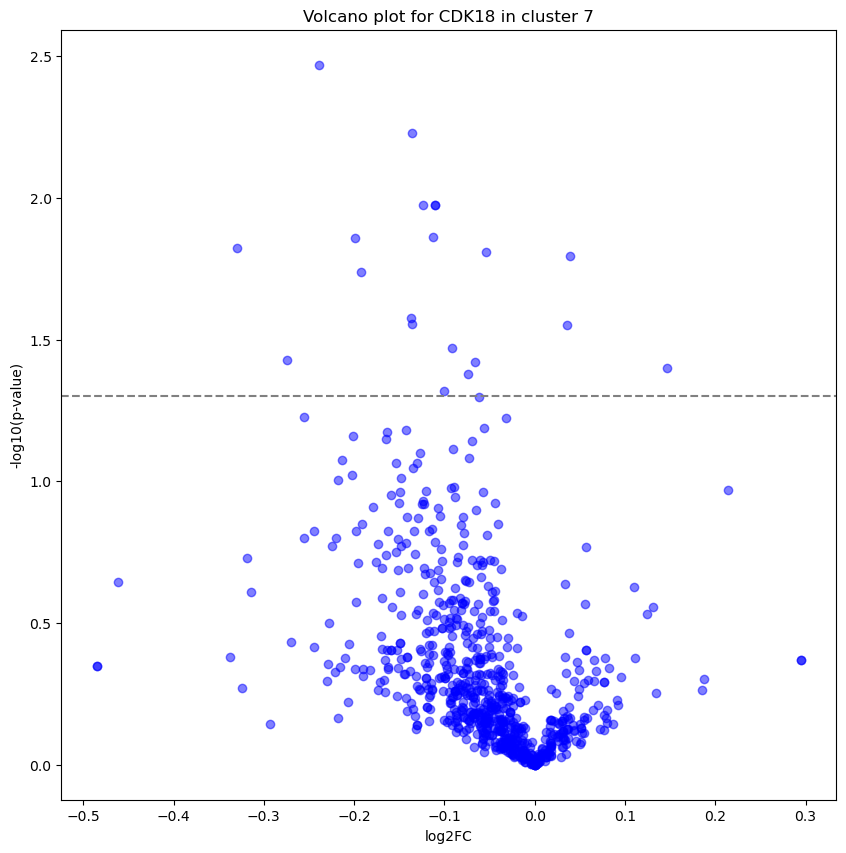

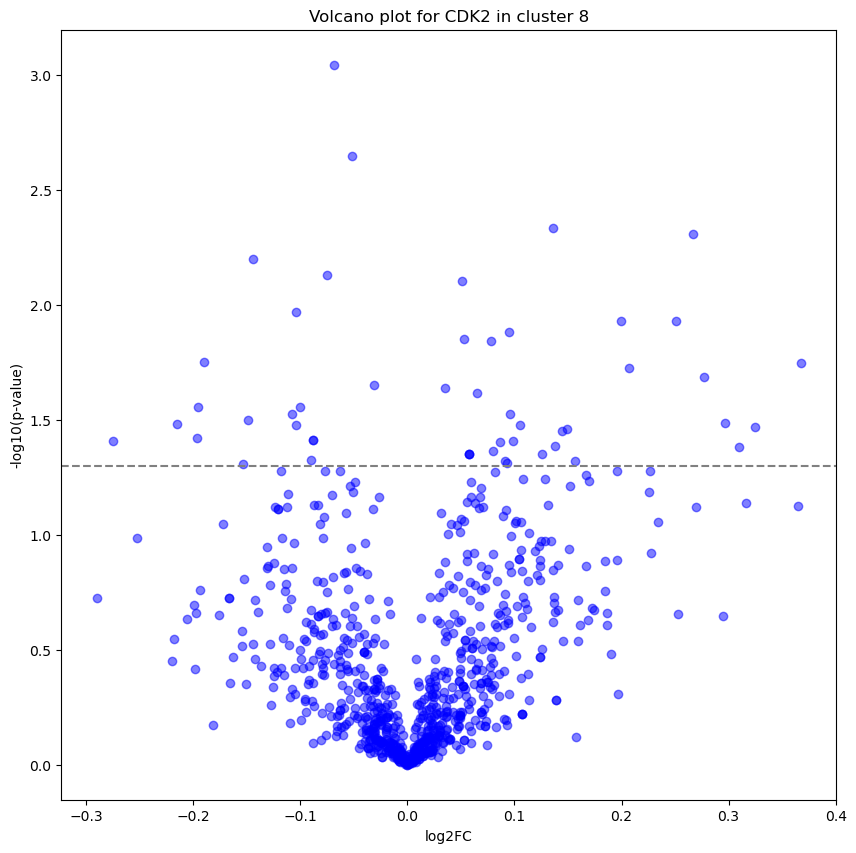

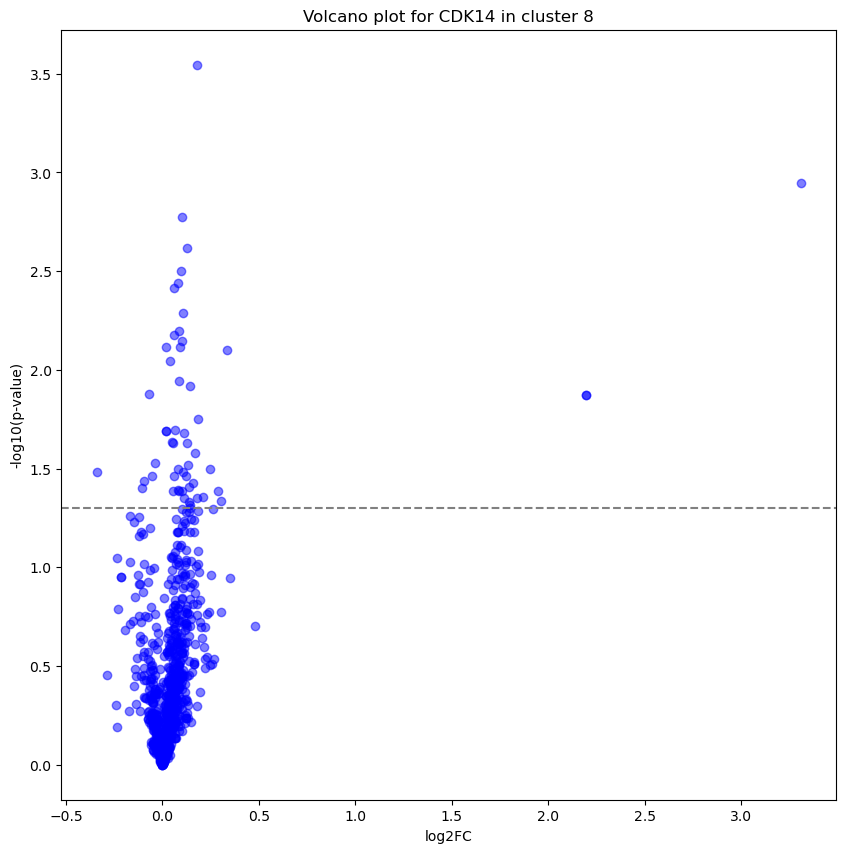

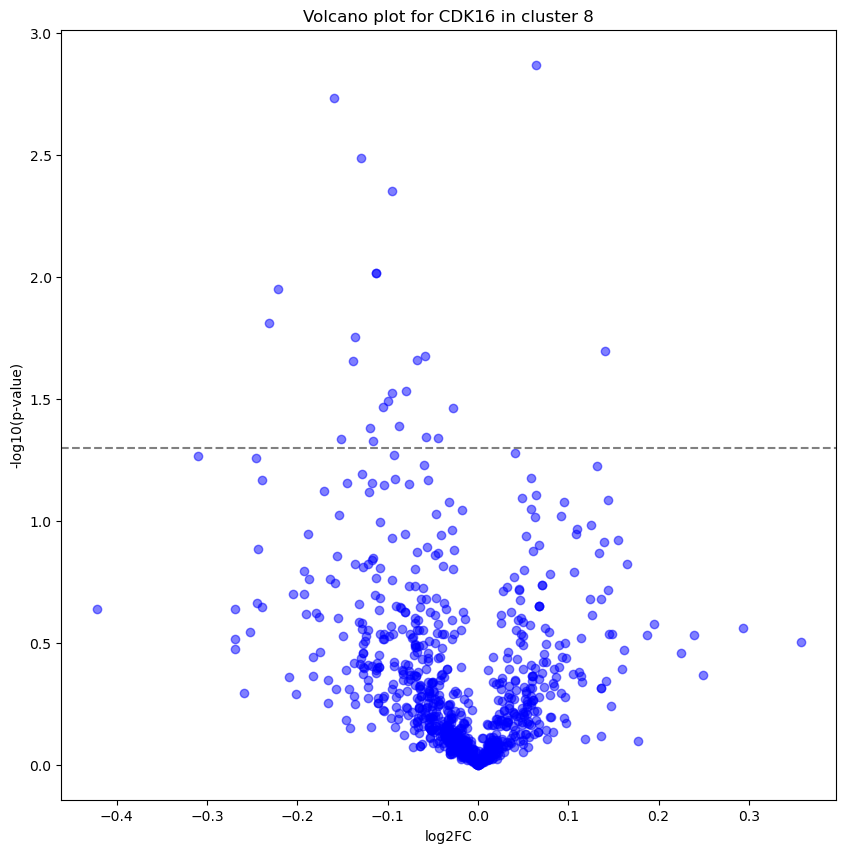

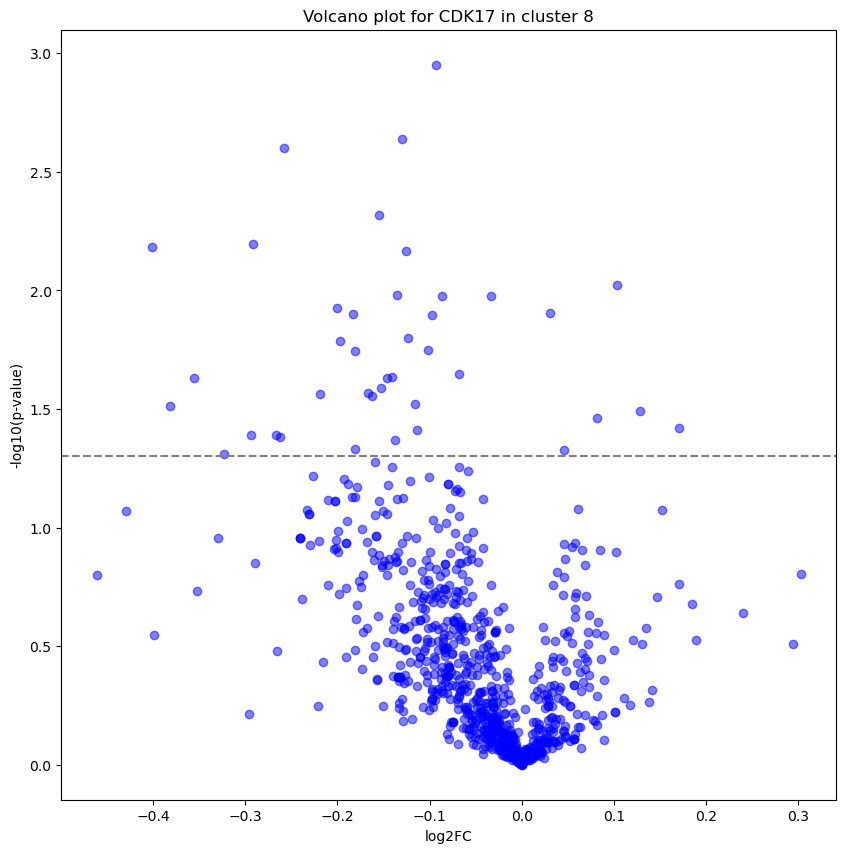

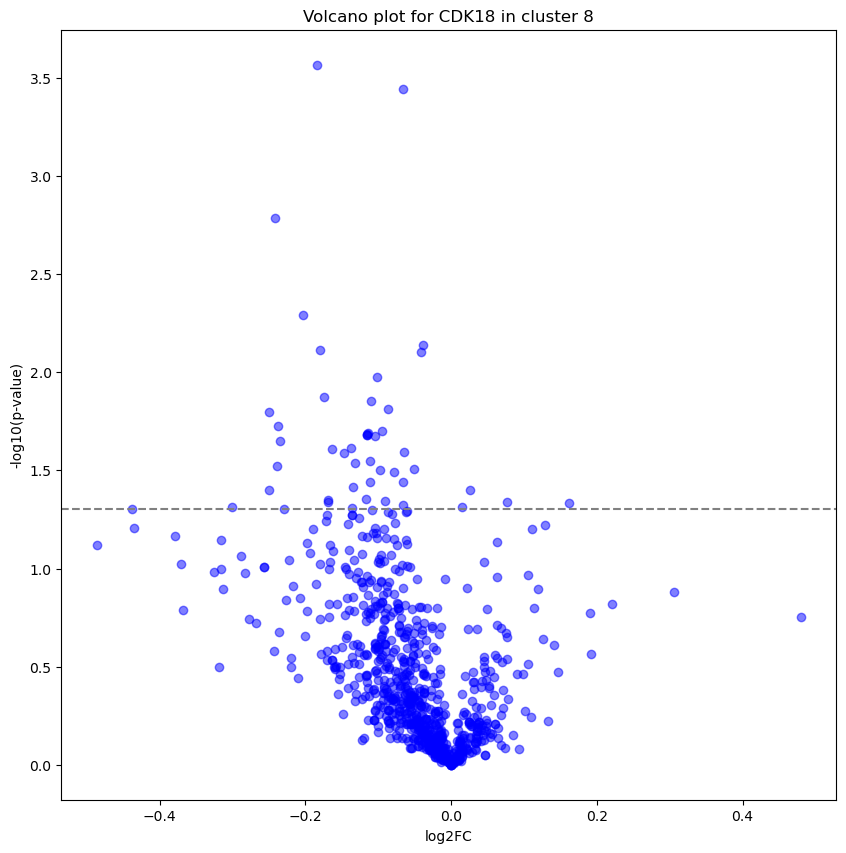

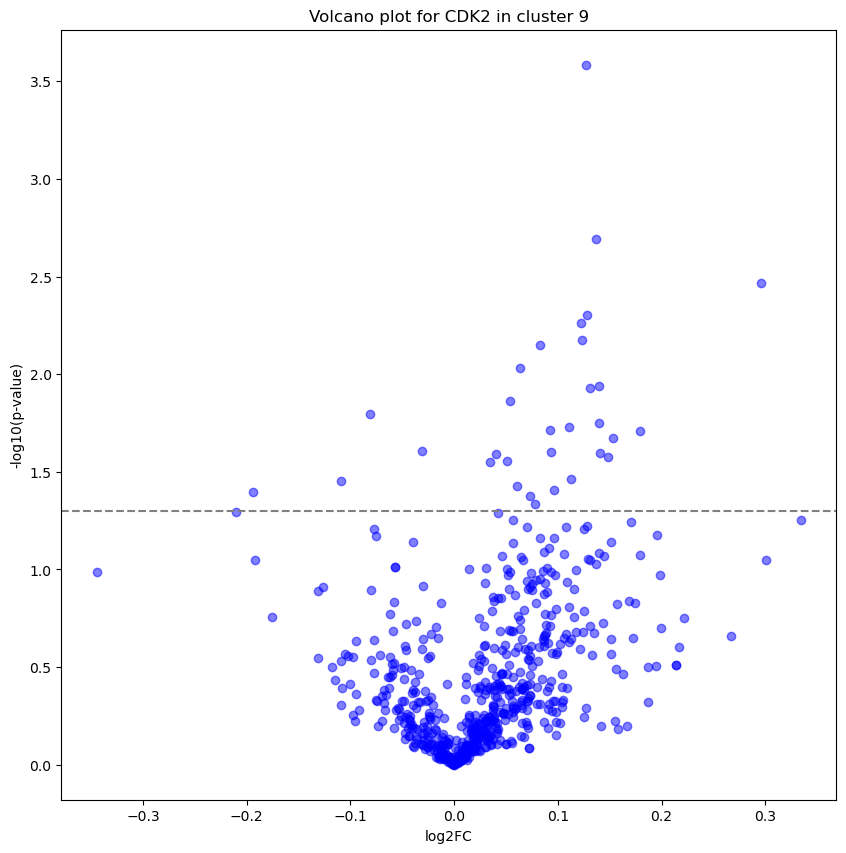

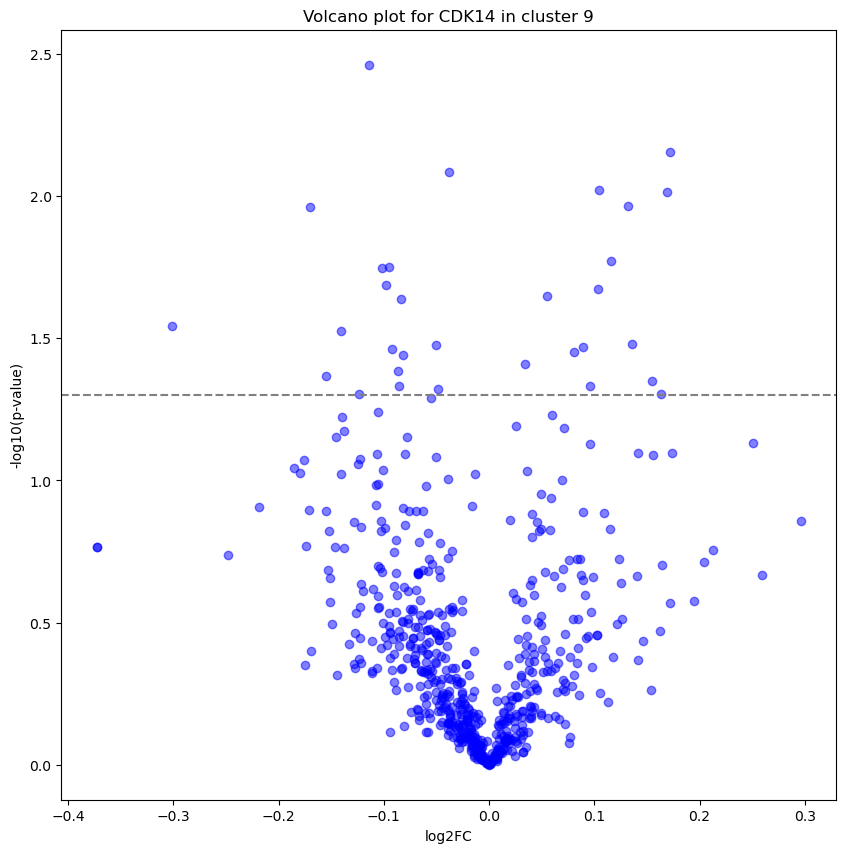

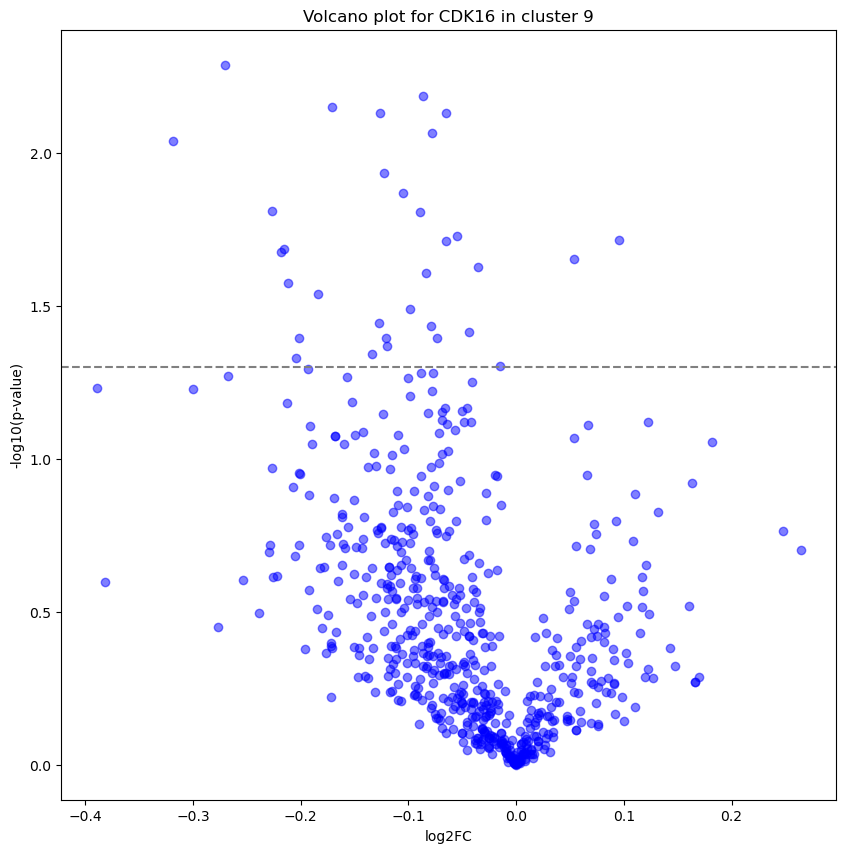

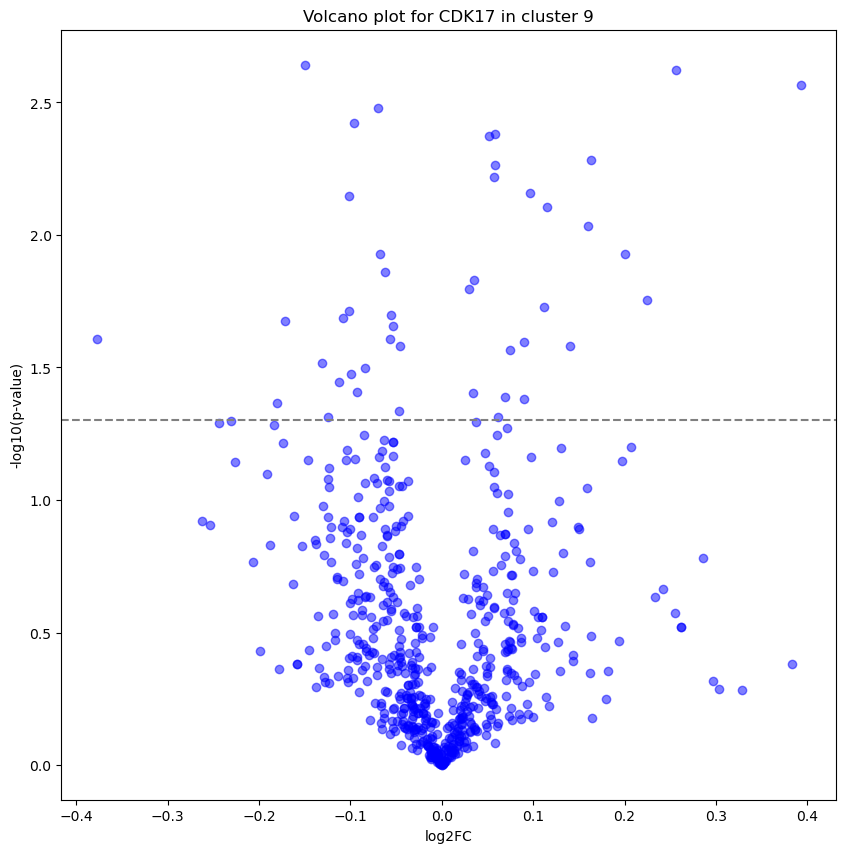

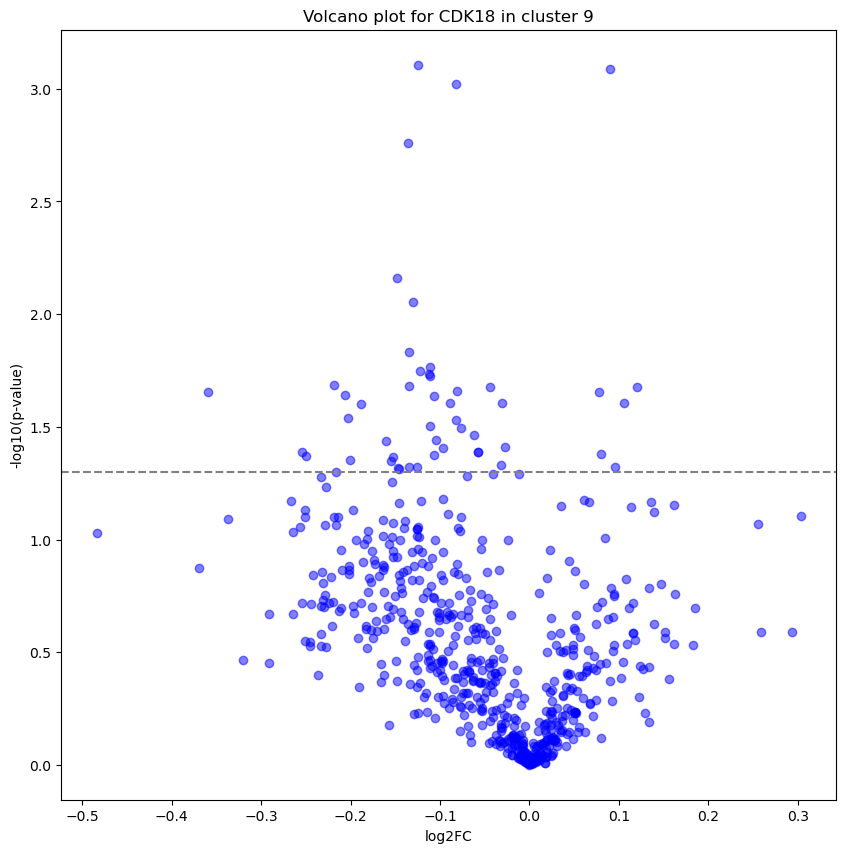

In [26]:
# I now want to make a volcano plot for each cluster and condition

# Make a list of the clusters
clusters = list(set(corr_clusters))

# Already have the comparisons dict

for cluster in clusters:
    for key in comparisons.keys():
        # Make a volcano plot
        fig, ax = plt.subplots(figsize=(10,10))
        # Use default colors for the clusters
        # Color the points on the volcano plot by cluster - use  the colors list
        # Don't do it with the for loop because it affects the order of the points
        scatter = ax.scatter(combined_zscore_with_fc['log2FC_' + key][combined_zscore_with_fc['cluster'] == cluster], -np.log10(combined_zscore_with_fc['pval_' + key][combined_zscore_with_fc['cluster'] == cluster]), c='blue', alpha=0.5)

        
        # Add a line for a significance threshold
        ax.axhline(y=-np.log10(0.05), color='grey', linestyle='--')

        ax.set_xlabel('log2FC')
        ax.set_ylabel('-log10(p-value)')
        ax.set_title('Volcano plot for ' + key + ' in cluster ' + str(cluster))
        fig.savefig(output_folder_path + 'cluster_' + str(cluster) + '_' + key + '_volcano.png')

In [27]:
# Lets further process the clusters...

#Make a dict to store the results
cluster_results = {}

# Iterate through each of the clusters
for cluster in clusters:
    # Filter the combined_zscore_with_fc dataframe to only include the current cluster
    cluster_df = combined_zscore_with_fc[combined_zscore_with_fc['cluster'] == cluster]
    # Get the protein names from the cluster_df
    names = list(set(cluster_df['Gene names']))

    # Remove NaNs from the names list
    names = [name for name in names if str(name) != 'nan']

    # Print the number of rows in the cluster_df
    print('Number of rows in cluster ' + str(cluster) + ': ' + str(len(cluster_df)))
    # Print the number of unique protein names in the cluster_df
    print('Number of unique protein names in cluster ' + str(cluster) + ': ' + str(len(names)))

    # Take the  first item in the names list
    first_names = [name.split(';')[0] for name in names]

    # Add info to the cluster_results dict
    cluster_results[cluster] = first_names

    # Write the list to a txt file
    with open(output_folder_path + 'cluster_' + str(cluster) + '_names.txt', 'w') as f:
        for name in first_names:
            f.write("%s\n" % name)

Number of rows in cluster 1: 831
Number of unique protein names in cluster 1: 589
Number of rows in cluster 2: 379
Number of unique protein names in cluster 2: 302
Number of rows in cluster 3: 810
Number of unique protein names in cluster 3: 608
Number of rows in cluster 4: 366
Number of unique protein names in cluster 4: 311
Number of rows in cluster 5: 806
Number of unique protein names in cluster 5: 607
Number of rows in cluster 6: 3357
Number of unique protein names in cluster 6: 1837
Number of rows in cluster 7: 780
Number of unique protein names in cluster 7: 602
Number of rows in cluster 8: 840
Number of unique protein names in cluster 8: 618
Number of rows in cluster 9: 635
Number of unique protein names in cluster 9: 485


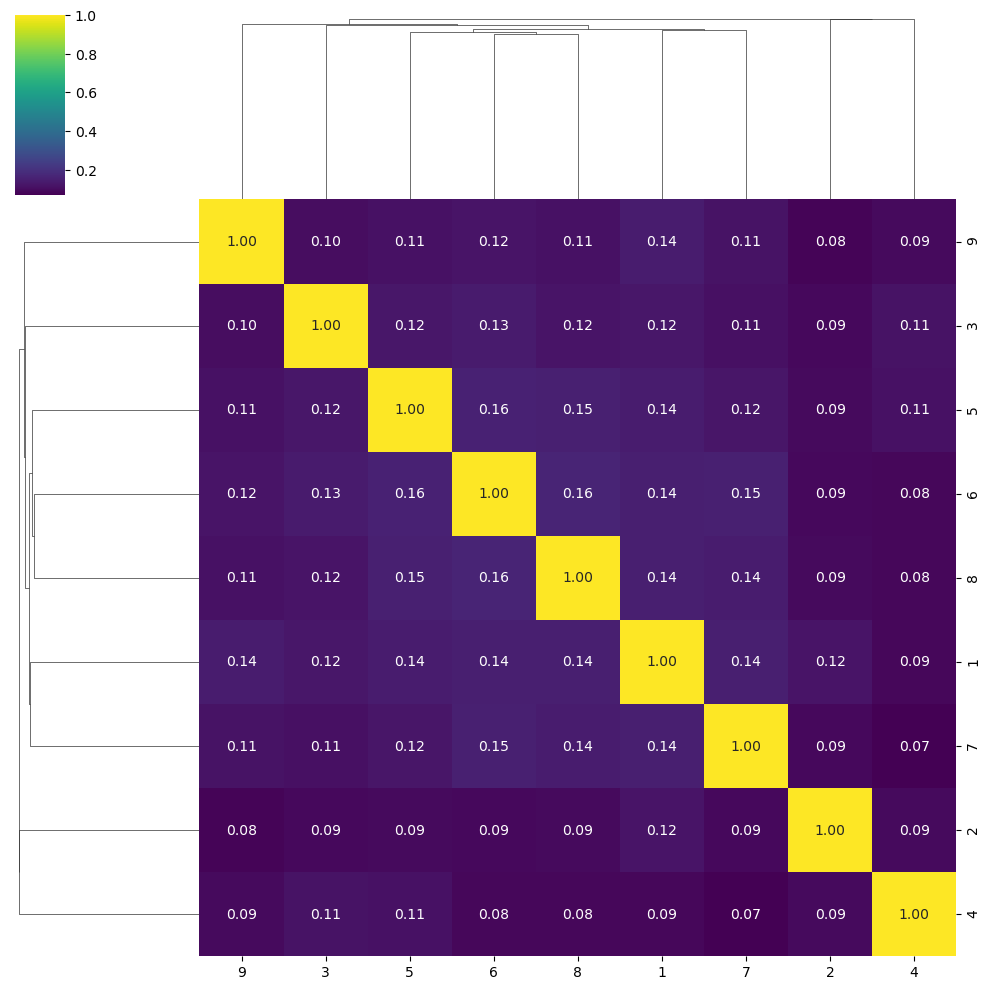

In [28]:
# I want to now make a jaccard index matrix for the clusters

# Make a np matrix to store the results
jaccard_matrix = np.zeros((len(clusters),len(clusters)))

# Iterate through each of the clusters
for i in range(len(clusters)):
    for j in range(len(clusters)):
        # Get the names for the current cluster
        names_i = cluster_results[clusters[i]]
        # Get the names for the current cluster
        names_j = cluster_results[clusters[j]]
        # Compute the jaccard index for the two clusters
        jaccard_matrix[i,j] = len(set(names_i).intersection(names_j)) / len(set(names_i).union(names_j))

# Make a dataframe from the jaccard matrix
jaccard_df = pd.DataFrame(jaccard_matrix, index=clusters, columns=clusters)

# Create a clustermap of the jaccard index matrix
g = sns.clustermap(jaccard_df, cmap='viridis', figsize=(10,10), annot=True, fmt='.2f')
g.savefig(output_folder_path + 'jaccard_index_clustermap.png')

In [29]:
# Save the correlation matrix to a csv file
corr.to_csv(output_folder_path + 'correlation_matrix.csv')

In [31]:
# Now time to integrate with the proximity data
prox = pd.read_csv(proximity_file_name)
prox

,Experiment.ID,First.Prey.GeneID,Bait.Gene.Name,Bait,First.Bait.Uniprot,Canonical.First.Bait.Uniprot,Bait.Gene.Synonym,Bait.GeneID,boosted_by,Prey.Gene.Name,...,kinase_com_name,class_2019,is_Bait,BaitGene,in.BioGRID,Evidence.Weight,Experimental.Systems,Authors,Publications,Multivalidated
0,NES-mT-KL-60m-Rapi,NaN,NaN,IDGT6,IDGT6,IDGT6,NaN,NaN,NaN,NaN,...,NaN,NaN,True,NaN,False,NaN,NaN,NaN,NaN,False
1,NES-mT-KL-60m-Rapi,NaN,NaN,IDGT6,IDGT6,IDGT6,NaN,NaN,NaN,NaN,...,NaN,NaN,True,IDGT6,False,NaN,NaN,NaN,NaN,False
2,mT-NES-2hrB-Rapi,NaN,NaN,IDGT6,IDGT6,IDGT6,NaN,NaN,NaN,NaN,...,NaN,NaN,True,NaN,False,NaN,NaN,NaN,NaN,False
3,mT-NES-2hrB-Rapi,NaN,NaN,IDGT6,IDGT6,IDGT6,NaN,NaN,NaN,NaN,...,NaN,NaN,True,IDGT6,False,NaN,NaN,NaN,NaN,False
4,CUL3-mT-IB,57563.0,CUL3,Q13618,Q13618,Q13618,KIAA0617,8452,NaN,KLHL8,...,NaN,NaN,False,CUL3,True,6.0,Affinity Capture-MS;Affinity Capture-MS;Affini...,Bennett EJ (2010);Huttlin EL (2017);Kato K (20...,PUBMED:21145461;PUBMED:28514442;PUBMED:3313082...,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
348404,mT-CDK2-2hrB,8562.0,CDK2,P24941,P24941,P24941,CDKN2,1017,NaN,DENR,...,NaN,NaN,False,CDK2,False,NaN,NaN,NaN,NaN,False
348405,PSKH2-mT-30mB,63967.0,PSKH2,Q96QS6,Q96QS6,Q96QS6,NaN,85481,NaN,CLSPN,...,NaN,NaN,False,PSKH2,False,NaN,NaN,NaN,NaN,False
348406,PSKH2-mT-30mB,64682.0,PSKH2,Q96QS6,Q96QS6,Q96QS6,NaN,85481,NaN,ANAPC1,...,NaN,NaN,False,PSKH2,False,NaN,NaN,NaN,NaN,False
348407,PSKH2-mT-30mB,7272.0,PSKH2,Q96QS6,Q96QS6,Q96QS6,NaN,85481,NaN,TTK,...,TTK,Light,False,PSKH2,False,NaN,NaN,NaN,NaN,False


In [37]:
# Subset the proximity data for each comparison using the gene name of the comparison
bait_data = {}

for key in comparisons.keys():
    # Subset the proximity data for the gene names
    prox_subset = prox[prox['Bait.Gene.Name'] == key]
    # Write the proximity data to a csv file
    bait_data[key] = prox_subset

# Now I want to define a function that takes in a gene name and a bait name and returns the SaintScore for that bait-gene pair using the bait_data dict

def get_saint_score(gene_name, bait_name):
    # Get the bait data for the current bait
    bait_df = bait_data[bait_name]
    # Get the saint score for the current gene
    saint_score = bait_df[bait_df['Prey.Gene.Name'] == gene_name]['SaintScore']
    # Check if the saint score is empty
    if len(saint_score) == 0:
        return 0
    else:
        return saint_score.values[0]
    
# Now I want to add a column to the combined_zscore_with_fc dataframe for each bait that contains the saint score for that bait-gene pair
for key in bait_data:
    combined_zscore_with_fc['SaintScore_' + key] = combined_zscore_with_fc['Gene names'].apply(lambda x: get_saint_score(x, key))

In [166]:
# Write the combined_zscore_with_fc dataframe to a csv file
combined_zscore_with_fc.to_csv(output_folder_path + 'combined_with_saint_scores.csv')

In [42]:
# Set the thresholds
p_value_threshold = 0.05
log2_fold_change_threshold = 0.5
saint_score_threshold = 0.7

# Create an empty dictionary to store the lists of substrates for each kinase
substrates = {}

# Iterate over each kinase in the comparisons dictionary
for kinase in comparisons.keys():
    # Filter the combined_zscore_with_fc dataframe based on the thresholds
    filtered_df = combined_zscore_with_fc[(combined_zscore_with_fc['pval_' + kinase] < p_value_threshold) &
                                          (combined_zscore_with_fc['log2FC_' + kinase] > log2_fold_change_threshold) &
                                          (combined_zscore_with_fc['SaintScore_' + kinase] > saint_score_threshold)]
    
    # Get the list of substrates for the current kinase
    substrate_list = filtered_df['Gene names'].tolist()
    
    # Add the list of substrates to the substrates dictionary
    substrates[kinase] = substrate_list

# Print the lists of substrates for each kinase
for kinase, substrate_list in substrates.items():
    print(f"Substrates for {kinase}: {substrate_list}")


Substrates for CDK2: ['XRCC6', 'CBS', 'SRRT']
Substrates for CDK14: ['CDK14', 'CDK14', 'CDK14']
Substrates for CDK16: ['IRS4', 'EPB41L2', 'CDK16', 'CDK16', 'CDK16', 'CDK16', 'CDK16', 'CDK16', 'CDK16', 'CDK16', 'AHNAK', 'OCLN', 'CDK16', 'SCRIB']
Substrates for CDK17: ['CDK17', 'CDK17', 'CDK17', 'PRRC2B', 'PRRC2B']
Substrates for CDK18: ['DDX3X', 'MAP4', 'MAP1B', 'RANBP2', 'CDK18', 'CDK18', 'CDK18', 'CDK18', 'CDK18', 'CDK18', 'CDK18', 'CDK18', 'GRSF1']


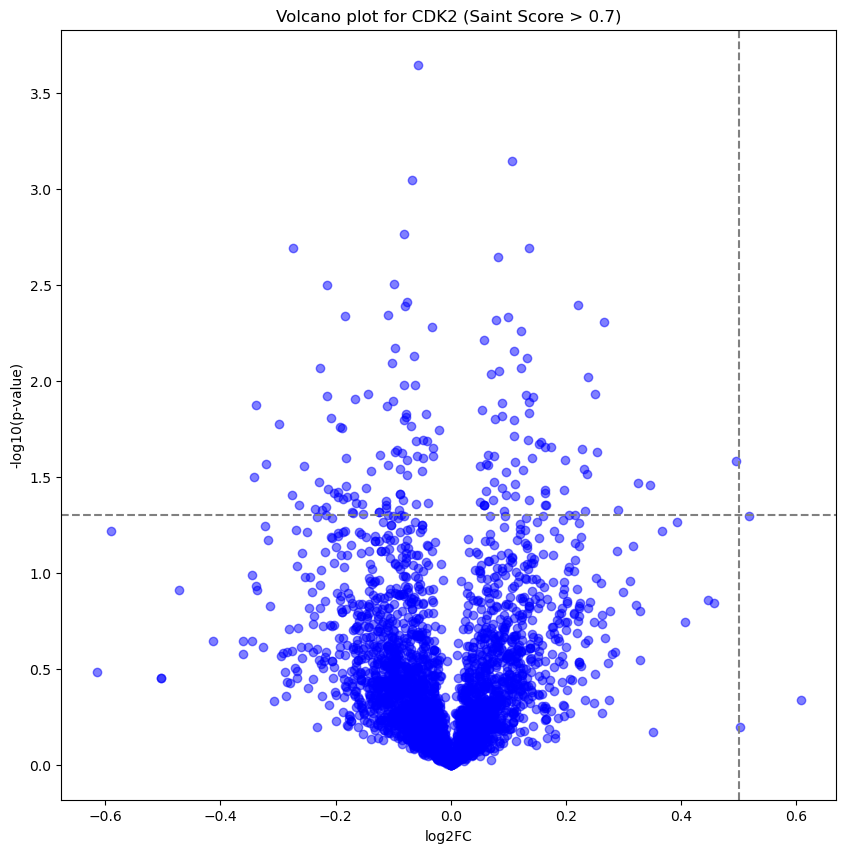

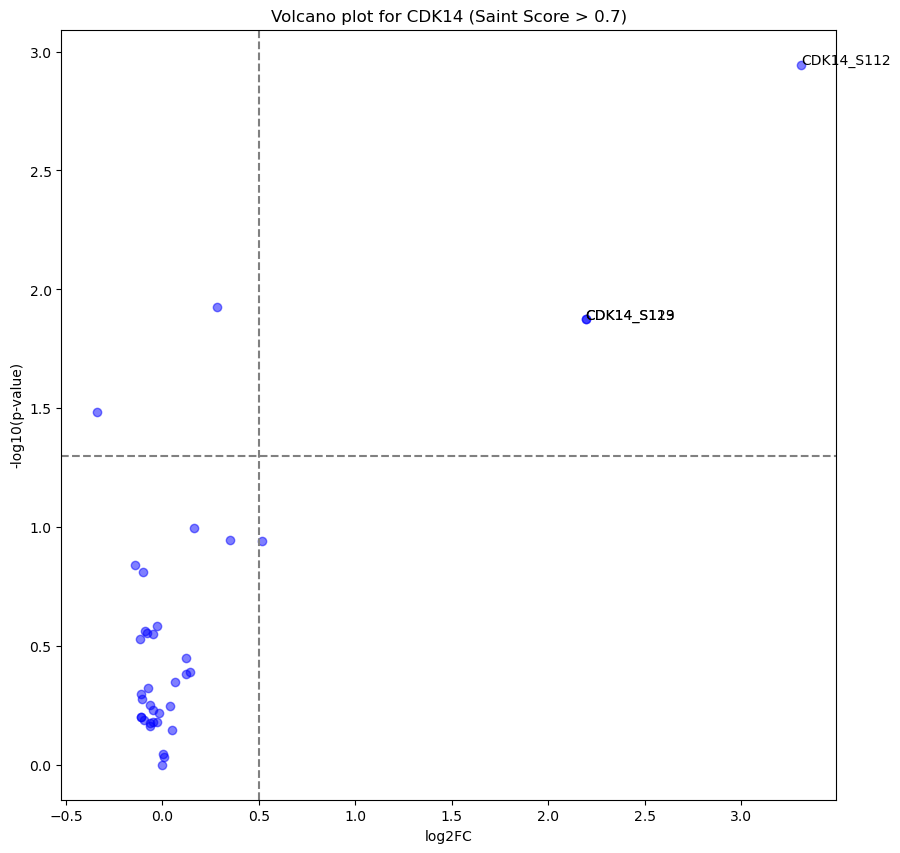

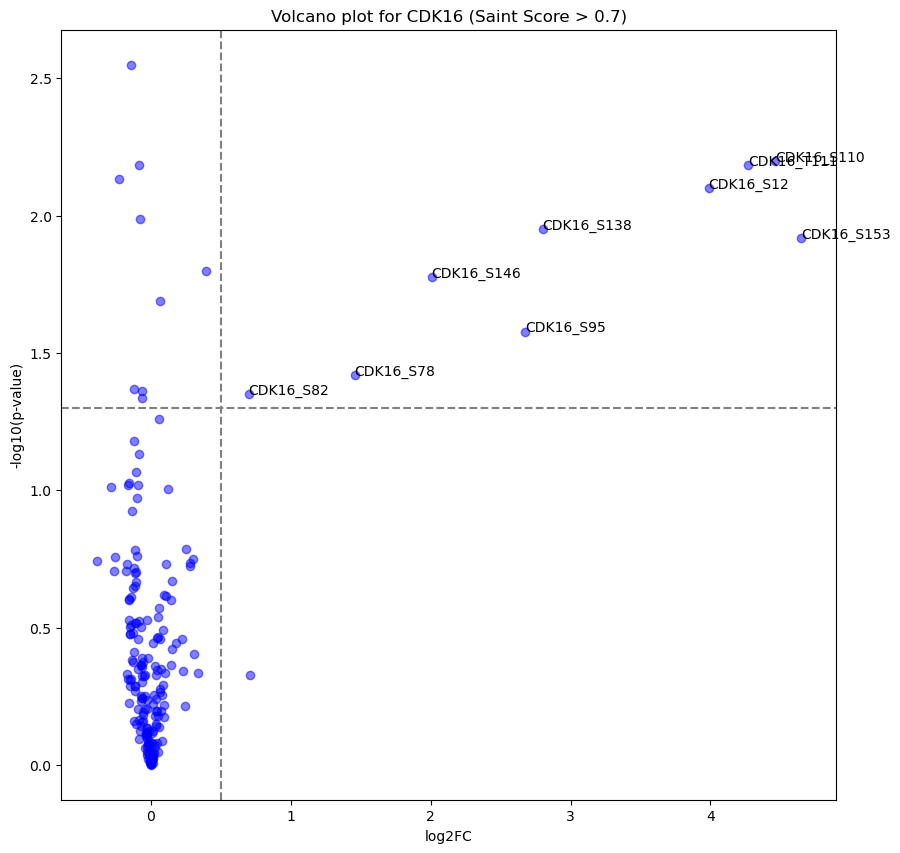

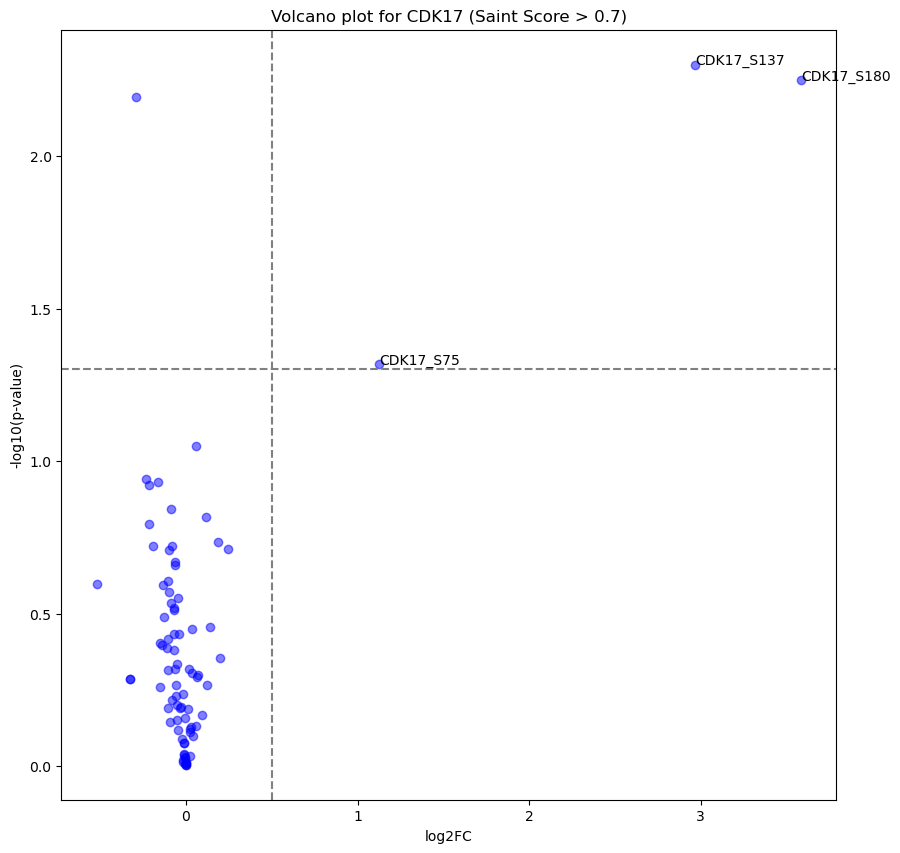

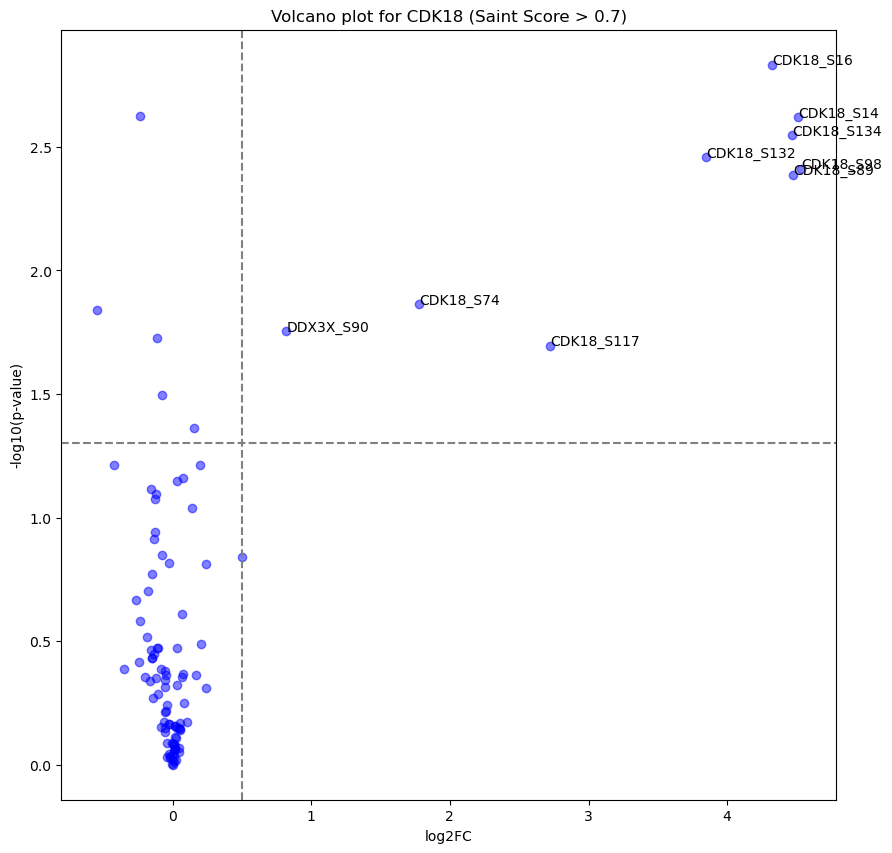

In [44]:
import matplotlib.pyplot as plt

# Set the saint score threshold
saint_score_threshold = 0.7

# Iterate over each comparison in the comparisons dictionary
for key in comparisons.keys():
    # Filter the combined_zscore_with_fc dataframe based on the saint score threshold
    filtered_df = combined_zscore_with_fc[combined_zscore_with_fc['SaintScore_' + key] > saint_score_threshold]
    
    # Create a volcano plot for the filtered data
    fig, ax = plt.subplots(figsize=(10, 10))
    scatter = ax.scatter(filtered_df['log2FC_' + key], -np.log10(filtered_df['pval_' + key]), c='blue', alpha=0.5)
    
    # Add a line for a significance threshold
    ax.axhline(y=-np.log10(0.05), color='grey', linestyle='--')

    # Add a line for the log2FC threshold
    ax.axvline(x=0.5, color='grey', linestyle='--')

    # Add text annotations for all points that are significant and have a log2FC greater than 0.5
    for i, txt in enumerate(filtered_df.index):
        if filtered_df['pval_' + key][i] < 0.05 and filtered_df['log2FC_' + key][i] > 0.5:
            ax.annotate(txt, (filtered_df['log2FC_' + key][i], -np.log10(filtered_df['pval_' + key][i])))

    
    ax.set_xlabel('log2FC')
    ax.set_ylabel('-log10(p-value)')
    ax.set_title('Volcano plot for ' + key + ' (Saint Score > ' + str(saint_score_threshold) + ')')
    
    # fig.savefig(output_folder_path + key + '_volcano_filtered.png')


In [145]:
# Make a GCT file for CDK17 signed pvals
acc = []
signed_pvals = []
for i in range(len(combined_zscore_with_fc)):
    first_protein = combined_zscore_with_fc['Proteins'][i].split(';')[0]
    first_resnum = combined_zscore_with_fc['Positions within proteins'][i].split(';')[0]
    first_res = combined_zscore_with_fc['Amino acid'][i]
    acc.append(first_protein + ';' + first_res + first_resnum + '-p')
    pval = combined_zscore_with_fc['pval_CDK18'][i]
    logfc = combined_zscore_with_fc['log2FC_CDK18'][i]
    if logfc < 0:
        pval = -1*pval
    else:
        pval = pval
    signed_pvals.append(pval)

# Make a dataframe from the acc and signed_pvals lists
df = pd.DataFrame({'id':acc,'PValue':signed_pvals})

# Write the dataframe to a gct file using tabs as the delimiter
df.to_csv(output_folder_path + 'CDK18_pvals.gct', sep='\t', index=False)

# Print the length of the dataframe
print('Length of dataframe: ' + str(len(df)))

Length of dataframe: 8804


C:\Users\plutzer\AppData\Local\Temp\ipykernel_20708\2055869332.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gct_filtered.sort_values(by='PValue', inplace=True)


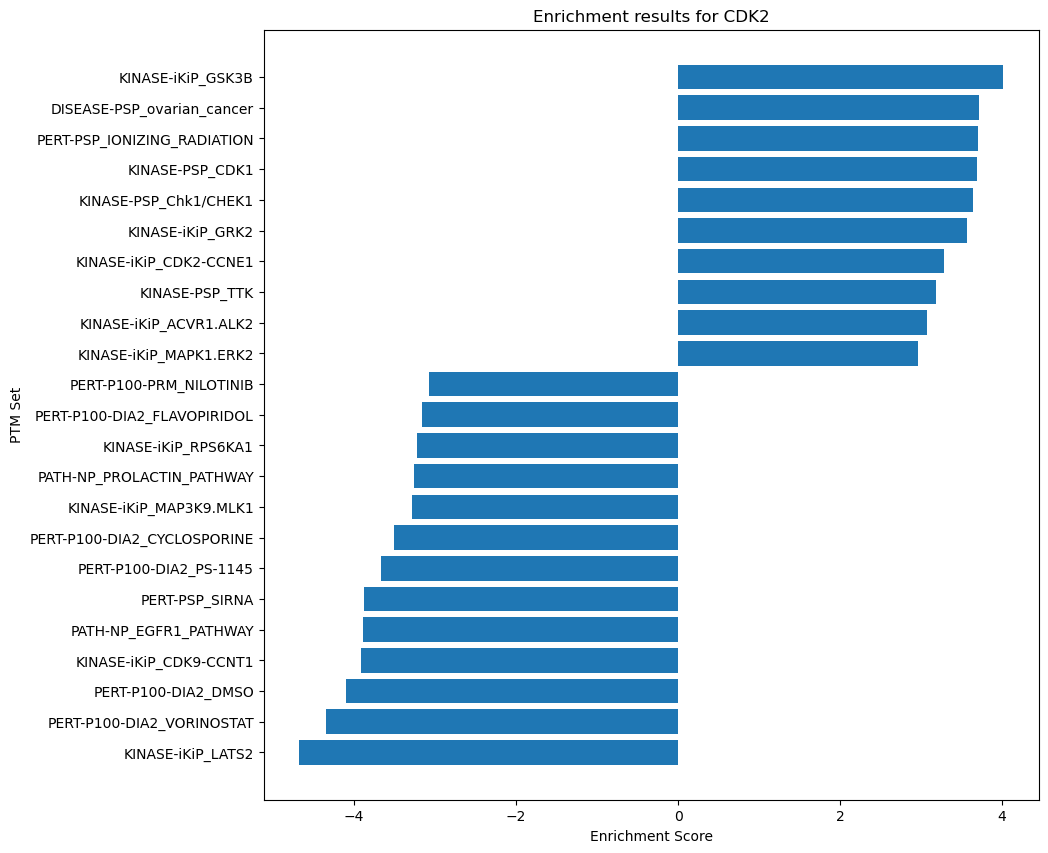

In [165]:
# Make a bar graph of the enrichment results

filename = output_folder_path + 'PTM-SEA/CDK2-combined.gct'

# Read in the gct file
gct = pd.read_csv(filename, sep='\t', skiprows=2)

# Filter the gct to only inlcude fdr less than 0.25
gct_filtered = gct[gct['fdr.pvalue.PValue'] < 0.15]

# Sort the gct_filtered by the enrichment score
gct_filtered.sort_values(by='PValue', inplace=True)

# Plot the bar graph
fig, ax = plt.subplots(figsize=(10,10))
ax.barh(gct_filtered['id'], gct_filtered['PValue'])

# Add a title and axis labels
ax.set_title('Enrichment results for CDK2')
ax.set_xlabel('Enrichment Score')
ax.set_ylabel('PTM Set')

# Save the figure
fig.savefig(output_folder_path + 'CDK2_enrichment_graph.png')

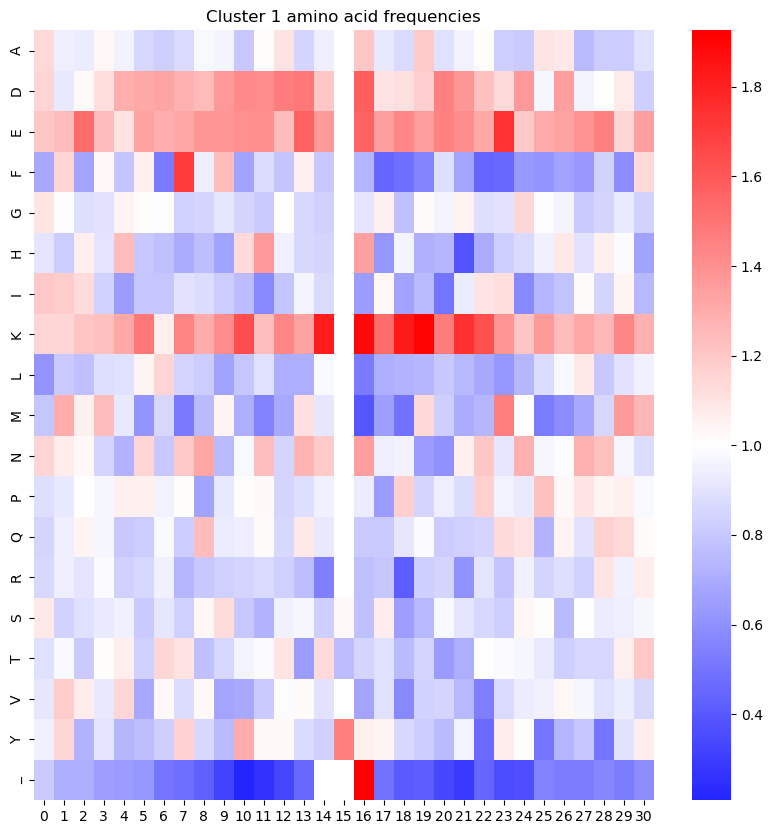

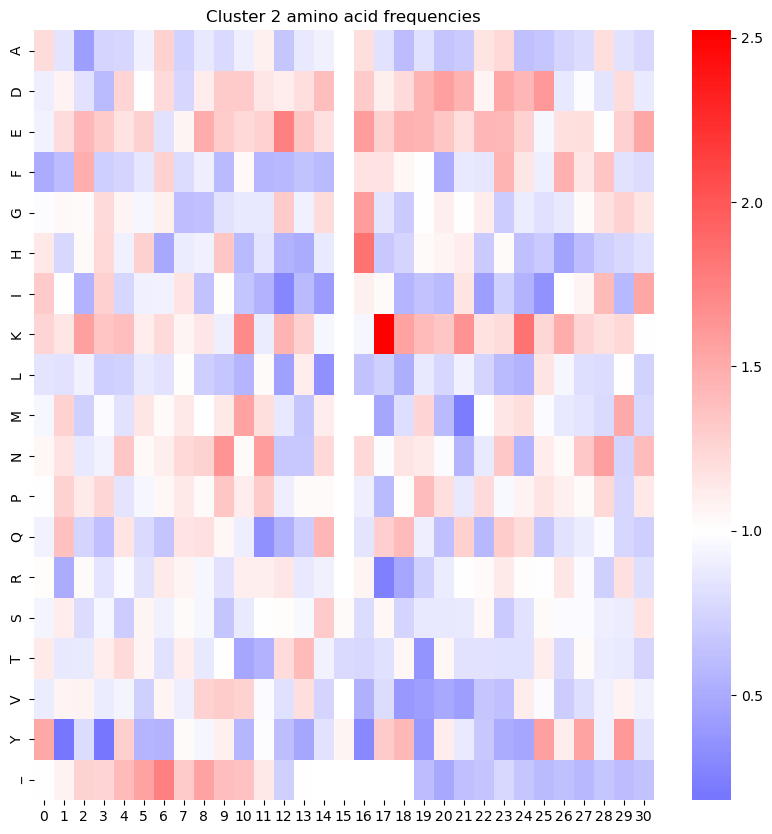

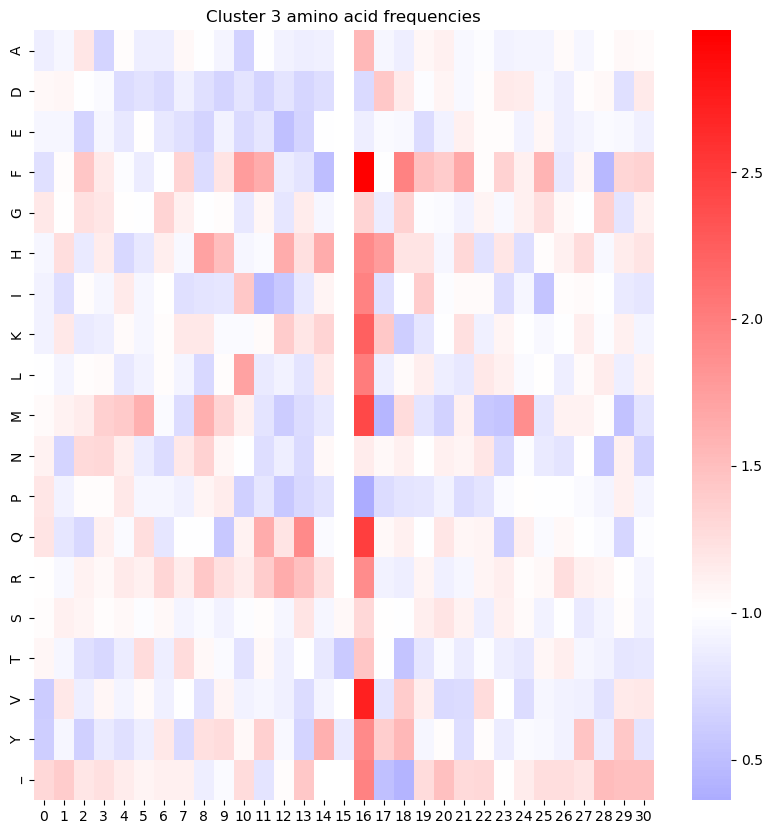

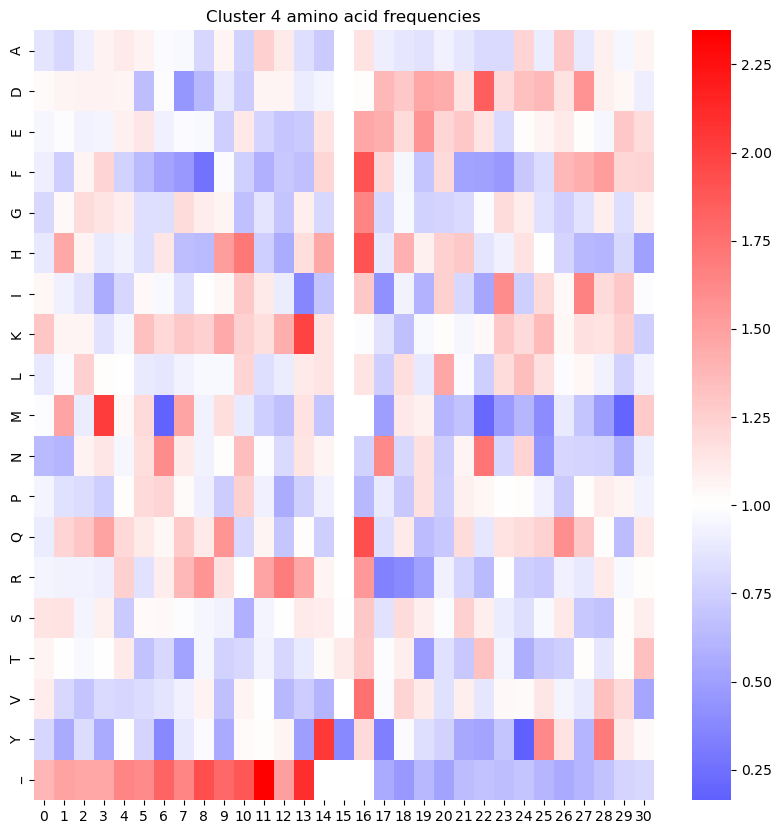

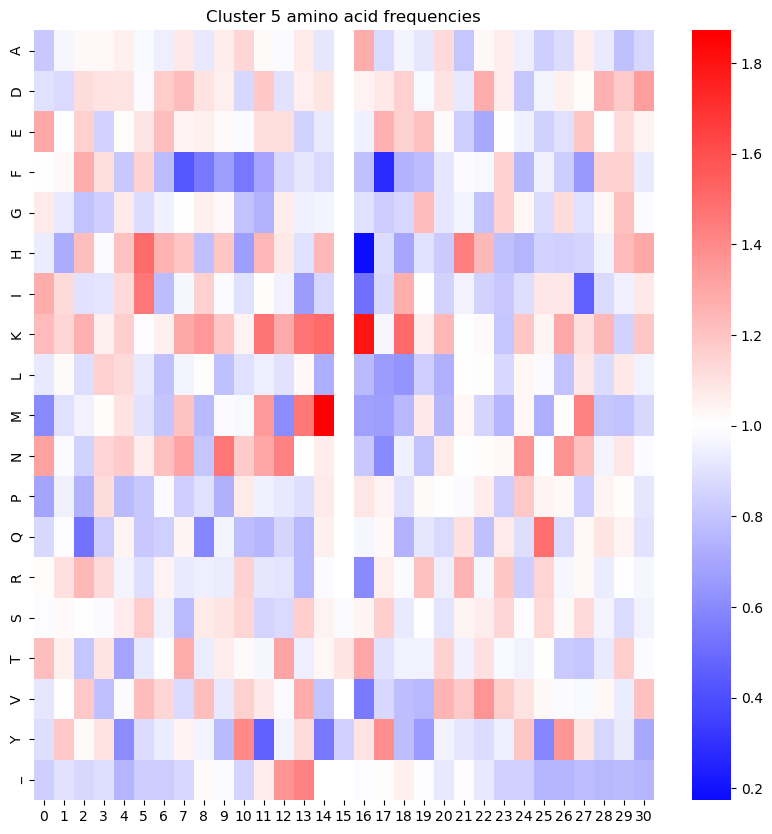

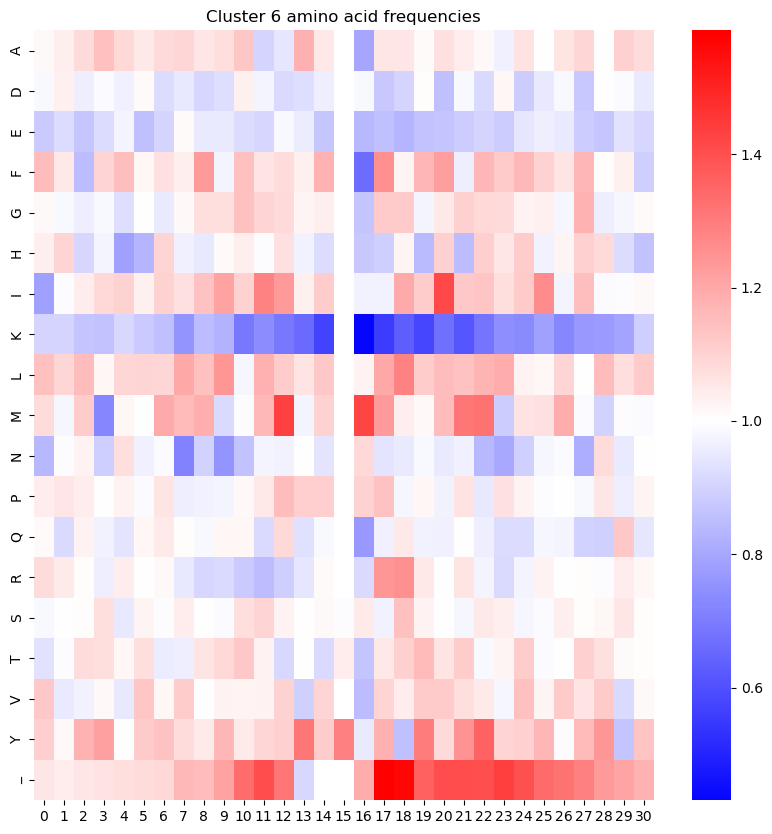

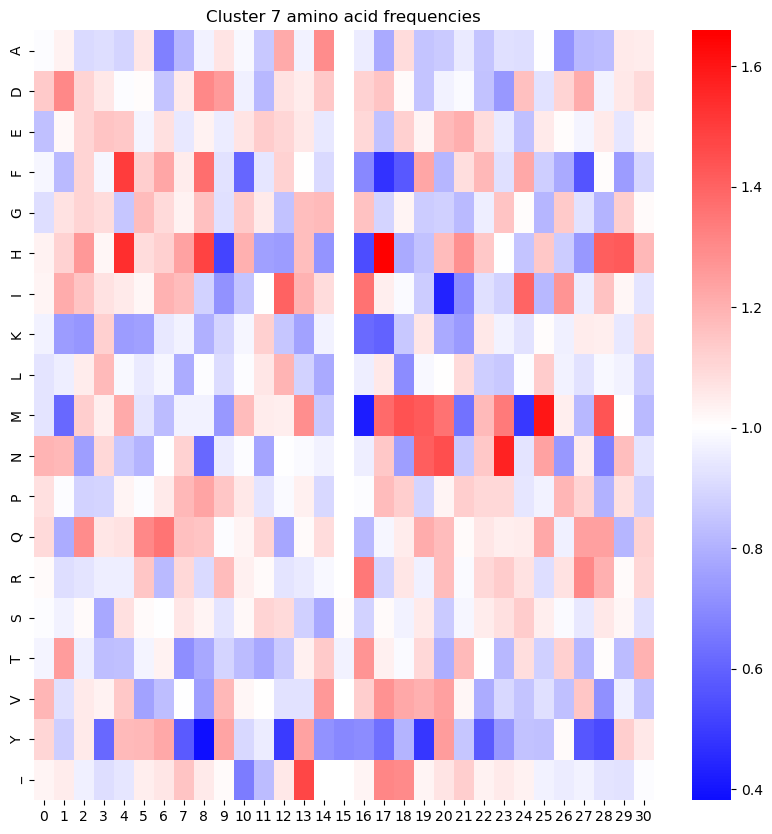

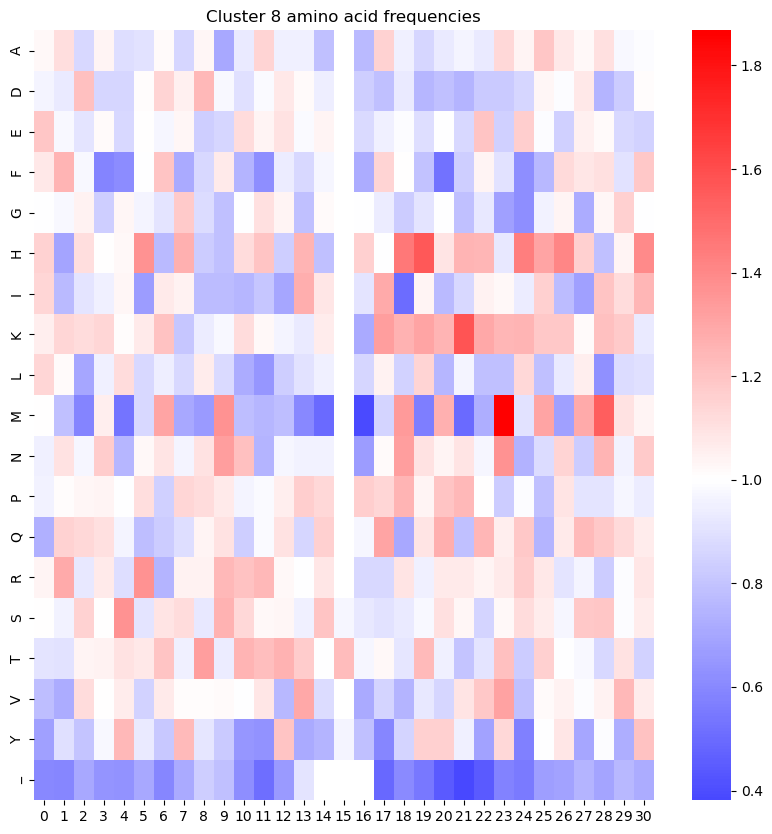

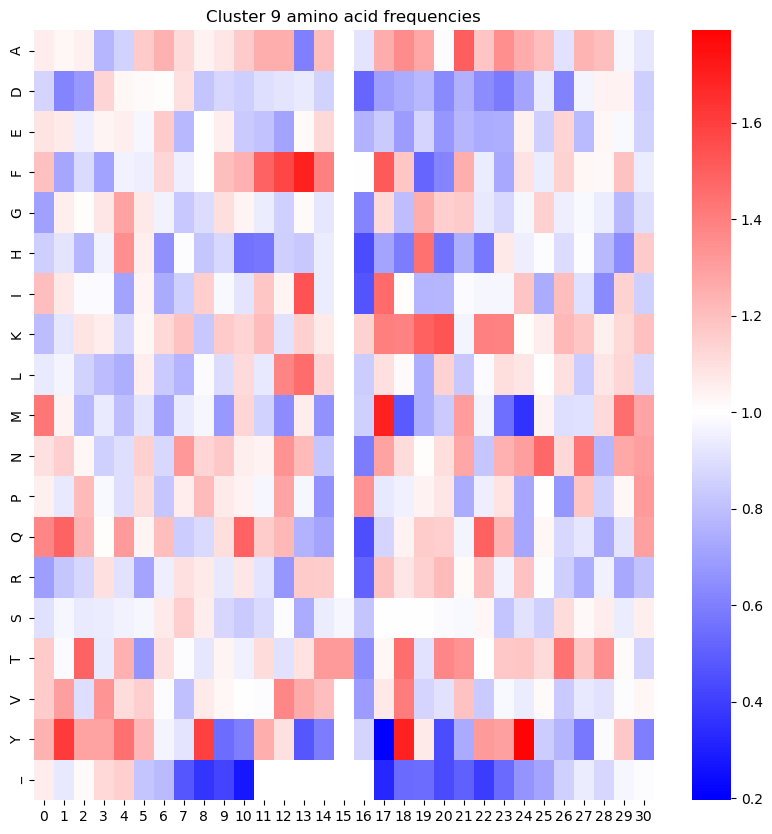

In [129]:
# Derive a consensus matrix for all clusters
sequences = combined_zscore_with_fc['Sequence window']
sequences = [sequence.split(';')[0] for sequence in sequences]
sequences = np.array([list(sequence) for sequence in sequences])
counts = pd.DataFrame(sequences).apply(pd.Series.value_counts)
# Save the counts to a csv file
counts.to_csv(output_folder_path + 'consensus_aa_counts.csv')
consensus = counts / counts.sum()
# Remove C and W from the consensus
consensus = consensus.drop(['C','W'])

# Iterate over each cluster
for cluster in clusters:
    # Filter the combined_zscore_with_fc dataframe to only include the current cluster
    cluster_df = combined_zscore_with_fc[combined_zscore_with_fc['cluster'] == cluster]
    # Get the Sequence window column from the cluster_df
    sequences = cluster_df['Sequence window']
    # Take the first sequence delimited by a semicolon
    sequences = [sequence.split(';')[0] for sequence in sequences]

    # Split the sequences into a matrix where each letter is its own column
    sequences = np.array([list(sequence) for sequence in sequences])

    # Get the counts of each amino acid at each position
    counts = pd.DataFrame(sequences).apply(pd.Series.value_counts)
    # Save the counts to a csv file
    counts.to_csv(output_folder_path + 'cluster_' + str(cluster) + '_aa_counts.csv')

    # Normalize the counts by the total of each column
    counts = counts / counts.sum()

    # Remove rows that have index C or W
    counts = counts.drop(['C','W'])

    # Normalize the counts by the consensus
    counts = counts / consensus

    # display the counts as a heatmap
    plt.figure(figsize=(10,10))
    sns.heatmap(counts, cmap='bwr', center=1)
    plt.title('Cluster ' + str(cluster) + ' amino acid frequencies')
    plt.savefig(output_folder_path + 'cluster_' + str(cluster) + '_aa_freqs.png')


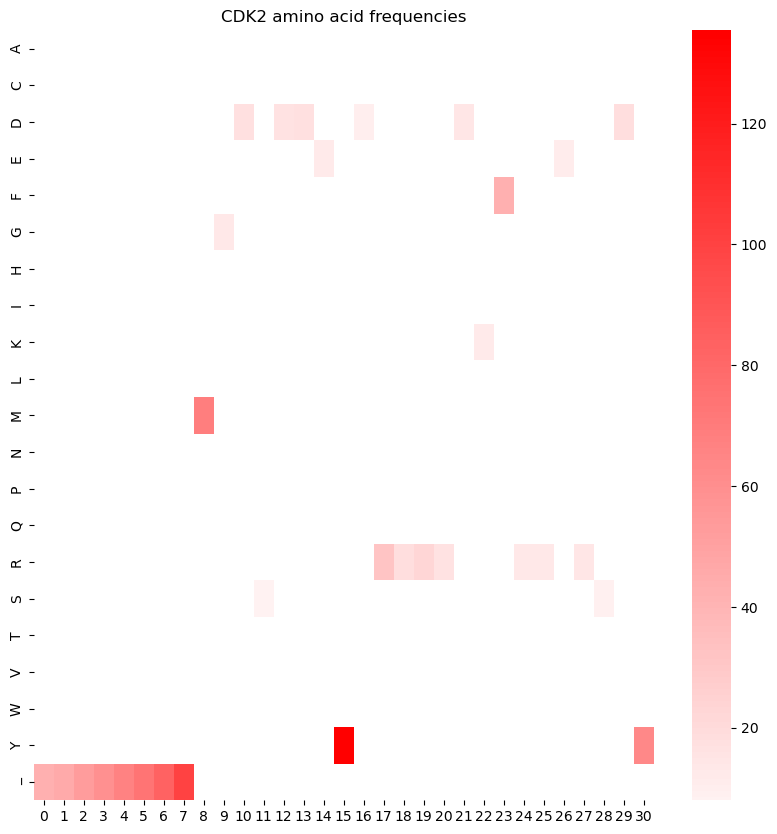

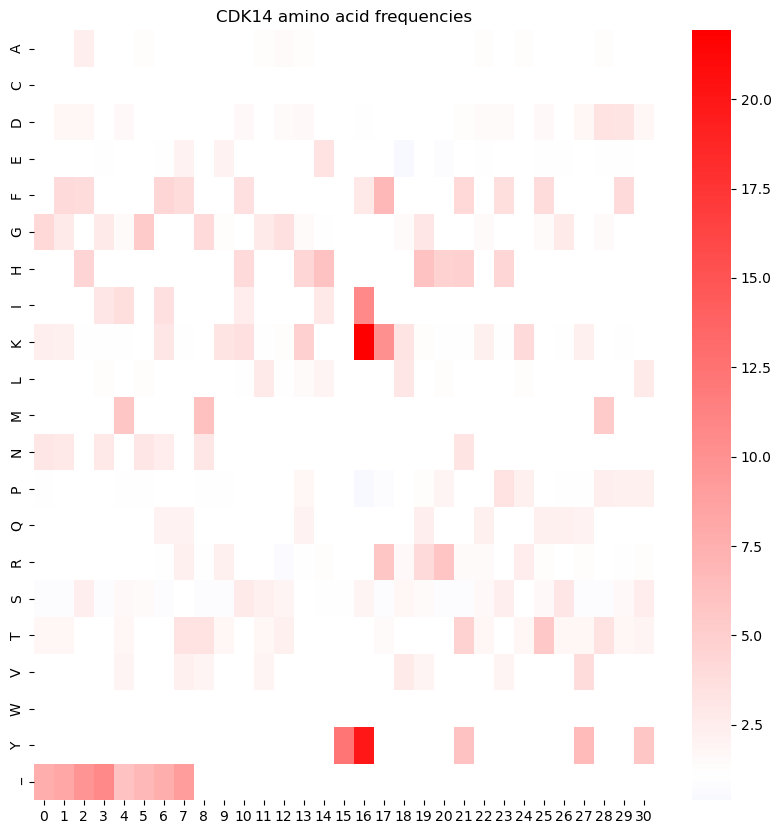

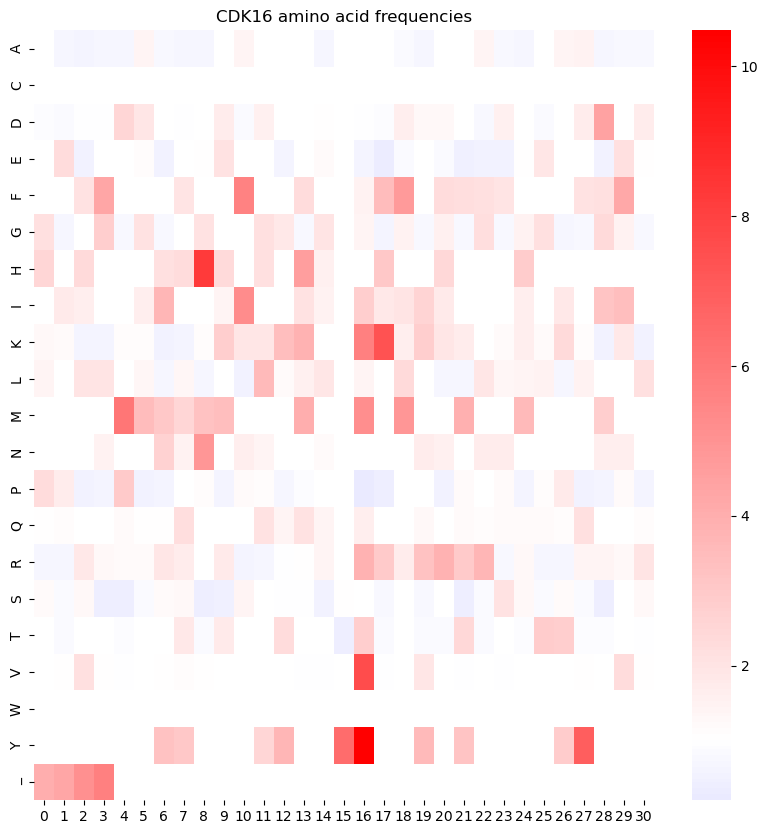

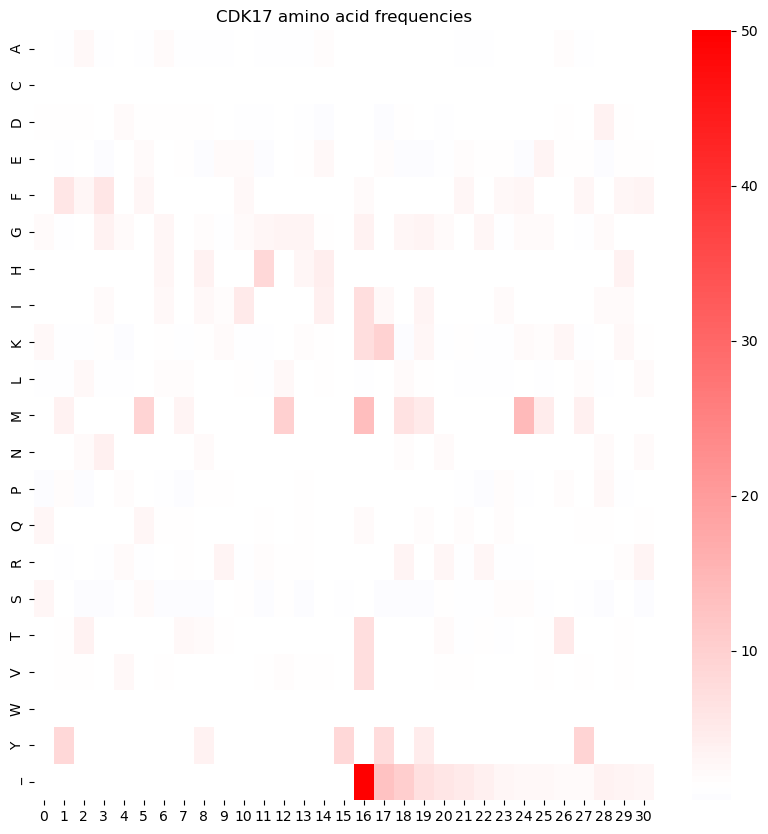

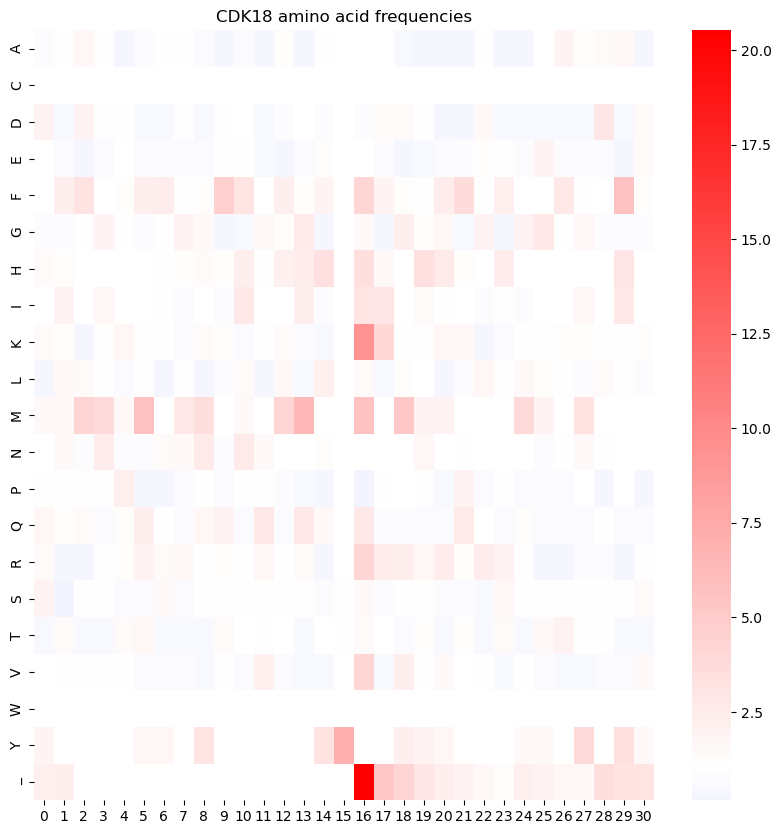

In [117]:
# Set the log2FC and p-value cutoffs
log2fc_cutoff = 0.75
pvalue_cutoff = 0.05

# Iterate over each comparison in the comparisons dictionary
for key in comparisons.keys():
    # Filter the combined_zscore_with_fc dataframe based on the log2FC and p-value cutoffs
    filtered_df = combined_zscore_with_fc[(combined_zscore_with_fc['log2FC_' + key] > log2fc_cutoff) &
                                          (combined_zscore_with_fc['pval_' + key] < pvalue_cutoff)]
    
    # Get the Sequence window column from the cluster_df
    sequences = filtered_df['Sequence window']
    # Take the first sequence delimited by a semicolon
    sequences = [sequence.split(';')[0] for sequence in sequences]

    # Split the sequences into a matrix where each letter is its own column
    sequences = np.array([list(sequence) for sequence in sequences])

    # Get the counts of each amino acid at each position
    counts = pd.DataFrame(sequences).apply(pd.Series.value_counts)

    # Normalize the counts by the total of each column
    counts = counts / counts.sum()

    # Remove rows that have index C or W
    counts = counts[counts.index != 'C']
    counts = counts[counts.index != 'W']

    # Normalize the counts by the consensus
    counts = counts / consensus

    # display the counts as a heatmap
    plt.figure(figsize=(10,10))
    sns.heatmap(counts, cmap='bwr', center=1)
    plt.title(key + ' amino acid frequencies')
    plt.savefig(output_folder_path + key + '_aa_freqs.png')

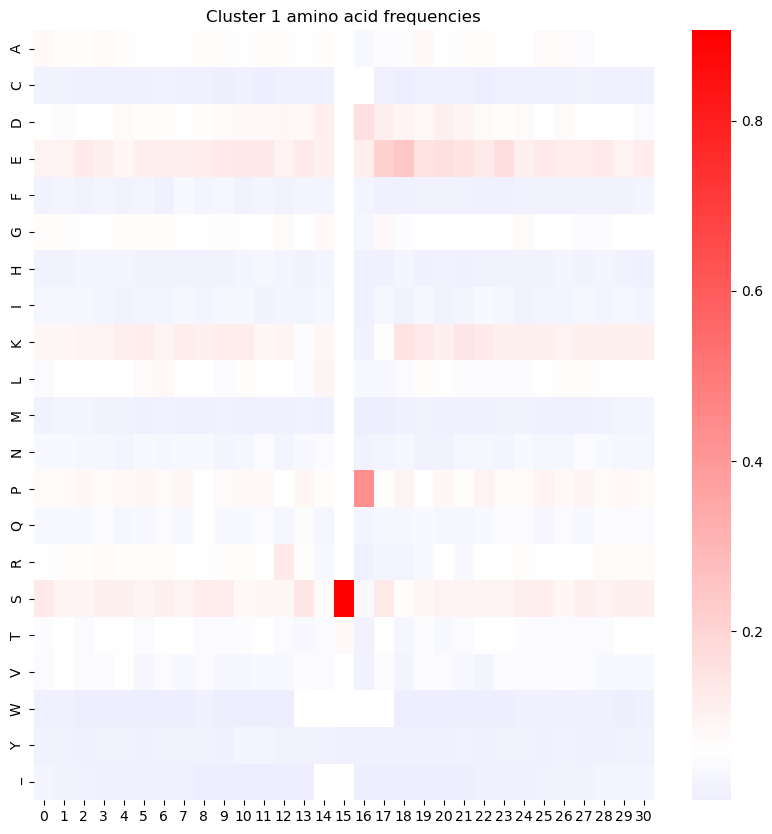

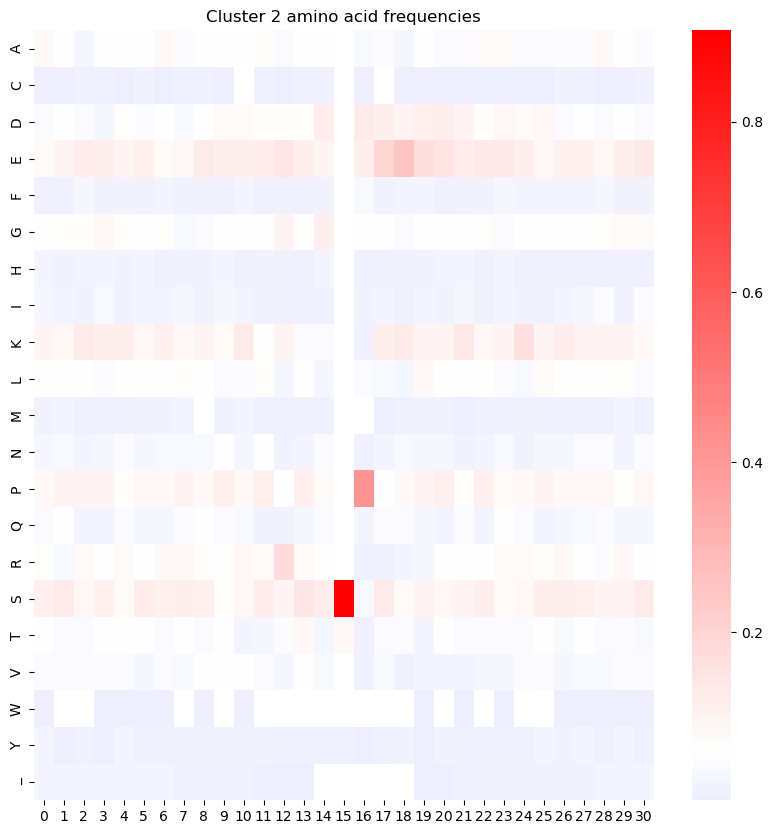

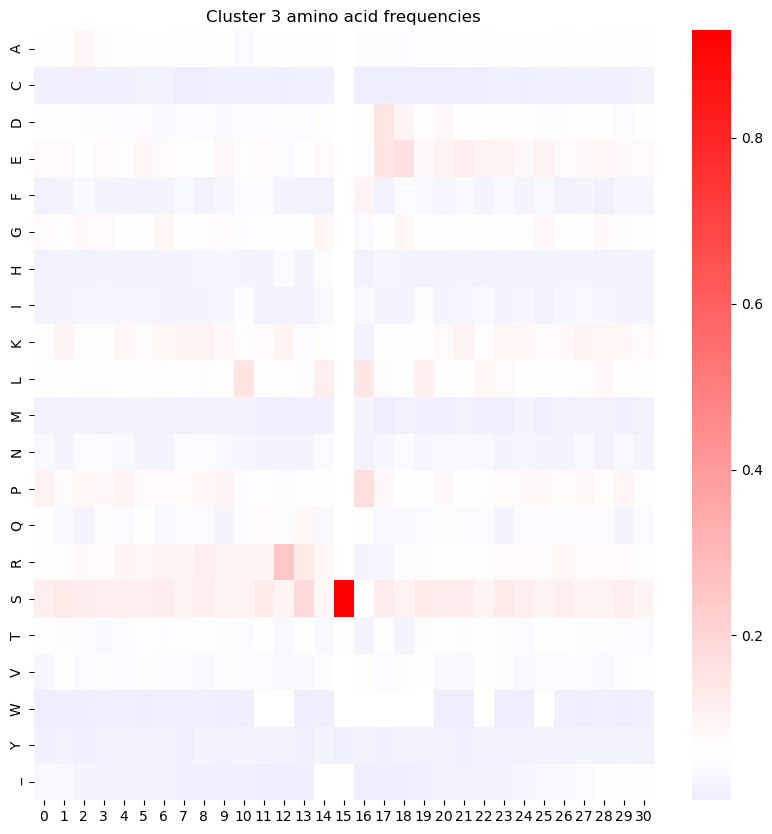

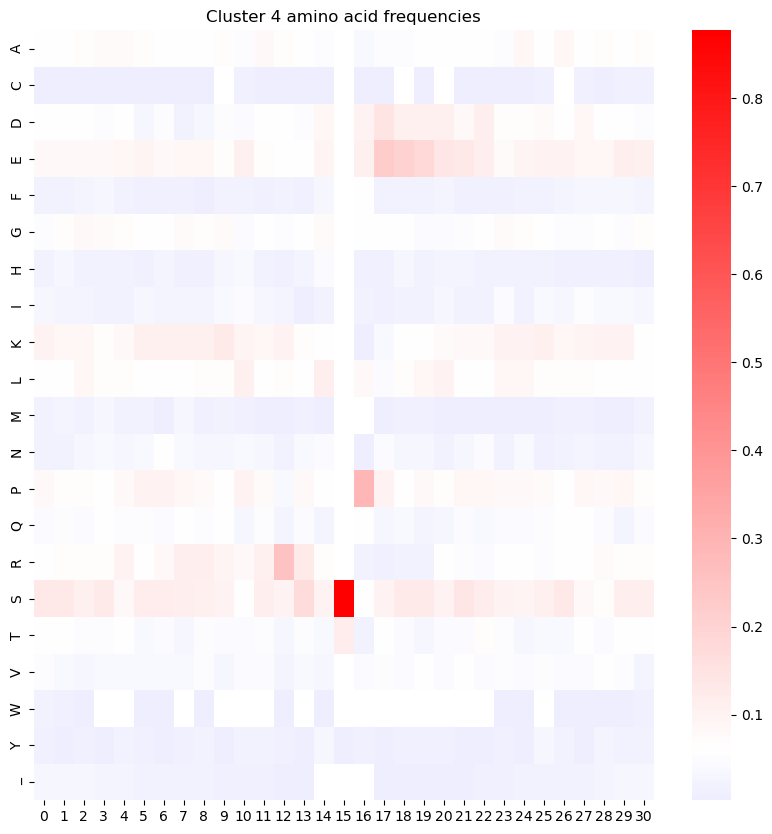

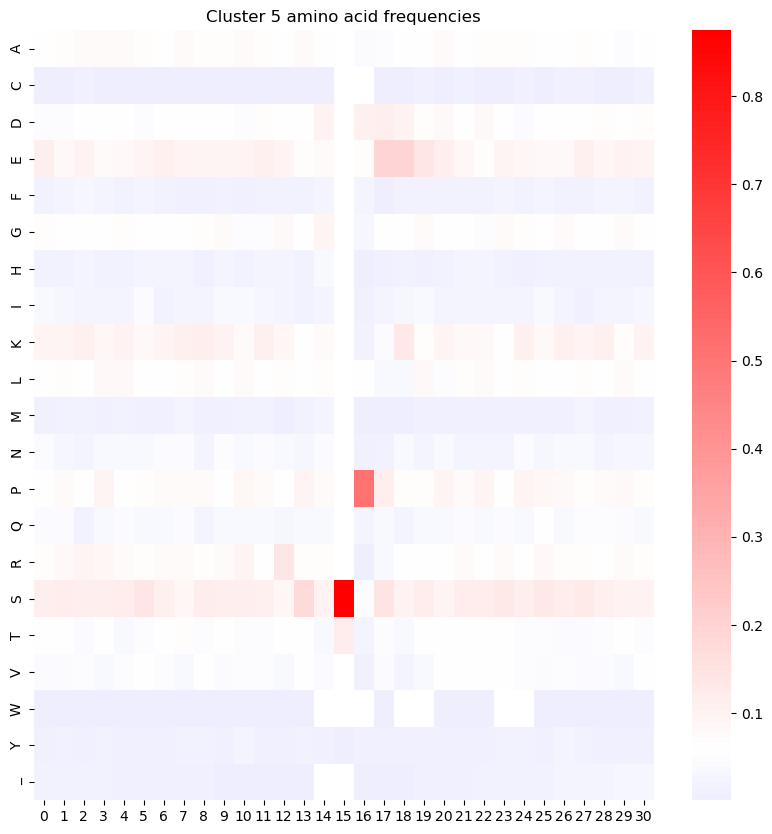

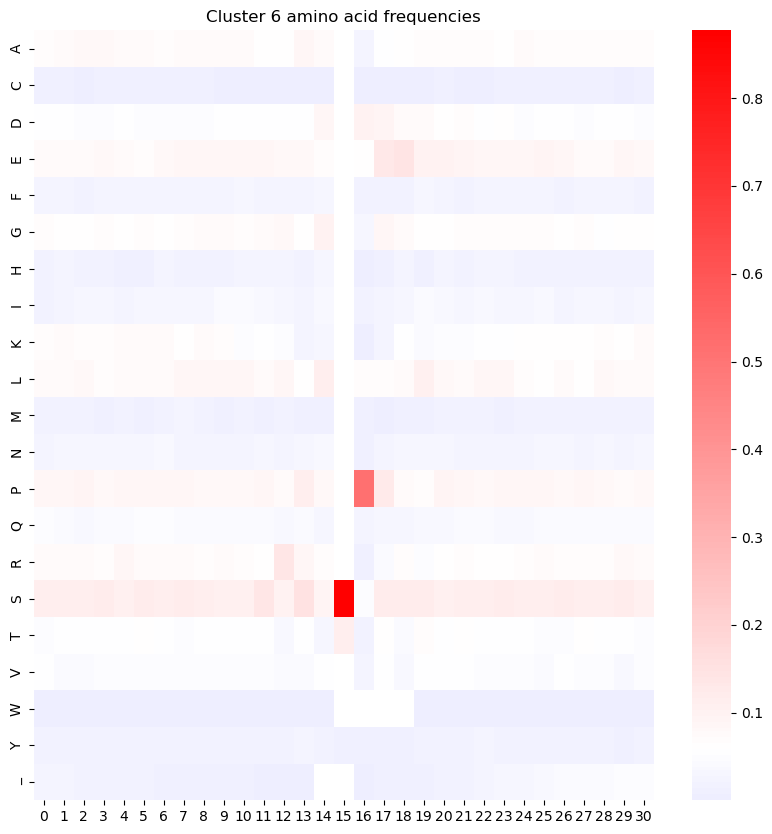

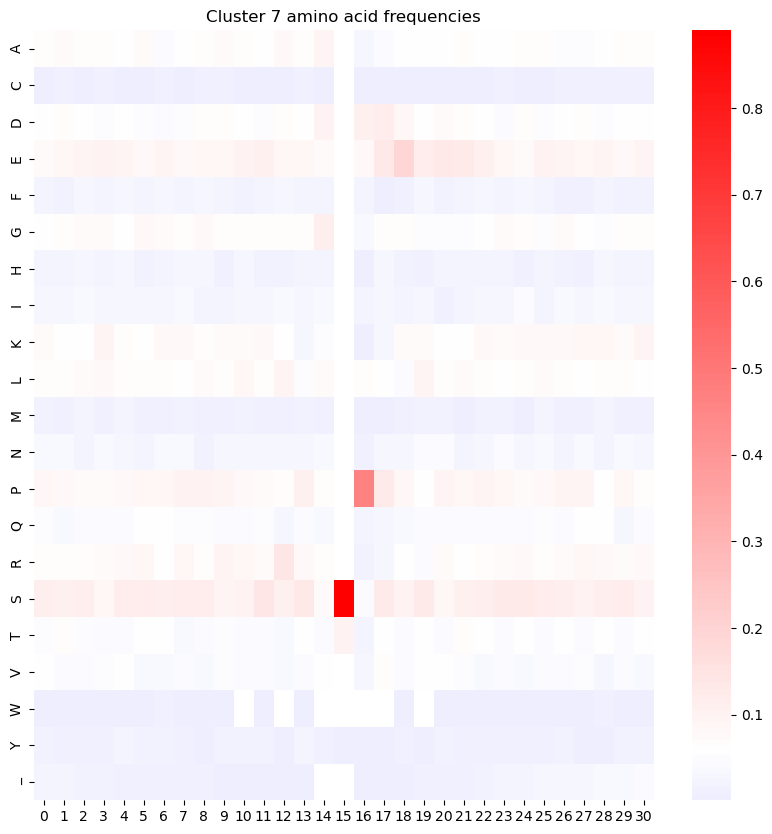

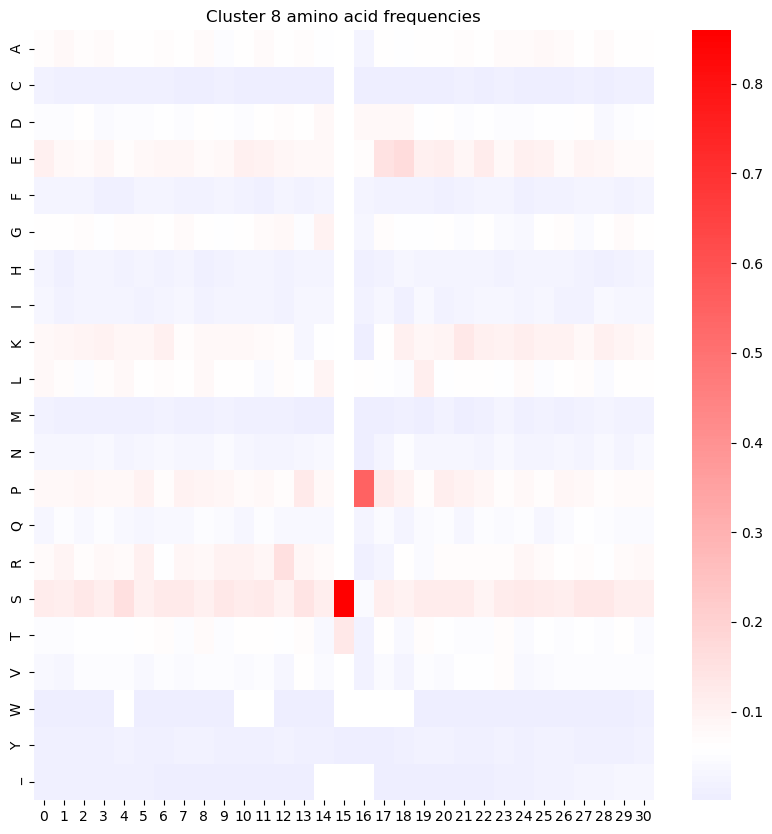

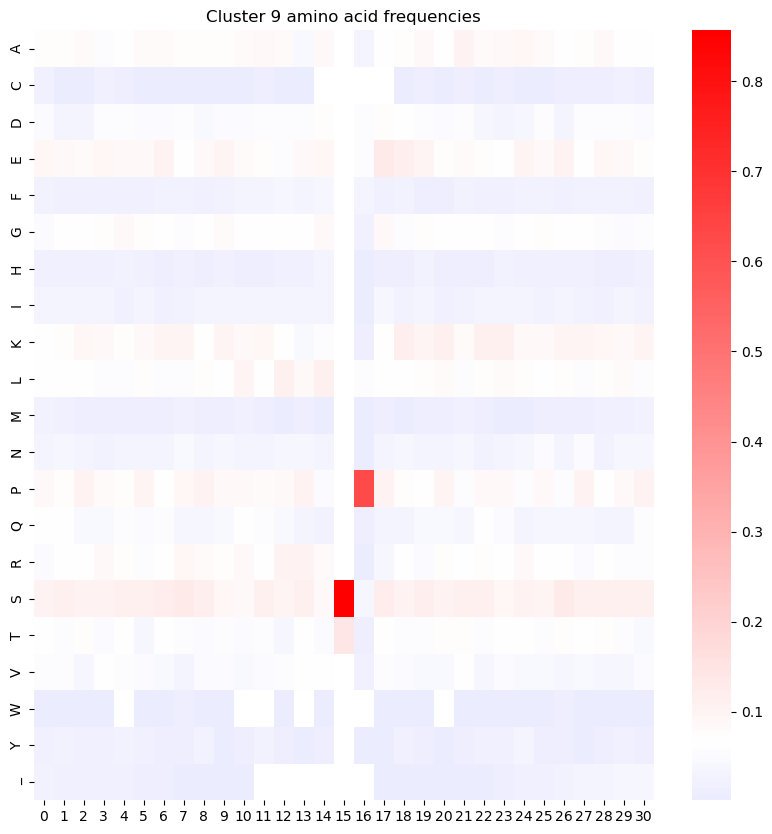

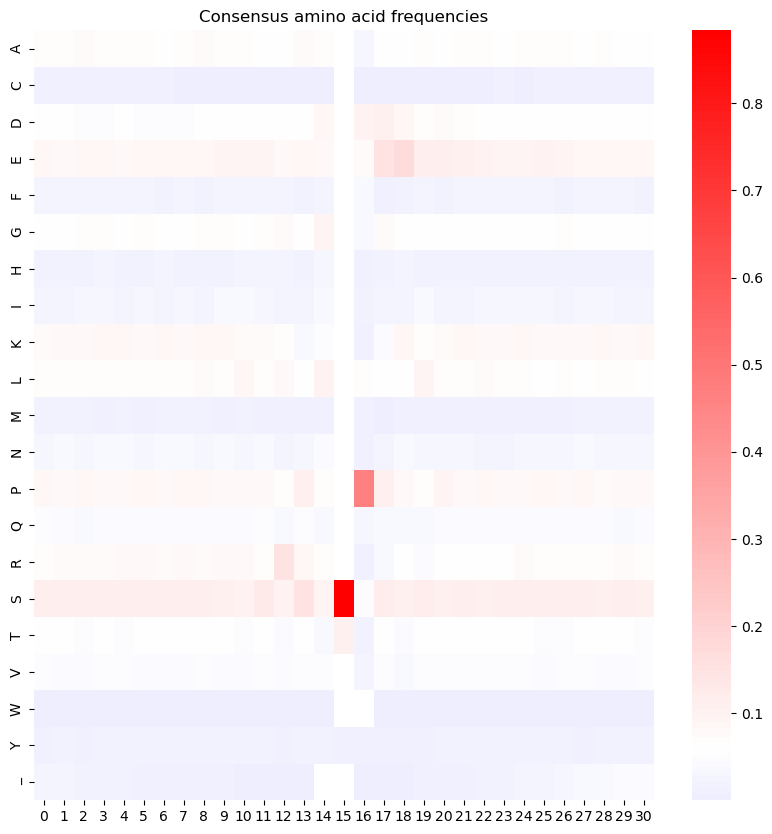

In [101]:
# Derive a consensus matrix for all clusters
sequences = combined_zscore_with_fc['Sequence window']
sequences = [sequence.split(';')[0] for sequence in sequences]
sequences = np.array([list(sequence) for sequence in sequences])
counts = pd.DataFrame(sequences).apply(pd.Series.value_counts)
consensus = counts / counts.sum()

# Iterate over each cluster
for cluster in clusters:
    # Filter the combined_zscore_with_fc dataframe to only include the current cluster
    cluster_df = combined_zscore_with_fc[combined_zscore_with_fc['cluster'] == cluster]
    # Get the Sequence window column from the cluster_df
    sequences = cluster_df['Sequence window']
    # Take the first sequence delimited by a semicolon
    sequences = [sequence.split(';')[0] for sequence in sequences]

    # Split the sequences into a matrix where each letter is its own column
    sequences = np.array([list(sequence) for sequence in sequences])

    # Get the counts of each amino acid at each position
    counts = pd.DataFrame(sequences).apply(pd.Series.value_counts)

    # Normalize the counts by the total of each column
    counts = counts / counts.sum()

    # display the counts as a heatmap
    plt.figure(figsize=(10,10))
    sns.heatmap(counts, cmap='bwr', center=counts.mean().mean())
    plt.title('Cluster ' + str(cluster) + ' amino acid frequencies')
    plt.savefig(output_folder_path + 'cluster_' + str(cluster) + '_aa_raw_freqs.png')

# Display the consensus
plt.figure(figsize=(10,10))
sns.heatmap(consensus, cmap='bwr', center=consensus.mean().mean())
plt.title('Consensus amino acid frequencies')
plt.savefig(output_folder_path + 'consensus_aa_raw_freqs.png')


In [68]:
# Read in the protein data

pg_path = txt_path + 'proteinGroups.txt'

pg = pd.read_csv(pg_path, sep='\t')

# Rename the columns using the column_mapping dict
pg.rename(columns=columns_mapping, inplace=True)

print(list(pg.columns))

['Protein IDs', 'Majority protein IDs', 'Peptide counts (all)', 'Peptide counts (razor+unique)', 'Peptide counts (unique)', 'Protein names', 'Gene names', 'Fasta headers', 'Number of proteins', 'Peptides', 'Razor + unique peptides', 'Unique peptides', 'Peptides CDKs', 'Razor + unique peptides CDKs', 'Unique peptides CDKs', 'Sequence coverage [%]', 'Unique + razor sequence coverage [%]', 'Unique sequence coverage [%]', 'Mol. weight [kDa]', 'Sequence length', 'Sequence lengths', 'Fraction average', 'Fraction 0', 'Fraction 1', 'Fraction 2', 'Fraction 3', 'Fraction 4', 'Fraction 5', 'Fraction 6', 'Fraction 7', 'Fraction 8', 'Fraction 9', 'Fraction 10', 'Fraction 11', 'Fraction 12', 'Fraction 13', 'Fraction 14', 'Fraction 15', 'Fraction 16', 'Fraction 17', 'Fraction 18', 'Fraction 19', 'Fraction 20', 'Fraction 21', 'Fraction 22', 'Fraction 23', 'Fraction 24', 'Fraction 100', 'Fraction 101', 'Fraction 102', 'Fraction 103', 'Fraction 104', 'Fraction 105', 'Fraction 106', 'Fraction 107', 'Frac

C:\Users\plutzer\AppData\Local\Temp\ipykernel_20708\810727321.py:5: DtypeWarning: Columns (122) have mixed types. Specify dtype option on import or set low_memory=False.
  pg = pd.read_csv(pg_path, sep='\t')


In [70]:
pg_quant = pg.copy()

# Perform the mixing correction using the correct_mixing function
pg_quant[quant_cols_order] = correct_mixing(pg_quant,quant_cols_order)

# Print the corrected pg dataframe
pg_quant


,Protein IDs,Majority protein IDs,Peptide counts (all),Peptide counts (razor+unique),Peptide counts (unique),Protein names,Gene names,Fasta headers,Number of proteins,Peptides,...,Mod. peptide IDs,Evidence IDs,MS/MS IDs,Best MS/MS,Oxidation (M) site IDs,Phospho (STY) site IDs,Oxidation (M) site positions,Phospho (STY) site positions,Taxonomy IDs,Taxonomy names
0,P0DPI2;A0A0B4J2D5,P0DPI2;A0A0B4J2D5,9;9,9;9,9;9,NaN,NaN,sp|P0DPI2|GAL3A_HUMAN Glutamine amidotransfera...,2,9,...,15265;20510;24932;28159;34384;49888;51814;7590...,27208;36313;36314;44280;44281;50353;50354;6186...,32823;43812;43813;53420;53421;53422;60815;6081...,32823;43812;53421;60815;74762;107578;111786;16...,0,NaN,243,NaN,-1;-1,;
1,P0DPI3;A0A0U1RRI6;A0A0U1RR11,P0DPI3;A0A0U1RRI6;A0A0U1RR11,1;1;1,1;1;1,1;1;1,NaN,NaN,sp|P0DPI3|CENL2_HUMAN Centromere protein V-lik...,3,1,...,28983,51842;51843,62621;62622;62623,62623,NaN,NaN,NaN,NaN,-1;-1;-1,;;
2,A0AV96,A0AV96,3,3,3,RNA-binding protein 47,RBM47,sp|A0AV96|RBM47_HUMAN RNA-binding protein 47 O...,1,3,...,13145;65234;65235;75185,23520;118002;118003;136239,28398;141540;141541;163599,28398;141541;163599,1,NaN,10,NaN,-1,NaN
3,A0AVF1,A0AVF1,7,7,7,Intraflagellar transport protein 56,TTC26,sp|A0AVF1|IFT56_HUMAN Intraflagellar transport...,1,7,...,782;9367;10588;24978;28393;52579;60160,1481;1482;16648;18876;18877;44349;50781;94047;...,1815;1816;1817;20170;22863;22864;53503;61317;1...,1815;20170;22864;53503;61317;113264;129707,NaN,NaN,NaN,NaN,-1,NaN
4,A0AVK6,A0AVK6,1,1,1,Transcription factor E2F8,E2F8,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,1,1,...,8665,15474;15475,18743;18744,18744,NaN,0,NaN,102,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7947,REV__Q9ULI3,REV__Q9ULI3,1,1,1,NaN,NaN,sp|Q9ULI3|HEG1_HUMAN Protein HEG homolog 1 OS=...,1,1,...,32525,58638,71000,71000,NaN,11789;11790;11791;11792;11793,NaN,804;805;806;807;812,-1,NaN
7948,REV__Q9UM44,REV__Q9UM44,1,1,1,NaN,NaN,sp|Q9UM44|HHLA2_HUMAN HERV-H LTR-associating p...,1,1,...,48000,86101,103648,103648,NaN,11794;14056,NaN,260;262,-1,NaN
7949,REV__Q9UPV0,REV__Q9UPV0,1,1,1,NaN,NaN,sp|Q9UPV0|CE164_HUMAN Centrosomal protein of 1...,1,1,...,593,1127,1374,1374,NaN,14057;14058,NaN,1126;1132,-1,NaN
7950,REV__Q9Y490,REV__Q9Y490,1,1,1,NaN,NaN,sp|Q9Y490|TLN1_HUMAN Talin-1 OS=Homo sapiens O...,1,1,...,43104,77413,93424,93424,NaN,NaN,NaN,NaN,-1,NaN


Text(0.5, 1.0, 'Boxplot of DDX3X protein intensities')

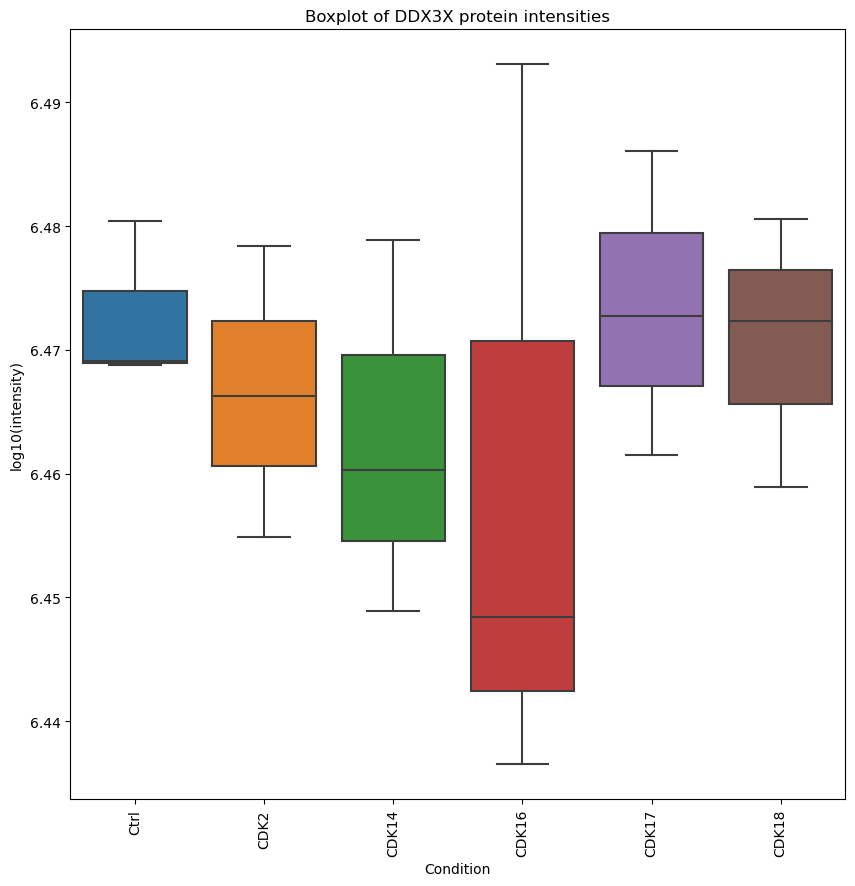

In [118]:
protein = 'DDX3X'

# filter the protein dataframe to only include the protein of interest
protein_df = pg_quant[pg_quant['Gene names'] == protein]

# For each condition, make a list of the values
conditions = ['Ctrl','CDK2','CDK14','CDK16','CDK17','CDK18']

data = {}

for condition in conditions:
    data[condition] = []
    columns = [col for col in protein_df.columns if col.startswith(condition)]
    data[condition].append(protein_df[columns].values[0])


# Create a dataframe from the data
boxplot_df = pd.DataFrame(data)

# Each element of theis dataframe is a list. Expand the lists into columns
boxplot_df = boxplot_df.apply(pd.Series.explode)

boxplot_df = np.log10(boxplot_df.astype(float) + 1)

# Now plot a bar graph of the data with error bars
plt.figure(figsize=(10,10))

sns.boxplot(data=boxplot_df)

plt.xticks(rotation=90)

plt.ylabel('log10(intensity)')
plt.xlabel('Condition')
plt.title('Boxplot of ' + protein + ' protein intensities')



C:\Users\plutzer\AppData\Local\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


Text(0.5, 1.0, 'Boxplot of phosphosite RB1_S795 protein intensities')

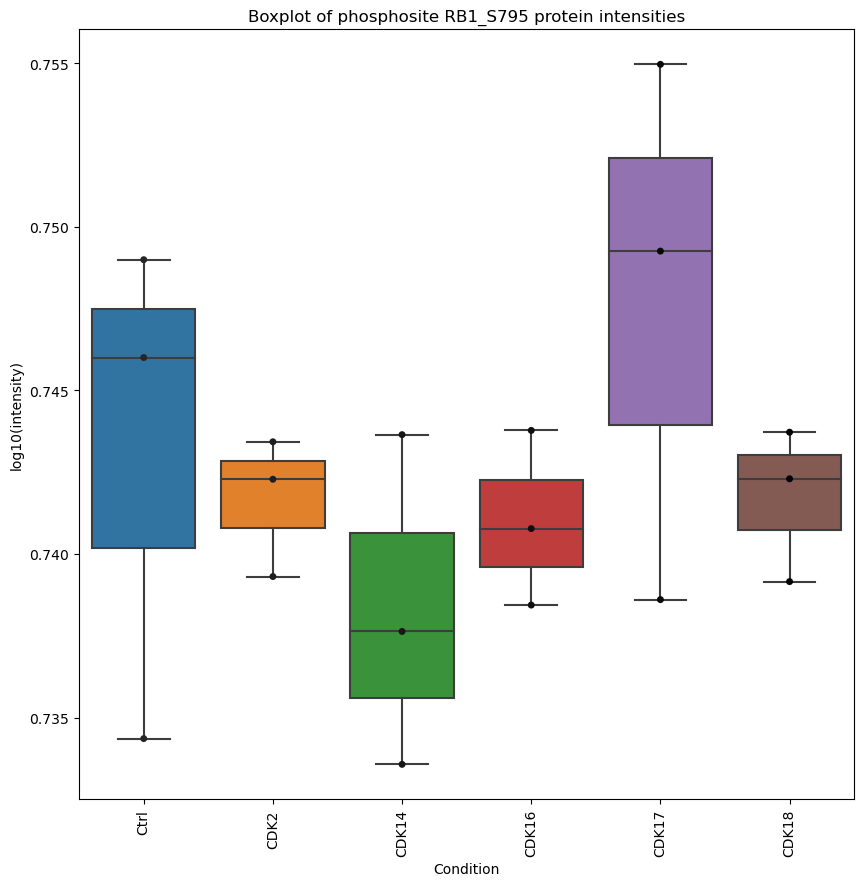

In [167]:
# Define the phosphosite index
phosphosite_index = 'RB1_S795'

# Filter the protein dataframe to only include the phosphosite of interest
phospho_df = combined_log.loc[combined_log.index == phosphosite_index]

# For each condition, make a list of the values
conditions = ['Ctrl','CDK2','CDK14','CDK16','CDK17','CDK18']

data = {}

for condition in conditions:
    data[condition] = []
    columns = [col for col in phospho_df.columns if col.startswith(condition)]
    data[condition].extend(phospho_df[columns].values.flatten())

# Create a dataframe from the data
boxplot_df = pd.DataFrame(data)

# Convert the elements in the dataframe to float
boxplot_df = boxplot_df.astype(float)

# Apply the log10 function to the dataframe
boxplot_df = np.log10(boxplot_df + 1)

# Now plot a bar graph of the data with error bars
plt.figure(figsize=(10,10))
sns.boxplot(data=boxplot_df)
plt.xticks(rotation=90)

# Add the individual data points to the boxplot
sns.swarmplot(data=boxplot_df, color='black')

plt.ylabel('log10(intensity)')
plt.xlabel('Condition')
plt.title('Boxplot of phosphosite ' + str(phosphosite_index) + ' protein intensities')


In [126]:
# Get the row in combined_log that has 'E2F8_S102' as the index
combined_log.loc[combined_log.index == 'E2F8_S102']


,Proteins,Positions within proteins,Leading proteins,Protein,Protein names,Gene names,Fasta headers,Localization prob,Score diff,PEP,...,CDK14 3,CDK16 1,CDK16 2,CDK16 3,CDK17 1,CDK17 2,CDK17 3,CDK18 1,CDK18 2,CDK18 3
index,,,,,,,,,,,,,,,,,,,,,
E2F8_S102,A0AVK6,102,A0AVK6,A0AVK6,Transcription factor E2F8,E2F8,sp|A0AVK6|E2F8_HUMAN Transcription factor E2F8...,1.0,109.793,0.000097,...,4.554602,4.594658,4.524125,4.587633,4.564426,4.563957,4.56588,4.622013,4.58627,4.573078


Text(0.5, 1.0, 'Boxplot of protein intensities in Cluster 6')

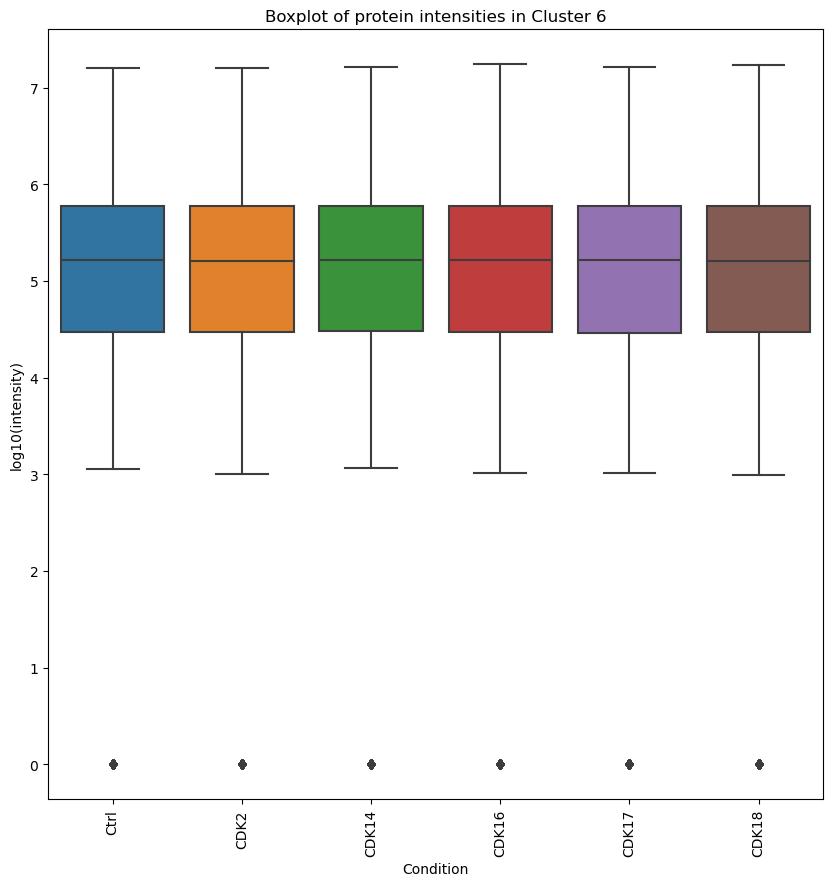

Text(0.5, 1.0, 'Enrichment Scores for CDK17')

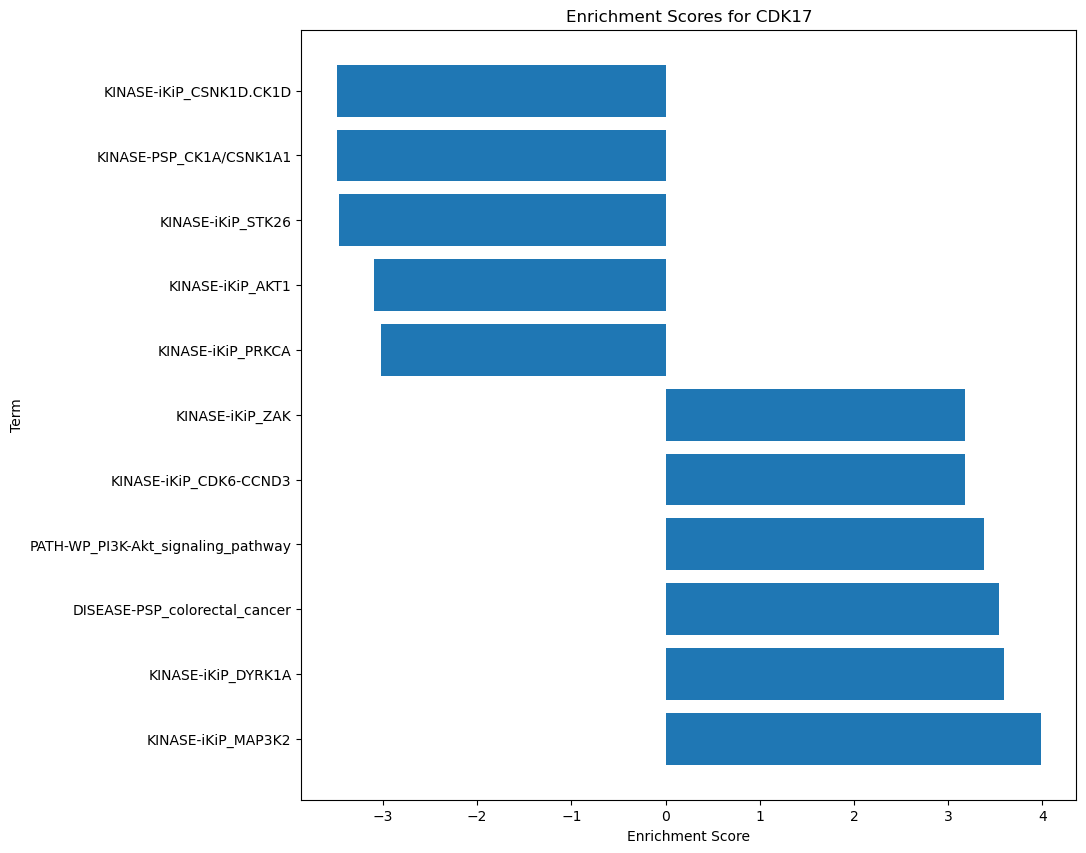

In [39]:
# Create a bar plot of terms and enrichment scores

terms = [
    'KINASE-iKiP_MAP3K2',
    'KINASE-iKiP_DYRK1A',
    'DISEASE-PSP_colorectal_cancer',
    'PATH-WP_PI3K-Akt_signaling_pathway',
    'KINASE-iKiP_CDK6-CCND3',
    'KINASE-iKiP_ZAK',
    'KINASE-iKiP_PRKCA',
    'KINASE-iKiP_AKT1',
    'KINASE-iKiP_STK26',
    'KINASE-PSP_CK1A/CSNK1A1',
    'KINASE-iKiP_CSNK1D.CK1D'
]

scores = [
    3.9854,
3.5932,
3.5403,
3.3782,
3.182,
3.175,
-3.0202,
-3.0958,
-3.4631,
-3.4869,
-3.4919
]

fig, ax = plt.subplots(figsize=(10,10))

# Make a bargraph horizontally to show positive and negative enrichment scores
ax.barh(terms, scores)

# Remove gridlines
plt.grid(False)

plt.xlabel('Enrichment Score')
plt.ylabel('Term')
plt.title('Enrichment Scores for CDK17')
